# Preamble

In [1]:
import xarray as xr
import numpy as np
import os, sys

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

from glob import glob
import re
from collections import defaultdict

from collections import defaultdict
from collections.abc import Callable

from pprint import pprint

from glob import glob
import os

import zarr

from dask.distributed import wait

import nc_time_axis

import logging
from logger import setup_logging

logger = setup_logging(__name__, logging.DEBUG)

In [2]:
import formatting

In [3]:
import warnings

# Mute the Dask large graph warning
warnings.filterwarnings(
    "ignore", 
    message=".*Sending large graph of size.*", 
    category=UserWarning
)


In [4]:
xr.set_options(display_expand_attrs=False, display_expand_data=False)

In [5]:
import dask_gateway
gw = dask_gateway.Gateway("https://dask-gateway.jasmin.ac.uk", auth="jupyterhub")

In [6]:
for i,c in enumerate(gw.list_clusters()):
    print(f'{i}, ', end='')
    gw.stop_cluster(c.name)

0, 

In [7]:
# client.close()

In [8]:
# options = gw.cluster_options()
# options.account = "extant"
# options.worker_cores = 1
# options.worker_threads = 1
# options.worker_memory = 16
# # options.worker_memory = None

# clusters = gw.list_clusters()
# if not clusters:
#     cluster = gw.new_cluster(options, shutdown_on_close=False)
# else:
#     cluster = gw.connect(clusters[0].name)

# cluster.scale(40)
# client = cluster.get_client()
# client.wait_for_workers(8)

In [9]:
options = gw.cluster_options()
options.account = "extant"
options.worker_cores = 1
options.worker_threads = 1
options.worker_memory = 8

cluster = gw.new_cluster(options, shutdown_on_close=True)
cluster.scale(6)
client = cluster.get_client()
client.wait_for_workers(6)

2026-08-06 17:43:54,361 - distributed.client - ERROR - Failed to reconnect to scheduler after 30.00 seconds, closing client


In [10]:
# https://notebooks.jasmin.ac.uk/_jasmin/proxy/dask-gateway/clusters/<cluster.name>/status
cluster.name

'd8732aa4628549caa7b49d4e03bdab66'

In [11]:
client.dashboard_link

'/_jasmin/proxy/dask-gateway/clusters/d8732aa4628549caa7b49d4e03bdab66/status'

In [12]:
options

/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/jupyter_client/session.py:721: UserWarning: Message serialization failed with:
Out of range float values are not JSON compliant: inf
Supporting this message is deprecated in jupyter-client 7, please make sure your message is JSON-compliant
  content = self.pack(content)


In [13]:
client#.close()

Connection method: Cluster object,Cluster type: dask_gateway.GatewayCluster
Dashboard: /_jasmin/proxy/dask-gateway/clusters/d8732aa4628549caa7b49d4e03bdab66/status,


In [14]:
# client.close()

# Opening and Processing Data

## ERA5

### Processing

<table style="margin-left:0;">
<tr><th>Stage</th><th>Input</th><th>Output</th></tr>
<tr><td>Temporal resolution</td><td>Sub-daily</td><td>Daily maximum</td></tr>
<tr><td>Spatial subset</td><td>Global lat–lon</td><td>-90° to -60° (Antarctica)</td></tr>
<tr><td>File format</td><td>NetCDF</td><td>Zarr</td></tr>
<tr><td>Compression</td><td>—</td><td>zstd</td></tr>
<tr><td>Data type</td><td>float64</td><td>float32</td></tr>
</table>

In [ ]:
ERA5_ROOT = "/badc/ecmwf-era5/data/oper/an_sfc"
ZARR_OUT = "/work/scratch-pw4/aborow/era5_tasmax_antarctic.zarr"
YEARS = range(1979, 2025)

In [ ]:
if os.path.exists(ZARR_OUT):
    YEARS = range(int(xr.open_zarr(ZARR_OUT).time.dt.year.max()) + 1, YEARS.stop)

In [ ]:
YEARS

In [ ]:
for year in YEARS:
    paths = sorted(glob(f"{ERA5_ROOT}/{year}/*/*/*.2t.nc"))
    print(f'{year=}, total files {len(paths)}')

    ds = (
        xr.open_mfdataset(
            paths,
            combine="nested",
            concat_dim="time",
            parallel=True,
            data_vars="minimal",
            coords="minimal",
            compat="override",
            preprocess=lambda d: d.sortby('latitude').sel(latitude=slice(-90.0, -60.0)),
        )["t2m"]
        .resample(time="1D")
        .max()
        .rename("tasmax")
        .to_dataset()
    )
    ds["tasmax"] = ds["tasmax"].astype("float32")
    ds["tasmax"].encoding = {}
    ds = ds.load()

    if os.path.exists(ZARR_OUT):
        ds.to_zarr(ZARR_OUT, append_dim="time", align_chunks=True)
    else:
        ds.to_zarr(ZARR_OUT, mode="w", encoding={"tasmax": {"chunks": (365, 121, 120)}})
    print(year, flush=True)

In [ ]:
ds

In [ ]:
TARGET_CHUNKS = {"time": -1, "latitude": 20, "longitude": 40}

In [ ]:
da = xr.open_zarr(ZARR_OUT).tasmax.astype("float32").chunk(TARGET_CHUNKS)

In [ ]:
da

In [ ]:
da.isel(time=[0, 30, -1]).sel(latitude=slice(None, -60)).plot(col='time')

In [ ]:
da#.sel(latitude=slice(-90, -60))

In [ ]:
da = da.rename({'latitude': 'lat', 'longitude': 'lon'})

In [ ]:
da.isel(lat=0, lon=0).plot()

In [ ]:
from zarr.codecs import BloscCodec, BloscShuffle

compressor = BloscCodec(cname="zstd", clevel=5, shuffle=BloscShuffle.bitshuffle)

encoding = {
    "tasmax": {
        "compressors": [compressor],
        "chunks": (da.sizes["time"], 20, 40),
    }
}

In [ ]:
ZARR_OUT_2 = '/work/scratch-pw4/aborow/era5_tasmax_antarctic_v2.zarr'

In [ ]:
da.to_dataset(name="tasmax").to_zarr(
    ZARR_OUT_2,
    encoding=encoding,
    consolidated=True,
    mode="w",
)

In [ ]:
da

### Opening

In [99]:
ZARR_OUT_2 = '/work/scratch-pw4/aborow/era5_tasmax_antarctic_v2.zarr'

In [100]:
era5_da = xr.open_zarr(ZARR_OUT_2).tasmax

In [101]:
era5_da

<xarray.DataArray 'tasmax' (time: 16802, lat: 121, lon: 1440)> Size: 12GB
dask.array<chunksize=(16802, 20, 40), meta=np.ndarray>
Coordinates:
  * lon      (lon) float32 6kB 0.0 0.25 0.5 0.75 1.0 ... 359.0 359.2 359.5 359.8
  * time     (time) datetime64[ns] 134kB 1979-01-01 1979-01-02 ... 2024-12-31
  * lat      (lat) float32 484B -90.0 -89.75 -89.5 -89.25 ... -60.5 -60.25 -60.0
Attributes: (2)

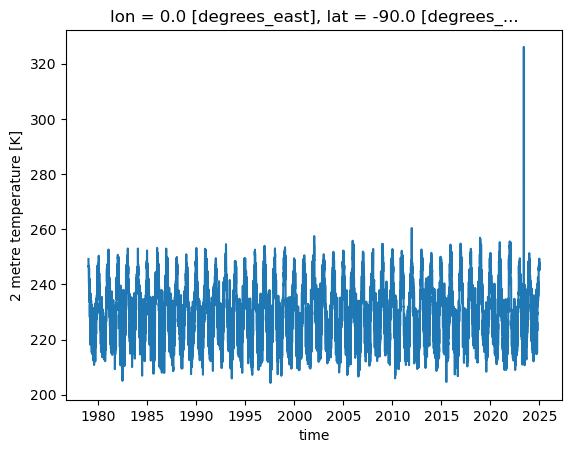

In [102]:
era5_da.isel(lat=0, lon=0).plot()

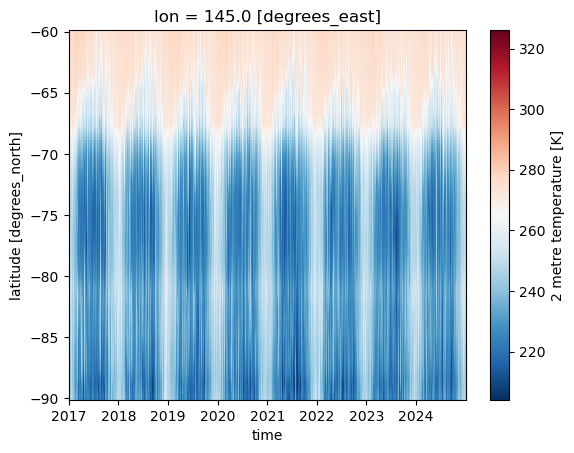

In [103]:
era5_da.sel(lat=slice(-90, -60)).sel(lon=145, method='nearest').sel(time=era5_da.time.dt.year>2016).plot(x='time', cmap='RdBu_r');

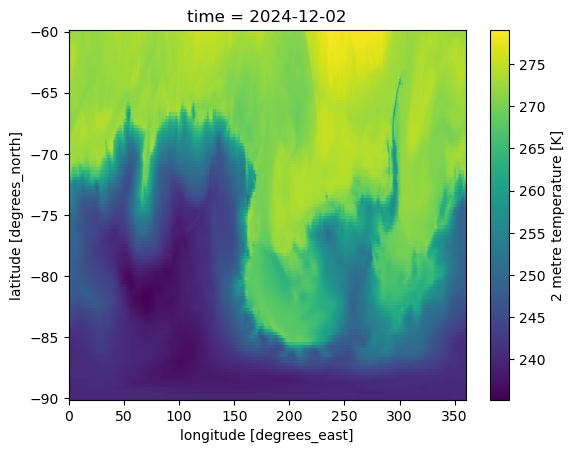

In [104]:
era5_da.isel(time=-30).plot()

## LESFMIP

### Path finding

In [ ]:
os.listdir('/gws/nopw/j04')

In [ ]:
ROOT_DIR = '/gws/ssde/j25a/extant/data'

In [ ]:
potential_models = np.array(os.listdir(ROOT_DIR))
models = np.array([m for m in potential_models if os.path.isdir(os.path.join(ROOT_DIR, m))])
models

In [ ]:
LESMIP_MODELS = ['ACCESS-ESM1-5',
       'CMCC-CM2-SR5', 'CNRM-CM6-1', 'CanESM5',
       'GISS-E2-1-G', 'HadGEM3-GC31-LL', 'IPSL-CM6A-LR',
       'MIROC6', 'MPI-ESM1-2-LR',
       'NorESM2-LM']

In [ ]:
len(LESMIP_MODELS)

In [ ]:
model_list_dict = defaultdict(dict)


for model in LESMIP_MODELS:
    print(model)
    model_path = os.path.join(ROOT_DIR, model, 'day')
    variables = os.listdir(model_path)
    for variable in variables:
        # print(variable)
        variable_path = os.path.join(model_path, variable)
        if os.path.isdir(variable_path): 
            glob_path = os.path.join(variable_path, '**', '*.nc')
            print(f'searching {glob_path}')
            full_paths = glob(glob_path, recursive=True)
            fnames = full_paths#list(map(os.path.basename, full_paths))
            fnames_grouped = defaultdict(list)
            for fname in fnames:
                fnames_grouped[fname.split('_')[3]].append(fname)

            model_list_dict[model][variable] = {'path': variable_path, 'fnames': fnames_grouped}

In [ ]:
model_list_dict

In [ ]:
{model: values.get('tasmax') for model, values in model_list_dict.items()}

In [ ]:
model = 'HadGEM3-GC31-LL'

In [ ]:
sample_dict = model_list_dict[model]['tasmax']

In [ ]:
sample_dict.keys()

In [ ]:
sample_dict['fnames'].keys()

In [ ]:
hist_path = sample_dict['fnames']['historical'][0]
hist_path

In [ ]:
hist_path_split = os.path.basename(hist_path).split('.')[0].split('_')
experiment, ensemble_member, _, time = hist_path_split[-4:]
experiment, ensemble_member, _, time

In [ ]:
hist_match = [f for f in sample_dict['fnames']['historical'] if ((experiment in f) and (ensemble_member in f))]
hist_match

In [ ]:
hist_wild_path = re.sub(r'_gn_\d+-\d+\.nc$', '_gn_*.nc', hist_match[0])
hist_wild_path

In [ ]:
# hist_da = xr.open_mfdataset(hist_wild_path)

In [ ]:
ensmemble_date_str = "_".join(hist_path.split('.')[0].split('_')[-3:])
ensmemble_date_str

In [ ]:
hist_nat_path = sample_dict['fnames']['hist-nat'][0]
hist_nat_path

In [ ]:
hist_nat_wild_path = re.sub(r'_gn_\d+-\d+.nc$', '_gn_*.nc',hist_nat_path)
hist_nat_wild_path

### Processing

In [ ]:
import logging

In [ ]:
logger = logging.getLogger(__name__)

In [ ]:
def _hist_preprocess_single_member(ds: xr.Dataset) -> xr.Dataset:
    """Subset one file to tasmax over the Dome C box and label it by variant.

    Parameters
    ----------
    ds : xr.Dataset
        A single CMIP6 file as opened by ``open_mfdataset``.

    Returns
    -------
    xr.Dataset
        ``tasmax`` only, on a (member, time, lat, lon) grid, encoding stripped.
    """
    ds = (
        ds[["tasmax"]]
        .sel(lat=slice(-82, -78), lon=slice(120, 129))
        .expand_dims(member=[ds.attrs["variant_label"]])
    )
    ds.encoding.clear()
    ds.tasmax.encoding.clear()
    ds.time.encoding.clear()
    return ds

In [ ]:
from IPython.display import display

In [ ]:
def group_by_member(fnames: list[str]) -> dict[str, list[str]]:
    """Group file paths by the rXiYpZfW member id in their filename."""
    by_member = defaultdict(list)
    for p in fnames:
        by_member[re.search(r"_(r\d+i\d+p\d+f\d+)_", p).group(1)].append(p)
    logger.debug("grouped %d files into %d members", len(fnames), len(by_member))
    return by_member


def get_members_already_run(out: str) -> list[str]:
    """Member ids present in the Zarr store `out`; empty list if `out` does not exist."""
    if not os.path.exists(out):
        logger.debug("no store at %s", out)
        return []
    members = list(xr.open_dataset(out, engine='zarr').member.values)
    logger.debug("found %d members in %s", len(members), out)
    return members


def make_batches(
    by_member: dict[str, list[str]],
    members_already_run: list[str],
    batch_size:int=5
) -> list[list[list[str]]]:
    """File lists for the members of `by_member` not in `members_already_run`, in batches of 5."""
    nested = [sorted(f) for m, f in by_member.items() if m not in members_already_run]
    batches = [nested[i:i + batch_size] for i in range(0, len(nested), batch_size)]
    logger.debug("%d members pending -> %d batches", len(nested), len(batches))
    print(list(map(len, nested)))
    return batches

def group_by_member(fnames: list[str]) -> dict[str, list[str]]:
    """Group file paths by the rXiYpZfW member id in their filename."""
    by_member = defaultdict(list)
    for p in fnames:
        by_member[re.search(r"_(r\d+i\d+p\d+f\d+)_", p).group(1)].append(p)
    logger.debug("grouped %d files into %d members", len(fnames), len(by_member))
    return by_member


def get_members_already_run(out: str) -> list[str]:
    """Member ids present in the Zarr store `out`; empty list if `out` does not exist."""
    if not os.path.exists(out):
        logger.debug("no store at %s", out)
        return []
    members = list(xr.open_dataset(out, engine='zarr').member.values)
    logger.debug("found %d members in %s", len(members), out)
    return members


def make_batches(
    by_member: dict[str, list[str]],
    members_already_run: list[str],
    batch_size:int=5
) -> list[list[list[str]]]:
    """File lists for the members of `by_member` not in `members_already_run`, in batches of 5."""
    nested = [sorted(f) for m, f in by_member.items() if m not in members_already_run]
    batches = [nested[i:i + batch_size] for i in range(0, len(nested), batch_size)]
    logger.debug("%d members pending -> %d batches", len(nested), len(batches))
    print(list(map(len, nested)))
    return batches


def write_group(
    group: list[list[str]],
    out: str,
    preprocess: Callable[[xr.Dataset], xr.Dataset],
    append: bool,
) -> list[str]:
    """Open the file lists in `group` along (member, time) and write them to `out`."""
    ds = xr.open_mfdataset(
        group,
        preprocess=preprocess,
        combine='nested',
        concat_dim=['member', 'time'],
        parallel=True,
        data_vars='minimal',
        coords='minimal',
        compat='override',
        join='override',
        chunks={'time': -1}
    )
    if logger.isEnabledFor(logging.DEBUG): display(ds)
    ds = ds.load()
    ds = ds.chunk({"member": 1, "time": -1, "lat": -1, "lon": -1})
    if append:
        ds.to_zarr(out, append_dim="member")
    else:
        logger.info("creating store %s", out)
        ds.to_zarr(out, mode="w")
    members = list(ds.member.values)
    ds.close()
    return members


def write_batches(
    batches: list[list[list[str]]],
    out: str,
    preprocess: Callable[[xr.Dataset], xr.Dataset],
) -> None:
    """Write each batch to `out`; on failure retry its members one at a time, skipping any that fail."""
    append = os.path.exists(out)
    for i, batch in enumerate(batches):
        logger.info("batch %d/%d: opening %d members", i + 1, len(batches), len(batch))
        logger.debug(batch)
        try:
            members = write_group(batch, out, preprocess, append)
            append = True
            logger.info("wrote batch %d/%d: %s", i + 1, len(batches), members)
        except Exception:
            logger.exception("batch %d/%d failed, retrying members individually", i + 1, len(batches))
            for files in batch:
                try:
                    members = write_group([files], out, preprocess, append)
                    append = True
                    logger.info("wrote member %s", members)
                except Exception:
                    logger.exception("skipping member, files: %s", files)

In [ ]:
out = "/work/scratch-pw4/aborow/tasmax_hist_HadGEM3-GC31-LL_subset.zarr"

In [ ]:
mf_wildcard_hist_path = '/gws/ssde/j25a/extant/data/HadGEM3-GC31-LL/day/tasmax/historical/tasmax_day_HadGEM3-GC31-LL_historical*.nc'

In [ ]:
logger.setLevel(logging.DEBUG)

In [ ]:
save_model_by_member_batches(mf_wildcard_hist_path, out, _hist_preprocess_single_member, batch_size=5)

In [ ]:
out_histnat = "/work/scratch-pw4/aborow/tasmax_histnat_HadGEM3-GC31-LL_subset.zarr"

In [ ]:
out_histnat

In [ ]:
mf_wildcard_hisnat_path = '/gws/ssde/j25a/extant/data/HadGEM3-GC31-LL/day/tasmax/hist-nat/tasmax_day_HadGEM3-GC31-LL_hist-nat_*.nc'

In [ ]:
save_model_by_member_batches(mf_wildcard_hisnat_path, out_histnat, _hist_preprocess_single_member, batch_size=1)

### Opening

In [15]:
out_histnat = "/work/scratch-pw4/aborow/tasmax_histnat_HadGEM3-GC31-LL_subset.zarr"

In [16]:
out = "/work/scratch-pw4/aborow/tasmax_hist_HadGEM3-GC31-LL_subset.zarr"

In [17]:
histnat_ensemble_ds = xr.open_dataset(
    out_histnat, engine='zarr', chunks={'time':-1, 'member':11, 'lat':-1, 'lon':-1}
                                     ).tasmax

/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)


In [18]:
hist_ensemble_ds = xr.open_dataset(
    out, engine='zarr', chunks={'time':-1, 'member':11, 'lat':-1, 'lon':-1}).tasmax

/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)


In [19]:
histnat_ensemble_ds

<xarray.DataArray 'tasmax' (member: 49, time: 123120, lat: 4, lon: 5)> Size: 483MB
dask.array<chunksize=(11, 123120, 4, 5), meta=np.ndarray>
Coordinates:
  * member   (member) object 392B 'r10i1p1f3' 'r11i1p1f3' ... 'r54i1p1f3'
    height   float64 8B ...
  * lon      (lon) float64 40B 120.9 122.8 124.7 126.6 128.4
  * time     (time) object 985kB 1850-01-01 12:00:00 ... 2020-12-30 12:00:00
  * lat      (lat) float64 32B -81.88 -80.62 -79.38 -78.12
Attributes: (8)

In [20]:
hist_ensemble_ds

<xarray.DataArray 'tasmax' (member: 55, time: 59400, lat: 4, lon: 5)> Size: 261MB
dask.array<chunksize=(11, 59400, 4, 5), meta=np.ndarray>
Coordinates:
  * time     (time) object 475kB 1850-01-01 12:00:00 ... 2014-12-30 12:00:00
  * member   (member) object 440B 'r16i1p1f3' 'r17i1p1f3' ... 'r60i1p1f3'
  * lat      (lat) float64 32B -81.88 -80.62 -79.38 -78.12
  * lon      (lon) float64 40B 120.9 122.8 124.7 126.6 128.4
    height   float64 8B ...
Attributes: (8)

### Landsea Mask

In [ ]:
LANDSEA_DIR = '/badc/cmip6/data/CMIP6/CMIP/MOHC/HadGEM3-GC31-LL/piControl/r1i1p1f1/fx/sftlf/gn/latest/'

In [ ]:
os.listdir(LANDSEA_DIR)

In [ ]:
landsea_mask_ds = xr.open_dataset(os.path.join(LANDSEA_DIR, 'sftlf_fx_HadGEM3-GC31-LL_piControl_r1i1p1f1_gn.nc')).sftlf
landsea_mask_ds

In [ ]:
hist_nat_ds = hist_nat_ds.where(landsea_mask_ds)#.isel(time=-1).plot()
hist_ds = hist_ds.where(landsea_mask_ds)

# Wrangling Data

## LESFMIP

In [21]:
hist_ensemble_ds = hist_ensemble_ds - 273.15
histnat_ensemble_ds = histnat_ensemble_ds - 273.15

In [22]:
#| title: Calendar converson
#| caption: Some kind of callendar issues seems to affect the data after zara conversion
histnat_ensemble_ds = histnat_ensemble_ds.convert_calendar('360_day', align_on='year')

In [23]:
#| title: Duplicate time
#| caption: Remove the dubpliated time steps
histnat_ensemble_ds = histnat_ensemble_ds.drop_duplicates('time')

In [24]:
#| title: Removing incomplete seasons
#| captiion: Slicing the incomplete seasons. Starting from 3rd month as the summer before this is missing December, and finising at 11 or the last summer
#| is just December
histnat_ensemble_ds = histnat_ensemble_ds.sel(time=slice('1850-03', '2014-11'))
hist_ensemble_ds = hist_ensemble_ds.sel(time=slice('1850-03', '2014-11'))

## ERA5

In [105]:
era5_da = era5_da.convert_calendar("360_day", align_on="year")

In [106]:
era5_da = era5_da - 273.15

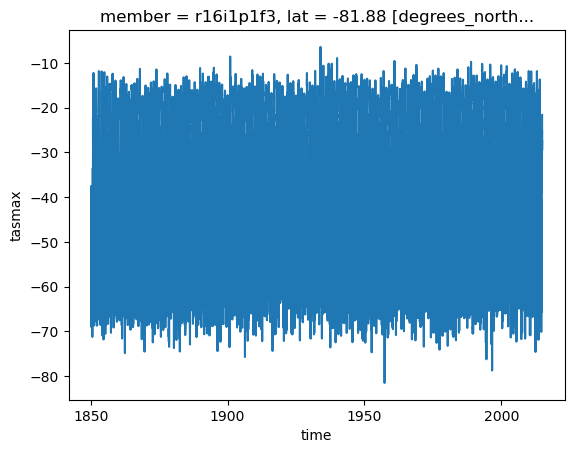

In [107]:
hist_ensemble_ds.isel(lat=0, lon=0, member=0).plot()

# Stability of Percentile

In [32]:
hn_ds = histnat_ensemble_ds.isel(lat=0, lon=0) - 273.15

In [33]:
hn_ds

<xarray.DataArray 'tasmax' (member: 49, time: 59310)> Size: 12MB
dask.array<chunksize=(11, 59310), meta=np.ndarray>
Coordinates:
  * member   (member) object 392B 'r10i1p1f3' 'r11i1p1f3' ... 'r54i1p1f3'
    height   float64 8B ...
    lon      float64 8B 120.9
  * time     (time) object 474kB 1850-03-01 12:00:00 ... 2014-11-30 12:00:00
    lat      float64 8B -81.88

In [34]:
quantiles = hn_ds.quantile(np.arange(0.5, 1.00, 0.001), dim='time').compute()

In [35]:
out = quantiles.max(dim='member') - quantiles.min(dim='member')

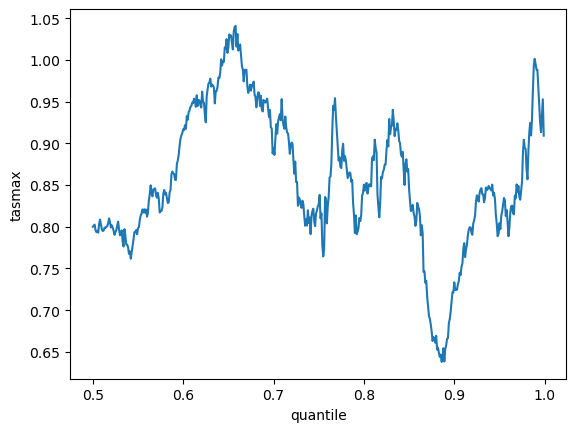

In [36]:
out.plot()

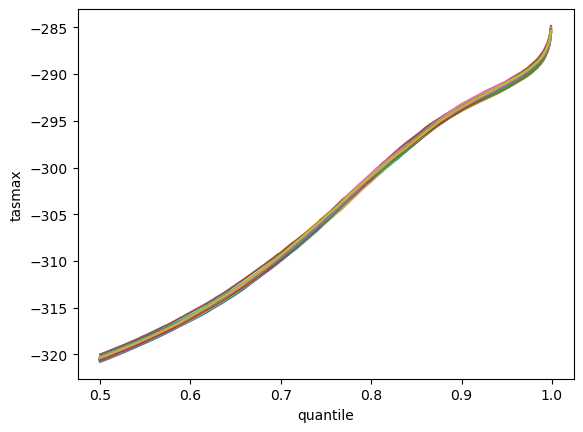

In [37]:
quantiles.plot(x='quantile', hue='member', add_legend=False);

In [38]:
import pandas as pd

In [39]:
members = hn_ds.member.values

In [40]:
rng = np.random.default_rng()

In [ ]:
q_out = defaultdict(list)
quantiles = np.arange(0.5, 1, 0.0001)
for i in range(100): # should be 1000, but leaving as 100 incase accidently run
    rand_imember = np.sort(rng.choice(len(members), size=20, replace=False))
    hn_ds_subset = hn_ds.isel(member=rand_imember)
    qval = hn_ds_subset.quantile(quantiles)
    for q in quantiles:
        q_out[round(q, 4)].append(qval.sel(quantile=q).values.item())

In [ ]:
q_out = pd.DataFrame(q_out).T.iloc[:, :-1]

In [ ]:
q_out.head()

In [ ]:
q_out_std = q_out.std(axis=1)

In [ ]:
q_out_std.plot()

# ERA5 vs Model

In [108]:
latlon = dict(lat=-81.88, lon=120.9, method='nearest')

In [109]:
era5_loc = era5_da.sel(**latlon)

In [110]:
np.take(era5_loc.time.dt.year.values, [0, -1])

array([1979, 2024])

In [111]:
np.take(hist_ensemble_ds.time.dt.year.values, [0, -1])

array([1850, 2014])

In [112]:
start = 1979; end = 2014

In [113]:
hist_era5_ds = hist_ensemble_ds.sel(time=hist_ensemble_ds['time.year'] >= start)
era5_loc = era5_loc.sel(time=era5_loc['time.year'] <= end).compute()

In [114]:
era5_loc

<xarray.DataArray 'tasmax' (time: 12960)> Size: 52kB
-21.26 -23.16 -23.67 -24.97 -25.72 -24.41 ... -27.05 -24.97 -27.48 -28.19 -28.39
Coordinates:
    lon      float32 4B 121.0
    lat      float32 4B -82.0
  * time     (time) object 104kB 1979-01-01 00:00:00 ... 2014-12-30 00:00:00

In [115]:
hist_era5_ds

<xarray.DataArray 'tasmax' (member: 55, time: 12930, lat: 4, lon: 5)> Size: 57MB
dask.array<chunksize=(11, 12930, 4, 5), meta=np.ndarray>
Coordinates:
  * time     (time) object 103kB 1979-01-01 12:00:00 ... 2014-11-30 12:00:00
  * member   (member) object 440B 'r16i1p1f3' 'r17i1p1f3' ... 'r60i1p1f3'
  * lat      (lat) float64 32B -81.88 -80.62 -79.38 -78.12
  * lon      (lon) float64 40B 120.9 122.8 124.7 126.6 128.4
    height   float64 8B ...

## Quantiles and distributions

In [116]:
import numpy as np
from scipy.stats import gaussian_kde


def kde_axis(vmin: float, vmax: float, n: int) -> np.ndarray:
    """Evaluation points for a KDE.

    vmin, vmax : float
        Bounds of the axis, in data units.
    n : int
        Number of points.

    Returns
    -------
    np.ndarray, shape (n,)
    """
    return np.linspace(vmin, vmax, n)


def kde(samples: np.ndarray, x: np.ndarray, bw_method=None) -> np.ndarray:
    """Gaussian KDE of `samples` evaluated at `x`.

    samples : np.ndarray, shape (m,)
        1-D sample array.
    x : np.ndarray, shape (n,)
        Evaluation points, e.g. from `kde_axis`.
    bw_method : str | float | callable | None
        Passed straight to scipy.stats.gaussian_kde.

    Returns
    -------
    np.ndarray, shape (n,)
        Density at each point of `x`.
    """
    return gaussian_kde(samples, bw_method=bw_method)(x)

In [117]:
from xarray_calc import dayofyear_quantile, dayofyear_climatology

In [118]:
quantiles = np.arange(0.01, 1, 0.01)
hist_ensemble_quantiles = hist_era5_ds.quantile(quantiles, dim=['time', 'member'])
hist_quantiles = hist_era5_ds.quantile(quantiles, dim=['time'])
era5_loc_quantiles = era5_loc.quantile(quantiles, dim=['time'])

Text(0.5, 1.0, 'Quantile threshold')

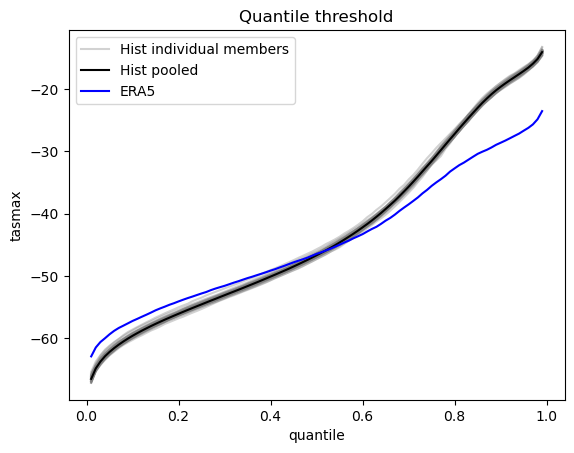

In [119]:
fig, ax = plt.subplots()
lines = hist_quantiles.isel(lat=0, lon=0).plot(ax=ax, x='quantile', hue='member',
                                               color='grey', alpha=0.35, add_legend=False)
hist_ensemble_quantiles.isel(lat=0, lon=0).plot(label='Hist pooled', ax=ax, color='k')

lines[0].set_label('Hist individual members')
era5_loc_quantiles.plot(ax=ax, color="blue", label='ERA5')
ax.legend()
ax.set_title('Quantile threshold')

In [120]:
hist_era5_ds.min().values, hist_era5_ds.max().values

(array(-81.70932, dtype=float32), array(-3.1180115, dtype=float32))

In [121]:
hist_era5_ds = hist_era5_ds.chunk({'member':1})

### Day-of-year climatology

In [122]:
window_size:int = 21 #Number of years

In [123]:
#| title: Day of year climatology for ERA5
era5_doy_climatology = dayofyear_climatology(era5_loc, window_size)

In [124]:
%%time
#| title: Day of year climatology for hist
hist_doy_climatology = dayofyear_climatology(hist_era5_ds, window_size).persist()
wait(hist_doy_climatology);

CPU times: user 675 ms, sys: 13.2 ms, total: 688 ms
Wall time: 4.95 s


In [125]:
hist_doy_climatology

<xarray.DataArray 'tasmax' (member: 55, dayofyear: 360, lat: 4, lon: 5)> Size: 2MB
dask.array<chunksize=(1, 359, 1, 1), meta=np.ndarray>
Coordinates:
  * member     (member) object 440B 'r16i1p1f3' 'r17i1p1f3' ... 'r60i1p1f3'
  * lat        (lat) float64 32B -81.88 -80.62 -79.38 -78.12
  * lon        (lon) float64 40B 120.9 122.8 124.7 126.6 128.4
    height     float64 8B ...
  * dayofyear  (dayofyear) int64 3kB 1 2 3 4 5 6 7 ... 355 356 357 358 359 360

In [126]:
#| title: Hist day of year anomaly calculation
# 1. Group the target array by day of year and subtract the climatology
hist_ensemble_anom_doy = hist_era5_ds.groupby("time.dayofyear") - hist_doy_climatology

# 2. (Optional) Remove the residual 'dayofyear' coordinate to keep it clean
hist_ensemble_anom_doy = hist_ensemble_anom_doy.drop_vars("dayofyear").compute()
wait(hist_ensemble_anom_doy);

In [127]:
#| title: ERA5 day of year anomaly calculation
# 1. Group the target array by day of year and subtract the climatology
era5_doy_anom = era5_loc.groupby("time.dayofyear") - era5_doy_climatology

# 2. (Optional) Remove the residual 'dayofyear' coordinate to keep it clean
era5_doy_anom = era5_doy_anom.drop_vars("dayofyear").compute()

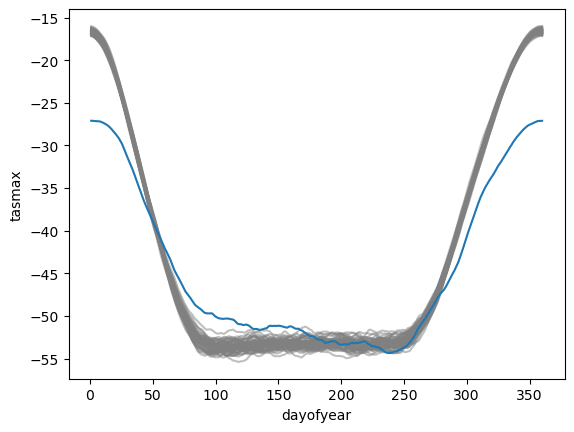

In [128]:
hist_doy_climatology.isel(lat=0, lon=0).plot(
    x="dayofyear", hue='member', add_legend=False, color="grey", alpha=0.5);
era5_doy_climatology.plot()

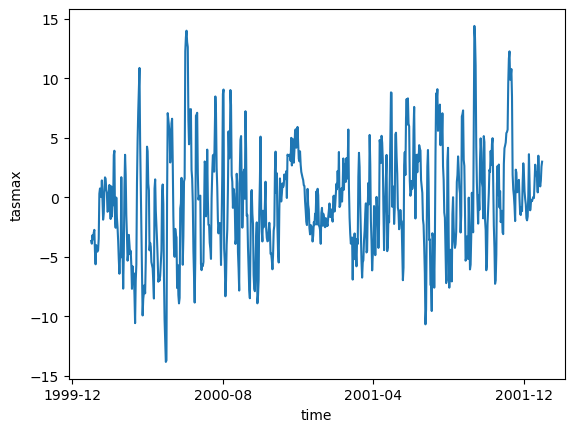

In [129]:
era5_doy_anom.sel(time=slice('2000', '2001')).plot()

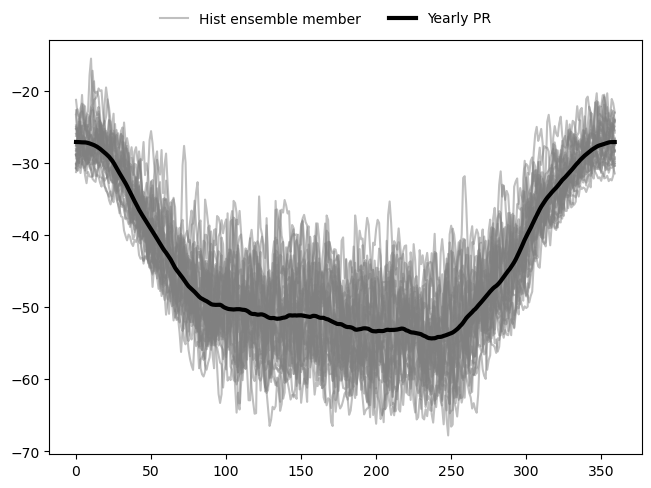

In [130]:
fig, ax = plt.subplots(layout="constrained")

years = np.unique(era5_loc.time.dt.year.values)[:30]
for i, year in enumerate(years):
    ax.plot(era5_loc.sel(time=str(year)), alpha=0.5, color="grey",
            label="Hist ensemble member" if i == 0 else "_nolegend_")

ax.plot(era5_doy_climatology.values, color="k", linewidth=3, label="Yearly PR")

fig.legend(loc="outside upper center", ncols=3, frameon=False)

### Seasonal climatology

In [131]:
#| title: ERA5 seasonal climatology
era5_loc_climatology = era5_loc.groupby('time.season').mean()
era_5_seasonal_anom = era5_loc.groupby('time.season') - era5_loc_climatology

In [132]:
hist_era5_ds

<xarray.DataArray 'tasmax' (member: 55, time: 12930, lat: 4, lon: 5)> Size: 57MB
dask.array<chunksize=(1, 12930, 4, 5), meta=np.ndarray>
Coordinates:
  * time     (time) object 103kB 1979-01-01 12:00:00 ... 2014-11-30 12:00:00
  * member   (member) object 440B 'r16i1p1f3' 'r17i1p1f3' ... 'r60i1p1f3'
  * lat      (lat) float64 32B -81.88 -80.62 -79.38 -78.12
  * lon      (lon) float64 40B 120.9 122.8 124.7 126.6 128.4
    height   float64 8B ...

In [133]:
# #| title: HIst  seasonal climatology
# hist_era5_ds_climatology = hist_era5_ds.groupby('time.season').mean()
# hist_era5_ds_anomaly = hist_era5_ds.groupby('time.season') - hist_era5_ds_climatology
# hist_era5_ds_anomaly = hist_era5_ds_anomaly.compute()

In [134]:
hist_era5_ds_season = hist_era5_ds['time'].dt.season
hist_era5_ds_climatology = hist_era5_ds.groupby(hist_era5_ds_season).mean().compute()
hist_era5_ds_anomaly = hist_era5_ds - hist_era5_ds_climatology.sel(season=hist_era5_ds_season)

In [135]:
hist_era5_ds_climatology

<xarray.DataArray 'tasmax' (member: 55, season: 4, lat: 4, lon: 5)> Size: 18kB
-24.84 -24.55 -24.28 -24.0 -23.71 -24.94 ... -42.18 -41.9 -41.58 -41.22 -40.81
Coordinates:
  * member   (member) object 440B 'r16i1p1f3' 'r17i1p1f3' ... 'r60i1p1f3'
  * lat      (lat) float64 32B -81.88 -80.62 -79.38 -78.12
  * lon      (lon) float64 40B 120.9 122.8 124.7 126.6 128.4
    height   float64 8B 1.5
  * season   (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'

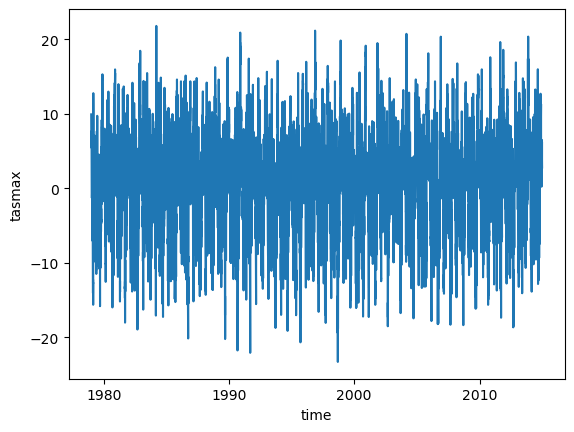

In [136]:
era_5_seasonal_anom.plot()

In [137]:
hist_era5_ds_climatology

<xarray.DataArray 'tasmax' (member: 55, season: 4, lat: 4, lon: 5)> Size: 18kB
-24.84 -24.55 -24.28 -24.0 -23.71 -24.94 ... -42.18 -41.9 -41.58 -41.22 -40.81
Coordinates:
  * member   (member) object 440B 'r16i1p1f3' 'r17i1p1f3' ... 'r60i1p1f3'
  * lat      (lat) float64 32B -81.88 -80.62 -79.38 -78.12
  * lon      (lon) float64 40B 120.9 122.8 124.7 126.6 128.4
    height   float64 8B 1.5
  * season   (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'

### Kernal density estimates (KDE)

<b> Daily anomalies

In [138]:
x_anom = np.linspace(-50, 50, 200)

In [139]:
dens_anom_doy = xr.apply_ufunc(
    lambda s: gaussian_kde(s)(x_anom),
    hist_ensemble_anom_doy,
    input_core_dims=[["time"]],
    output_core_dims=[["x"]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[float],
    dask_gufunc_kwargs={"output_sizes": {"x": x_anom.size}},
).assign_coords(x=x_anom)

In [140]:
era5_anom_doy_kde = gaussian_kde(era5_doy_anom.values)(x_anom)
era5_anom_doy_kde = xr.DataArray(era5_anom_doy_kde, dims=["x"], coords={"x":x_anom})

Text(0.5, 1.0, 'Daily tasmax anomalies with daily climatology (81.88°S, 120.9°E)')

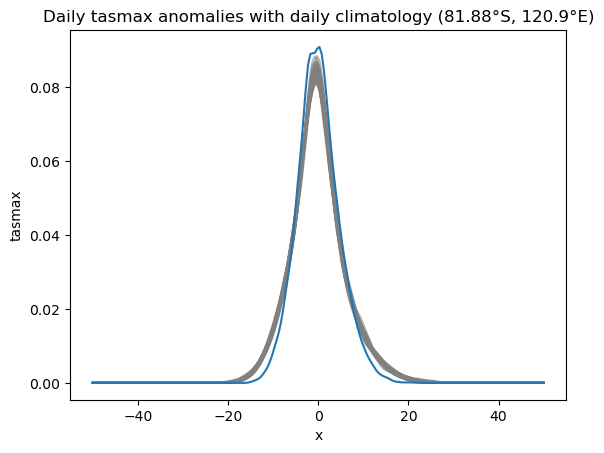

In [141]:
fig, ax = plt.subplots(1,1)
dens_anom_doy.isel(lat=0, lon=0).plot(ax=ax, hue='member', x='x', add_legend=False, color='grey', alpha=0.6);
ax.plot(x_anom, era5_anom_doy_kde.values)
ax.set_title(f'Daily tasmax anomalies with daily climatology ({formatting.format_latlon(latlon)})')

<b> Seasonal anomalies

In [142]:
dens_anom = xr.apply_ufunc(
    lambda s: gaussian_kde(s)(x_anom),
    hist_era5_ds_anomaly.chunk(dict(time=-1)),
    input_core_dims=[["time"]],
    output_core_dims=[["x"]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[float],
    dask_gufunc_kwargs={"output_sizes": {"x": x_anom.size}},
).assign_coords(x=x_anom).compute()

In [143]:
era5_anom_kde = gaussian_kde(era_5_seasonal_anom.values)(x_anom)
era5_anom_kde = xr.DataArray(era5_anom_kde, dims=["x"], coords={"x":x_anom})

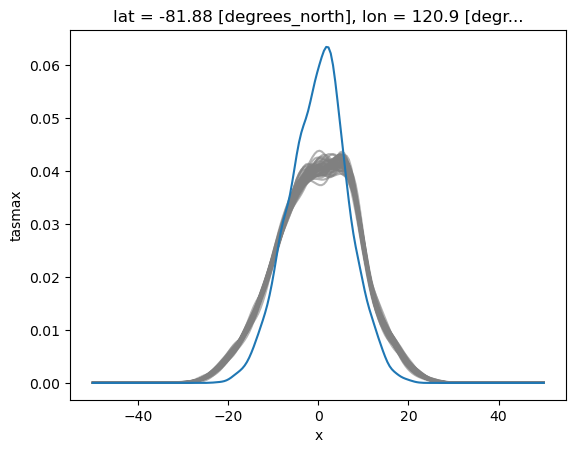

In [144]:
#| title: Distribution of daily summera anomalies
fig, ax = plt.subplots(1,1)
dens_anom.isel(lat=0, lon=0).plot(ax=ax, hue='member', x='x', add_legend=False, color='grey', alpha=0.6);
ax.plot(x_anom, era5_anom_kde.values)

<b> Description
- Austral summer anomalies
- Climatology is from all data

<b> Interpretation
- Too much wieght in both tails for all ensemble members (too many hot and cold extremes)

In [145]:
x_degc = np.linspace(191, 271, 200) - 273.15

In [146]:
dens = xr.apply_ufunc(
    lambda s: gaussian_kde(s)(x_degc),
    hist_era5_ds,
    input_core_dims=[["time"]],
    output_core_dims=[["x"]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[float],
    dask_gufunc_kwargs={"output_sizes": {"x": x_degc.size}},
).assign_coords(x=x_degc).compute()

In [147]:
era5_kde = gaussian_kde(era5_loc.values)(x_degc)
era5_kde = xr.DataArray(era5_kde, dims=["x"], coords={"x":x_degc})

Text(0.5, 1.0, 'KDE for ERA and Ensembles for daily tasmax (81.88°S, 120.9°E)')

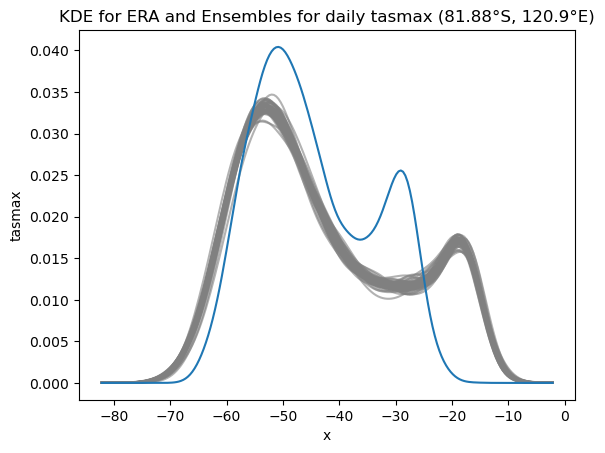

In [148]:
fig, ax = plt.subplots(1,1)
dens.isel(lat=0, lon=0).plot(ax=ax, hue='member', x='x', add_legend=False, color='grey', alpha=0.6);
ax.plot(x_degc, era5_kde)
ax.set_title(f'KDE for ERA and Ensembles for daily tasmax ({formatting.format_latlon(latlon)})')

<b> Description
- All daily data for the period that matches ERA5
<b> Intereprtation
- The distribution is bi-model for both models
- There are a lot more values above -20degC for the model than ERA5
- The model also has a lot more value below -75degC
- Summertime peak is in the wrong place

In [149]:
dens = dens.compute()
dens_anom = dens_anom.compute()
dens_anom_doy = dens_anom_doy.compute()

### Quantile
Quantiles of the day-of-year anomalies, seasonal anomalies and raw values

In [150]:
quantiles = np.arange(0.01, 1, 0.01)

In [151]:
hist_doy_quantile = hist_ensemble_anom_doy.quantile(quantiles, dim="time")
hist_season_quantile = hist_era5_ds_anomaly.quantile(quantiles, dim="time")
hist_quantile = hist_era5_ds.quantile(quantiles, dim="time")

In [152]:
era5_doy_quantile = era5_doy_anom.quantile(quantiles, dim="time")
era5_season_quantile = era5_doy_anom.quantile(quantiles, dim="time")
era5_quantile = era5_loc.quantile(quantiles, dim="time")

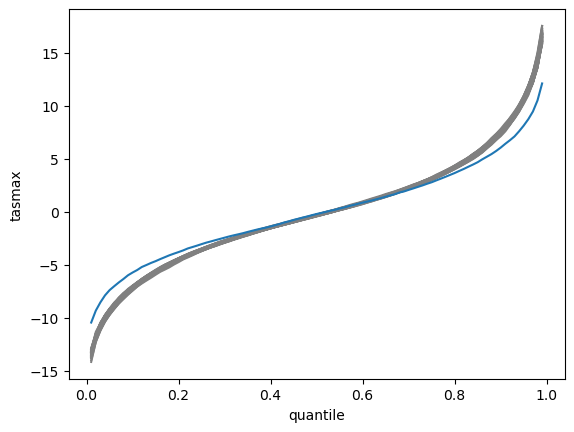

In [153]:
hist_doy_quantile.isel(lat=0, lon=0).plot(x="quantile", hue="member", add_legend=False, color="grey");
era5_doy_quantile.plot()

### Plots

In [154]:
def plot_kde_panel(ax, dens, era5_kde, x):
    """Plot ensemble member KDEs and the ERA5 KDE on one axis.

    Args:
        ax (matplotlib.axes.Axes): Axis to draw on.
        dens (xr.DataArray): Ensemble densities with dims (member, x).
        era5_kde (np.ndarray): ERA5 density evaluated at x.
        x (np.ndarray): Evaluation grid.

    Returns:
        tuple[Line2D, Line2D]: Handles for one member line and the ERA5 line.
    """
    members = dens.plot(ax=ax, hue="member", x="x", add_legend=False, color="grey", alpha=0.6)
    (era5,) = ax.plot(x, era5_kde, color="blue", lw=2)
    return members[0], era5

In [155]:

def plot_quantile_panel(ax, hist_q, era5_q, era5_color="C0"):
    hist_q.plot(ax=ax, x="quantile", hue="member", add_legend=False, color="grey")
    era5_q.plot(ax=ax, color=era5_color)
    ax.set_title("")
    ax.set_xlabel("Quantile")

Text(0.5, 0.98, 'Distributions and quantiles for ERA5 and historical ensemble members, tasmax (81.88°S, 120.9°E)')

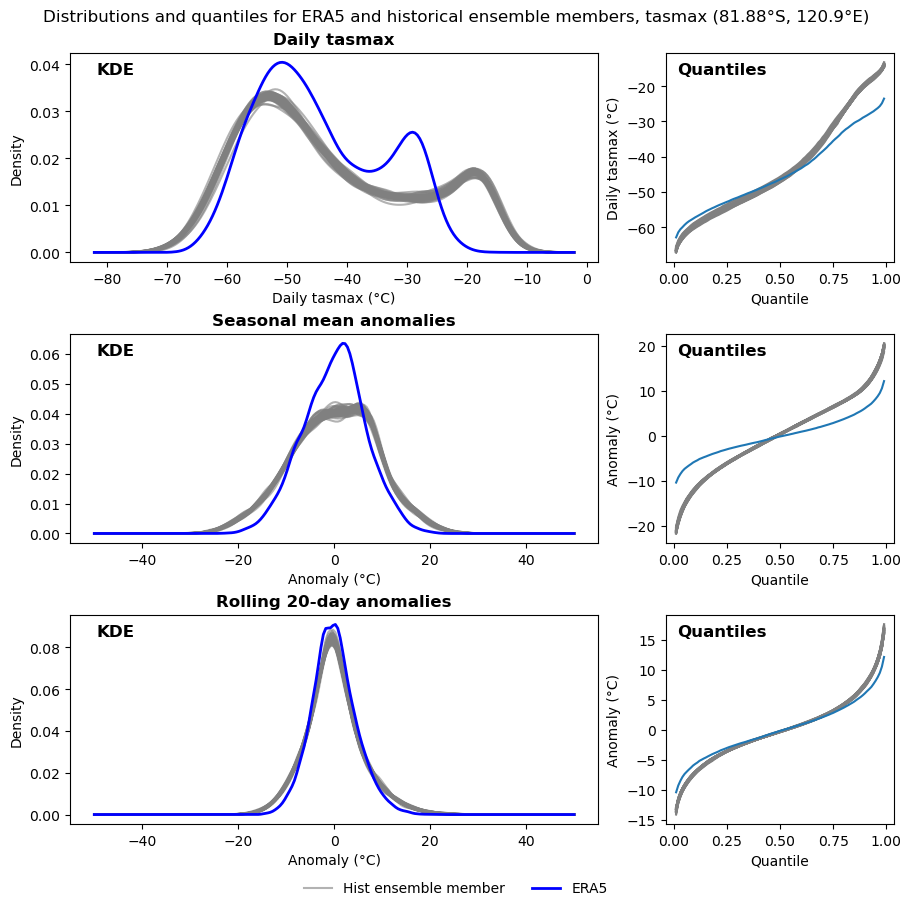

In [156]:


panels = {
    "Daily tasmax": {
        "unit": "Daily tasmax (°C)",
        "dens": dens,
        "era5_kde": era5_kde,
        "x": x_degc,
        "hist_quantile": hist_quantile,
        "era5_quantile": era5_quantile,
    },
    "Seasonal mean anomalies": {
        "unit": "Anomaly (°C)",
        "dens": dens_anom,
        "era5_kde": era5_anom_kde,
        "x": x_anom,
        "hist_quantile": hist_season_quantile,
        "era5_quantile": era5_season_quantile,
    },
    "Rolling 20-day anomalies": {
        "unit": "Anomaly (°C)",
        "dens": dens_anom_doy,
        "era5_kde": era5_anom_doy_kde,
        "x": x_anom,
        "hist_quantile": hist_doy_quantile,
        "era5_quantile": era5_doy_quantile,
    },
}

fig = plt.figure(figsize=(9, 9), layout="constrained")
gs = fig.add_gridspec(3, 2, width_ratios=[3, 1.3])

for i, (title, panel) in enumerate(panels.items()):
    ax_kde = fig.add_subplot(gs[i, 0])
    ax_q = fig.add_subplot(gs[i, 1])

    handles = plot_kde_panel(ax_kde, panel["dens"].isel(lat=0, lon=0), panel["era5_kde"], panel["x"])
    ax_kde.set_xlabel(panel["unit"])
    ax_kde.set_ylabel("Density")

    plot_quantile_panel(ax_q, panel["hist_quantile"].isel(lat=0, lon=0), panel["era5_quantile"])
    ax_kde.set_title(title, fontweight="bold")

    ax_q.set_ylabel(panel["unit"])
    loc_kwargs = dict(xy=(0.05, 0.9), fontsize=12, fontweight="bold", xycoords="axes fraction")
    ax_kde.annotate("KDE", **loc_kwargs)
    ax_q.annotate("Quantiles", **loc_kwargs)

    
    # if i == 0:
        # ax_q.set_title("Quantiles", loc="left")

fig.legend(handles, ["Hist ensemble member", "ERA5"], loc="outside lower center", ncols=2, frameon=False)
fig.suptitle(f"Distributions and quantiles for ERA5 and historical ensemble members, tasmax ({formatting.format_latlon(latlon)})")

Text(0.5, 0.98, 'KDE for ERA5 and ensemble members, daily tasmax (81.88°S, 120.9°E)')

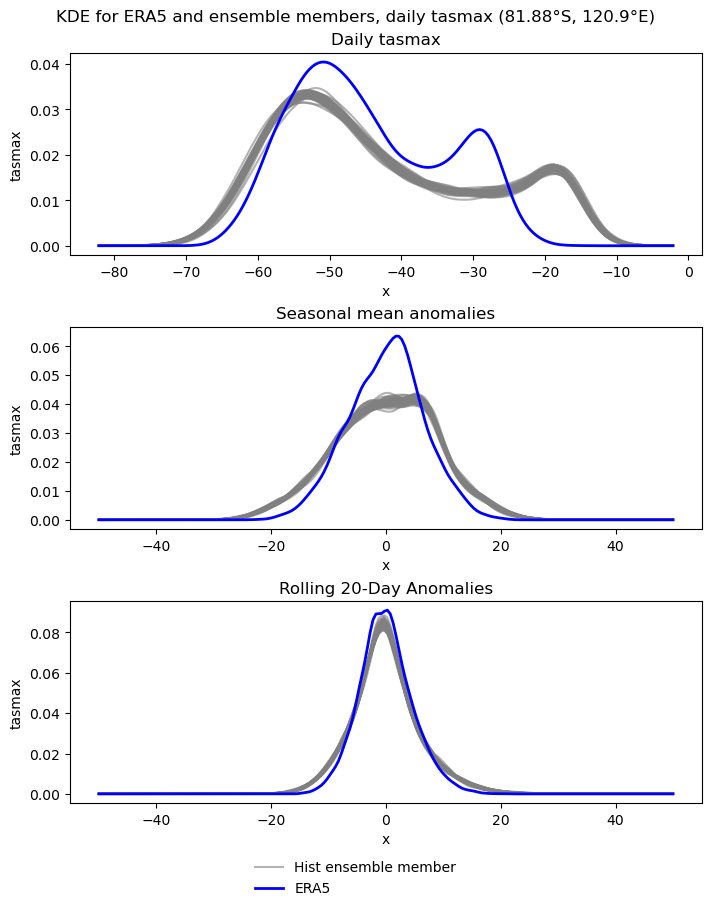

In [157]:
fig, axes = plt.subplots(3, 1, figsize=(7, 9), layout="constrained")

handles = plot_kde_panel(axes[0], dens.isel(lat=0, lon=0), era5_kde, x_degc)
axes[0].set_title("Daily tasmax")

plot_kde_panel(axes[1], dens_anom.isel(lat=0, lon=0), era5_anom_kde, x_anom)
axes[1].set_title("Seasonal mean anomalies")

plot_kde_panel(axes[2], dens_anom_doy.isel(lat=0, lon=0), era5_anom_doy_kde, x_anom)
axes[2].set_title("Rolling 20-Day Anomalies")

fig.legend(handles, ["Hist ensemble member", "ERA5"], loc="outside lower center", frameon=False)
fig.suptitle(f"KDE for ERA5 and ensemble members, daily tasmax ({formatting.format_latlon(latlon)})")

<b> Intepretation
- Daily tasmax has too much weight in the extremes. This is due to sumer anomalies being too large
- Seasonal anomalies doesn't fix this
- Using 21-day rolling anomalies means the disitributions are similar. However, still too much weight in anomalies between -8 and 20.

In [158]:
era5_anom_doy_kde

<xarray.DataArray (x: 200)> Size: 2kB
0.0 0.0 0.0 0.0 0.0 0.0 0.0 ... 2.451e-297 7.676e-309 1.441e-320 0.0 0.0 0.0 0.0
Coordinates:
  * x        (x) float64 2kB -50.0 -49.5 -48.99 -48.49 ... 48.49 48.99 49.5 50.0

In [159]:
dens_anom_doy.isel(lat=0, lon=0, x=slice(80, 100))

<xarray.DataArray 'tasmax' (member: 55, x: 20)> Size: 9kB
0.01371 0.01579 0.01825 0.02126 0.02478 ... 0.07955 0.083 0.08439 0.08343
Coordinates:
  * member   (member) object 440B 'r16i1p1f3' 'r17i1p1f3' ... 'r60i1p1f3'
    lat      float64 8B -81.88
    lon      float64 8B 120.9
  * x        (x) float64 160B -9.799 -9.296 -8.794 ... -1.256 -0.7538 -0.2513

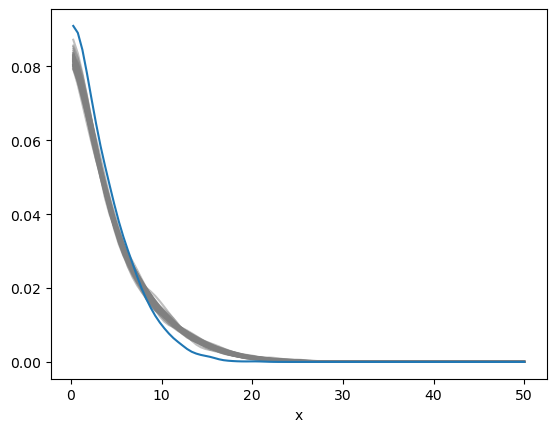

In [160]:
dens_anom_doy.isel(lat=0, lon=0).sel(x=slice(0, None)).plot(
    x="x", hue="member", color='grey', alpha=0.5, add_legend=False);
era5_anom_doy_kde.sel(x=slice(0, None)).plot()

## Daily Plumes

In [161]:
def plot_plume(da, pairs, median=0.5, color="C0", alpha=0.35, lw=1.8,
               figsize=(9, 4.5), x_dim="time", quantile_dim="quantile"):
    """Make a figure with quantile bands and the median line.

    da : xr.DataArray, has `quantile_dim` and `x_dim`
    pairs : Sequence[tuple[float, float]], (lower, upper) quantile labels,
        drawn in the order given — pass widest first
    median : float, quantile label drawn as a line
    color : str, applied to bands and line
    alpha : float, per-band alpha; overlapping bands compound
    lw : float, median line width; bands use lw=0

    Returns (Figure, Axes).
    """
    fig, ax = plt.subplots(figsize=figsize, layout="constrained")
    x = da[x_dim].values
    for lo, hi in pairs:
        ax.fill_between(x, da.sel({quantile_dim: lo}).values,
                        da.sel({quantile_dim: hi}).values,
                        color=color, alpha=alpha, lw=0)
    ax.plot(x, da.sel({quantile_dim: median}).values, color=color, lw=lw)
    ax.margins(x=0)
    return fig, ax

In [162]:
quantiles = np.arange(0, 1.05, 0.05)
n = len(quantiles)//2
quantile_pairs = np.column_stack([quantiles[:n], quantiles[::-1][:n]])
quantile_pairs

array([[0.  , 1.  ],
       [0.05, 0.95],
       [0.1 , 0.9 ],
       [0.15, 0.85],
       [0.2 , 0.8 ],
       [0.25, 0.75],
       [0.3 , 0.7 ],
       [0.35, 0.65],
       [0.4 , 0.6 ],
       [0.45, 0.55]])

In [163]:
hist_member_quantiles = hist_era5_ds.quantile(quantiles, dim=['member']).compute()
hist_doy_member_quantiles = hist_ensemble_anom_doy.quantile(quantiles, dim=['member']).compute()

In [164]:
hist_doy_member_quantiles = hist_doy_member_quantiles.compute()
hist_member_quantiles = hist_member_quantiles.compute()

In [165]:
hist_doy_member_quantiles = hist_doy_member_quantiles.compute()
hist_member_quantiles = hist_member_quantiles.compute()

Text(0.5, 1.0, 'Ensemble Min and Max vs ERA5 for tasmax daily (81.88°S, 120.9°E)')

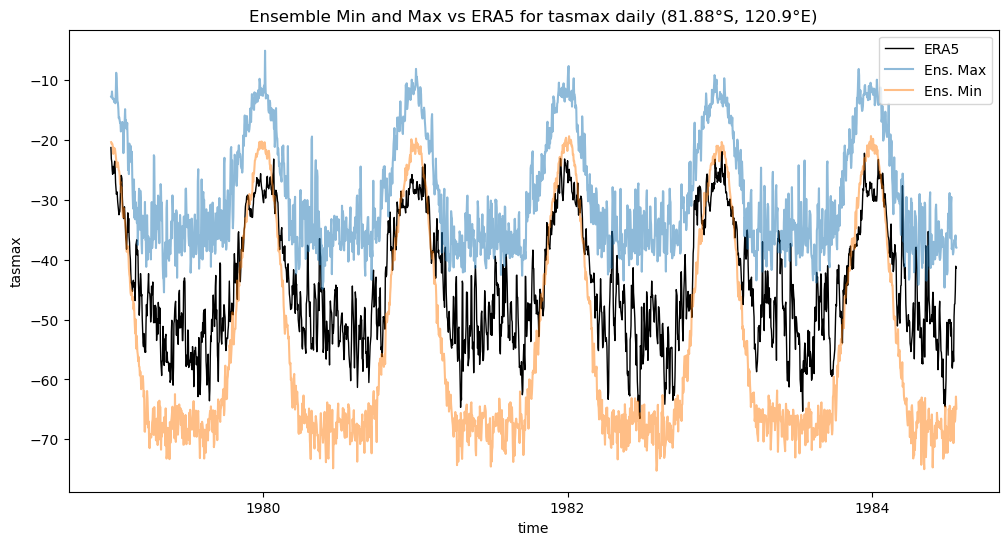

In [166]:
time_slice = slice(0, 2000)

fig, ax = plt.subplots(1, 1, figsize=(12, 6))
era5_loc.isel(time=time_slice).plot(ax=ax, linewidth=1, color='k', label="ERA5")
hist_era5_ds.isel(lat=0, lon=0).isel(time=time_slice).max(dim='member').plot(alpha=0.5, label="Ens. Max")
hist_era5_ds.isel(lat=0, lon=0).isel(time=time_slice).min(dim='member').plot(alpha=0.5, label="Ens. Min")
ax.legend()
ax.set_title(f"Ensemble Min and Max vs ERA5 for tasmax daily ({formatting.format_latlon(latlon)})")

In [167]:
def plot_plume(ax, da, pairs, median=0.5, color="C0", alpha=0.35, lw=1.8,
               x_dim="time", quantile_dim="quantile", label=None):
    """Draw quantile bands and the median line on `ax`.
    ax : matplotlib Axes
    da : xr.DataArray, has `quantile_dim` and `x_dim`
    pairs : Sequence[tuple[float, float]], (lower, upper) quantile labels,
        drawn in the order given — pass widest first
    median : float, quantile label drawn as a line
    color : str, applied to bands and line
    alpha : float, per-band alpha; overlapping bands compound
    lw : float, median line width; bands use lw=0
    Returns the median Line2D.
    """
    x = da[x_dim].values
    for lo, hi in pairs:
        ax.fill_between(x, da.sel({quantile_dim: lo}).values,
                        da.sel({quantile_dim: hi}).values,
                        color=color, alpha=alpha, lw=0)
    line, = ax.plot(x, da.sel({quantile_dim: median}).values,
                    color=color, lw=lw, label=label)
    ax.margins(x=0)
    return line

In [168]:
def plot_clim(ax, clim_da, x_da, x_dim="time", color="C3", lw=1.2, ls="--", label=None, alpha=0.8):
    """Draw a day-of-year climatology against the time axis of `x_da`.
    clim_da : xr.DataArray, single point, dim `dayofyear`
    x_da : xr.DataArray, supplies the `x_dim` coord to expand the climatology onto
    Returns the Line2D.
    """
    doy = x_da[x_dim].dt.dayofyear
    line, = ax.plot(x_da[x_dim].values, clim_da.sel(dayofyear=doy).values,
                    color=color, lw=lw, ls=ls, label=label, alpha=alpha)
    return line

In [169]:

def style_axes(ax):
    """Grid behind the data, top/right spines dropped, muted ticks and spines."""
    ax.set_axisbelow(True)
    ax.grid(True, axis="y", color="0.85", lw=0.6)
    ax.grid(True, axis="x", color="0.93", lw=0.5)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color("0.45")
        ax.spines[side].set_linewidth(0.8)
    ax.tick_params(colors="0.3", length=4, width=0.8)
    ax.margins(y=0.08)

Text(0.5, 0.98, 'Ensemble plume vs ERA5, tasmax (81.88°S, 120.9°E)')

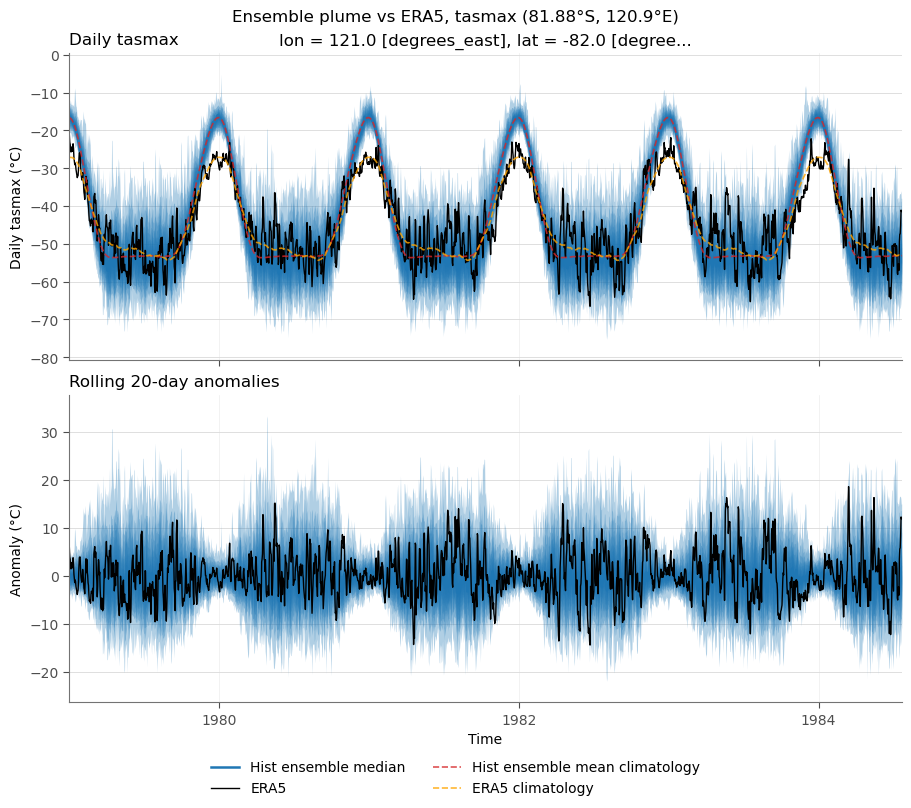

In [170]:
time_slice = slice(0, 2000)
point = dict(lat=0, lon=0)

panels = {
    "Daily tasmax": {
        "unit": "Daily tasmax (°C)",
        "plume": hist_member_quantiles.isel(**point, time=time_slice),
        "era5": era5_loc.isel(time=time_slice),
        "clims": {
            "Hist ensemble mean climatology": {
                "da": hist_doy_climatology.isel(**point).mean("member"),
                "x": hist_member_quantiles.isel(**point, time=time_slice),
                "color": "C3",
            },
            "ERA5 climatology": {
                "da": era5_doy_climatology,
                "x": era5_loc.isel(time=time_slice),
                "color": "orange",
            },
        },
    },
    "Rolling 20-day anomalies": {
        "unit": "Anomaly (°C)",
        "plume": hist_doy_member_quantiles.isel(**point, time=time_slice),
        "era5": era5_doy_anom.isel(time=time_slice),
        "clims": {},
    },
}

fig, axes = plt.subplots(2, 1, figsize=(9, 8), layout="constrained", sharex=True)

for ax, (title, panel) in zip(axes, panels.items()):
    plot_plume(ax, panel["plume"], quantile_pairs, label="Hist ensemble median")
    panel["era5"].plot(ax=ax, linewidth=1, color="k", label="ERA5")
    for clim_label, clim in panel["clims"].items():
        plot_clim(ax, clim["da"], clim["x"], color=clim["color"], label=clim_label)
    ax.set_title(title, loc="left")
    ax.set_ylabel(panel["unit"])
    ax.set_xlabel("")
    style_axes(ax)




axes[-1].set_xlabel("Time")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="outside lower center", ncols=2, frameon=False)
fig.suptitle(f"Ensemble plume vs ERA5, tasmax ({formatting.format_latlon(latlon)})")

<b> Interpretation <b>

- During Austral winter the observations is within the range of the mdoel spread
- During Austral summer, however, the model is much too hot. The observations is below the minimum of the ensemble range.
- The Austral summer median appears to be ~10degC too hot.
- This suggest that the seasonal cycyle is too strong (variability is too large)

# PR ensemble

## Day-of-year climatology

In [25]:
import xarray_calc
import dask

In [26]:
def year_season(da):
    """Split a quarterly time axis into separate year and season dimensions.

    Takes a DataArray whose ``time`` dim is quarterly (e.g. the output of
    ``resample(time='QE-DEC')``) and unstacks it so that ``year`` and
    ``season`` become independent dims. This lets a rolling window move
    N years within a single season rather than N/4 years across all four.

    The year assigned to each season comes from the resample label, so DJF
    is indexed by its January year under ``QE-DEC`` and by its December year
    under ``QS-DEC``. Partial years at the ends of the record are padded
    with NaN.

    Parameters
    ----------
    da : xr.DataArray
        Quarterly data with a ``time`` dim.

    Returns
    -------
    xr.DataArray
        Same data with ``time`` replaced by ``year`` and ``season`` dims.
        Seasons are ordered alphabetically (DJF, JJA, MAM, SON), not
        chronologically.
    """
    return (
        da.assign_coords(year=da.time.dt.year, season=da.time.dt.season)
        .set_index(time=('year', 'season'))
        .unstack('time')
    )

In [27]:
def rolling_quantile_exceedance_dayofyear(da, q_da, resample_freq='QS-DEC', year_window: int = 21
                                         ) -> xr.Dataset:
    """Rolling exceedance rate relative to a seasonal quantile threshold.

    Counts timesteps in each resampled season that exceed the matching seasonal
    threshold, then accumulates those counts (and the number of valid timesteps)
    over a centred rolling window to give an exceedance probability.

    Args:
        da (xr.DataArray): Input data with a 'time' coordinate.
        q_da (xr.DataArray): Thresholds with a 'season' dim, broadcast against the seasonal groups of `da`.
        resample_freq (str): Frequency used to bin timesteps into seasons.
        year_window (int): Width of the centred rolling window, in years.

    Returns:
        xr.Dataset: 'pr' (exceedance probability), 'exceed' and 'total' (rolling counts).
            `resample_freq` and `year_window` are recorded in the attrs.
    """
    # per-season counts of exceedances and of valid timesteps
    n_exceed_da = (da > q_da).resample(time=resample_freq).sum()
    n_total_da = da.resample(time=resample_freq).count()

    # move onto a (year, season) index, then accumulate over the centred window
    roll_exceed_da = year_season(n_exceed_da).rolling(year=year_window, center=True).sum()
    roll_total_da = year_season(n_total_da).rolling(year=year_window, center=True).sum()

    # fraction of timesteps in the window above the threshold
    p_da = roll_exceed_da / roll_total_da
    
    roll_exceed_da.name = 'exceed'
    roll_total_da.name = 'total'
    p_da.name = 'p'

    ds = xr.merge([p_da, roll_total_da, roll_exceed_da])
    ds.attrs['resample_freq'] = resample_freq
    ds.attrs['year_window'] = year_window
    return ds

In [28]:
# Calculation below needs full years
# histnat_ensemble_ds = histnat_ensemble_ds.sel(time=slice('1851', '2013'))

In [29]:
histnat_ensemble_ds = histnat_ensemble_ds.isel(lat=slice(0, 2), lon=slice(0,2)).persist()
wait(hist_ensemble_ds);

In [30]:
histnat_ensemble_ds

<xarray.DataArray 'tasmax' (member: 49, time: 59310, lat: 2, lon: 2)> Size: 46MB
dask.array<chunksize=(11, 59310, 2, 2), meta=np.ndarray>
Coordinates:
  * member   (member) object 392B 'r10i1p1f3' 'r11i1p1f3' ... 'r54i1p1f3'
    height   float64 8B ...
  * lon      (lon) float64 16B 120.9 122.8
  * time     (time) object 474kB 1850-03-01 12:00:00 ... 2014-11-30 12:00:00
  * lat      (lat) float64 16B -81.88 -80.62

In [158]:
year_window = 21
q = [0.9, 0.95, 0.99, 0.999]

In [32]:
#(t) Quantiles for 20-day rolling climatology

da = histnat_ensemble_ds.chunk({"time": -1, "member": 1, "lat": 1, "lon": 1}).persist()
wait(da);

half = year_window // 2

reshaped = (
    da.assign_coords(year=da.time.dt.year, dayofyear=da.time.dt.dayofyear)
    .set_index(time=["year", "dayofyear"])
    .unstack("time")
)

padded = reshaped.pad(dayofyear=half, mode="wrap")
windowed = padded.rolling(dayofyear=year_window, center=True).construct("window")
q_histnat_doy = windowed.isel(dayofyear=slice(half, -half)).quantile(q, dim=["window", "year"]).compute()
# q_histnat_doy = window_q

In [33]:
#(t): Probability hist nat
threshold_hist_doy = q_histnat_doy.sel(dayofyear=hist_ensemble_ds.time.dt.dayofyear).compute()
p_hist_doy = rolling_quantile_exceedance_dayofyear(hist_ensemble_ds, threshold_hist_doy, year_window=year_window)
p_hist_doy = p_hist_doy.compute()

In [34]:
#(t): Probability hist
threshold_histnat_doy = q_histnat_doy.sel(dayofyear=histnat_ensemble_ds.time.dt.dayofyear).compute()
p_histnat_doy = rolling_quantile_exceedance_dayofyear(histnat_ensemble_ds, threshold_histnat_doy, year_window=year_window)
p_histnat_doy = p_histnat_doy.compute()

In [130]:
#(t): Probability Ratio (PR)
pr_doy = p_hist_doy.p/p_histnat_doy.p

In [131]:
#| title: Member pooled PR
#| caption: Insstead of calculating the PR members, the results is pooled across members. This allows the PR to be 
#| estimate per year still, but also to have a larger sample size per year. This will also be useful, as this should 
#| not matter as much if some models have less ensemble members

p_hist_1y_doy = rolling_quantile_exceedance_dayofyear(hist_ensemble_ds, threshold_hist, year_window=1)

p_member_pool_1y_doy = p_hist_1y_doy.exceed.sum(dim='member')/p_hist_1y_doy.total.sum(dim='member')
p_member_pool_1y_doy = p_member_pool_1y_doy.compute()

In [134]:
p_histnat_1y_doy = rolling_quantile_exceedance_dayofyear(
    histnat_ensemble_ds, threshold_histnat_doy, year_window=1)

p_histnat_member_pool_1y_doy = p_histnat_1y_doy.exceed.sum(dim='member')/p_histnat_1y_doy.total.sum(dim='member')

p_histnat_member_pool_1y_doy = p_histnat_member_pool_1y_doy.compute()

In [137]:
#(t): Probability Ratio (PR)
pr_member_pool_1y_doy = p_member_pool_1y_doy/p_histnat_member_pool_1y_doy

## PR ensemble: Seasonal

In [37]:
selection_kwargs = dict(lat=0, lon=0, season=0, member=0, quantile=0)

In [38]:
print(np.take(hist_ensemble_ds.time.values, [0, -1]))

[cftime.Datetime360Day(1850, 3, 1, 12, 0, 0, 0, has_year_zero=True)
 cftime.Datetime360Day(2014, 11, 30, 12, 0, 0, 0, has_year_zero=True)]


In [39]:
#| title: Quantile calculation for hist
q_histnat = histnat_ensemble_ds.groupby('time.season').quantile([0.9, 0.95, 0.99, 0.999], dim='time').compute()

In [40]:
q_histnat

<xarray.DataArray 'tasmax' (member: 49, season: 4, lat: 2, lon: 2, quantile: 4)> Size: 25kB
-16.25 -15.1 -12.94 -10.47 -16.02 -14.89 ... -17.82 -26.72 -24.41 -21.06 -17.58
Coordinates:
  * member    (member) object 392B 'r10i1p1f3' 'r11i1p1f3' ... 'r54i1p1f3'
    height    float64 8B 1.5
  * lon       (lon) float64 16B 120.9 122.8
  * lat       (lat) float64 16B -81.88 -80.62
  * quantile  (quantile) float64 32B 0.9 0.95 0.99 0.999
  * season    (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'

In [163]:
q_histnat_doy

<xarray.DataArray 'tasmax' (quantile: 3, member: 49, lat: 2, lon: 2,
                            dayofyear: 360)> Size: 2MB
-14.45 -14.46 -14.51 -14.55 -14.57 -14.6 ... -11.97 -11.89 -11.84 -11.84 -11.95
Coordinates:
  * dayofyear  (dayofyear) int64 3kB 1 2 3 4 5 6 7 ... 355 356 357 358 359 360
  * member     (member) object 392B 'r10i1p1f3' 'r11i1p1f3' ... 'r54i1p1f3'
  * lon        (lon) float64 16B 120.9 122.8
  * lat        (lat) float64 16B -81.88 -80.62
  * quantile   (quantile) float64 24B 0.9 0.95 0.99

In [41]:
#| title: histnat probability
#| caption: probability each season of exceeding the histnat percentiles.
# 'total' as there is a single value per season, not a rolling one.
# Season thresholds: should equal 1 - q.
# Day-of-year thresholds: sits below 1 - q, since the 21-day window pools days
# with different climatological means and so inflates the threshold.

threshold_season = q_histnat.sel(season=histnat_ensemble_ds.time.dt.season)
p_histnat_total = (histnat_ensemble_ds > threshold_season).groupby("time.season").mean().compute()

threshold_doy = q_histnat_doy.sel(dayofyear=histnat_ensemble_ds.time.dt.dayofyear)
p_histnat_doy_total = (histnat_ensemble_ds > threshold_doy).groupby("time.season").mean().compute()

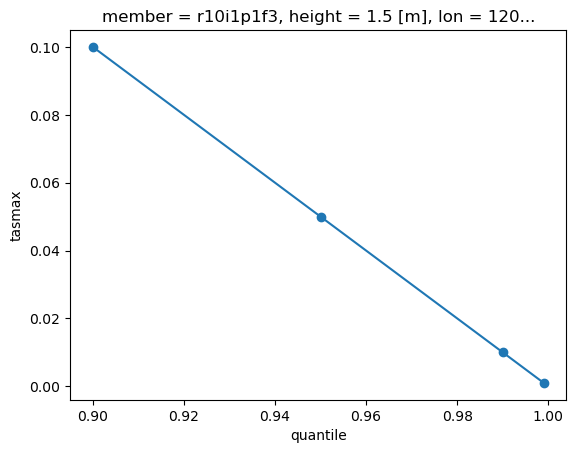

In [42]:
#| quantile-matching theoretical value
p_histnat_total.isel(lat=0, lon=0, member=0, season=0).squeeze(drop=True).plot(marker='o')

In [43]:
hist_ensemble_ds

<xarray.DataArray 'tasmax' (member: 55, time: 59310, lat: 4, lon: 5)> Size: 261MB
dask.array<chunksize=(11, 59310, 4, 5), meta=np.ndarray>
Coordinates:
  * time     (time) object 474kB 1850-03-01 12:00:00 ... 2014-11-30 12:00:00
  * member   (member) object 440B 'r16i1p1f3' 'r17i1p1f3' ... 'r60i1p1f3'
  * lat      (lat) float64 32B -81.88 -80.62 -79.38 -78.12
  * lon      (lon) float64 40B 120.9 122.8 124.7 126.6 128.4
    height   float64 8B ...

In [44]:
q_histnat

<xarray.DataArray 'tasmax' (member: 49, season: 4, lat: 2, lon: 2, quantile: 4)> Size: 25kB
-16.25 -15.1 -12.94 -10.47 -16.02 -14.89 ... -17.82 -26.72 -24.41 -21.06 -17.58
Coordinates:
  * member    (member) object 392B 'r10i1p1f3' 'r11i1p1f3' ... 'r54i1p1f3'
    height    float64 8B 1.5
  * lon       (lon) float64 16B 120.9 122.8
  * lat       (lat) float64 16B -81.88 -80.62
  * quantile  (quantile) float64 32B 0.9 0.95 0.99 0.999
  * season    (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'

In [49]:
histnat_ensemble_ds = histnat_ensemble_ds.chunk({'member':11, 'time':-1, 'lat':-1, 'lon':-1}).persist()
wait(histnat_ensemble_ds);

<b> Probabilities

In [59]:
#(t): Probability hist
threshold_season_hist = q_histnat.sel(season=hist_ensemble_ds.time.dt.season).compute()

p_hist_rolling = rolling_quantile_exceedance_dayofyear(
    hist_ensemble_ds, threshold_season_hist, year_window=year_window)

p_hist_rolling = p_hist_rolling.compute()

In [60]:
#(t): Probability histnat
threshold_season_histnat = q_histnat.sel(season=histnat_ensemble_ds.time.dt.season).compute()#

p_histnat_rolling = rolling_quantile_exceedance_dayofyear(
    histnat_ensemble_ds, threshold_season_histnat, year_window=year_window)

p_histnat_rolling = p_histnat_rolling.compute()

In [68]:
#| title: Member pooled PR
#| caption: Insstead of calculating the PR members, the results is pooled across members. This allows the PR to be 
#| estimate per year still, but also to have a larger sample size per year. This will also be useful, as this should 
#| not matter as much if some models have less ensemble members

p_hist_1y = rolling_quantile_exceedance_dayofyear(
    hist_ensemble_ds, threshold_season_hist, year_window=1)

p_member_pool_1y = p_hist_1y.exceed.sum(dim='member')/p_hist_1y.total.sum(dim='member')
p_member_pool_1y = p_member_pool_1y.compute()

In [69]:
p_histnat_1y = rolling_quantile_exceedance_dayofyear(
    histnat_ensemble_ds, threshold_season_histnat, year_window=1)

p_histnat_member_pool_1y = p_histnat_1y.exceed.sum(dim='member')/p_histnat_1y.total.sum(dim='member')

p_histnat_member_pool_1y = p_histnat_member_pool_1y.compute()

<b> Probability Ratios

In [54]:
#(t): Probability Ratios of the historical
#(c): Rolling probability divided by probability each season
pr_hist = p_hist_rolling.p/p_histnat_total

In [56]:
#(t): Probability Ratios of the hist nat
#(c): Rolling probability divided by probability each season
pr_histnat = p_histnat_rolling.p/p_histnat_total

In [58]:
#(t): PR but with both rolling
pr_hist_rolling = p_hist_rolling/p_histnat_rolling

In [70]:
#(t): PR but with individual years
pr_member_pool_1y = p_member_pool_1y/p_histnat_member_pool_1y

# pr_1y = p_hist_1y.p/p_histnat_total

## Plots

In [87]:
from matplotlib.gridspec import GridSpecFromSubplotSpec

In [113]:
def draw_panel(ax, vals):
    members = np.arange(len(vals))
    vals = np.sort(vals)
    vmin, vmax = np.nanmin(vals), np.nanmax(vals)
    pad = 0.05 * (vmax - vmin)

    ax.bar(members, vals, width=0.75, color='#3b6ea5', edgecolor='none', zorder=3)
    ax.set_ylim(vmin - pad, vmax + pad)
    ax.set_xlim(-0.75, len(members) - 0.25)
    ax.grid(axis='y', color='0.9', lw=0.7)
    ax.set_axisbelow(True)
    ax.tick_params(labelsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

In [139]:
def plot_quantile_seasons(da, fig, gridspec, hlines):
    """Plot a stack of seasonal panels for each quantile, one stack per grid cell.

    Args:
        da (xr.DataArray): Data with 'quantile' and 'season' dimensions.
        fig (matplotlib.figure.Figure): Figure to draw into.
        gridspec (matplotlib.gridspec.GridSpec): Parent grid; cell i holds quantile i.
        hlines (list[tuple[float, str]]): (y, colour) pairs drawn on every panel.

    Returns:
        list[list[matplotlib.axes.Axes]]: Per-quantile lists of stacked axes.
    """
    quantiles = da['quantile'].values
    return [
        plot_season_stack(da.sel(quantile=q), fig, gridspec[i],
                          f'{q*100:g}th Percentile', hlines)
        for i, q in enumerate(quantiles)
    ]

In [149]:
def plot_season_stack(das, fig, subplot_spec, title, hlines):
    """Plot each season as a stacked panel, overlaying one line per labelled array.

    Args:
        das (dict[str, xr.DataArray]): Label -> data with a 'season' dimension.
        fig (matplotlib.figure.Figure): Figure to draw into.
        subplot_spec (matplotlib.gridspec.SubplotSpec): Parent grid cell to subdivide.
        title (str): Title placed above the top panel.
        hlines (list[tuple[float, str]]): (y, colour) pairs drawn on every panel.

    Returns:
        list[matplotlib.axes.Axes]: Stacked axes, top to bottom.
    """
    seasons = next(iter(das.values())).season.values
    gs = GridSpecFromSubplotSpec(len(seasons), 1, subplot_spec=subplot_spec, hspace=0)
    axes = [fig.add_subplot(gs[i]) for i in range(len(seasons))]

    for ax, season in zip(axes, seasons):
        for label, da in das.items():
            da.sel(season=season).plot(ax=ax, label=label, linewidth=1.6)
        for y, colour in hlines:
            ax.axhline(y, color=colour, linestyle='--', linewidth=1.4, alpha=0.8)
        ax.set_title(None)
        ax.set_xlabel(None)
        ax.set_ylabel(None)
        ax.grid(True, linestyle='--', color='grey', alpha=0.6)
        ax.tick_params(labelsize=12, labelbottom=False)
        ax.annotate(season, xy=(0.015, 0.78), xycoords='axes fraction',
                    fontsize=15, fontweight='bold')

    ylims = [ax.get_ylim() for ax in axes]
    for ax in axes:
        ax.set_ylim(np.min(ylims), np.max(ylims))

    axes[-1].tick_params(labelbottom=True)
    axes[-1].set_xlabel('time', fontsize=13)
    axes[0].set_title(title, loc='left', fontweight='bold', fontsize=15)
    axes[0].legend(loc='lower right', bbox_to_anchor=(1, 1),
                   ncols=len(das), frameon=False, fontsize=12)
    return axes

[<Axes: title={'left': '99th Percentile'}>,
 <Axes: >,
 <Axes: >,
 <Axes: xlabel='time'>]

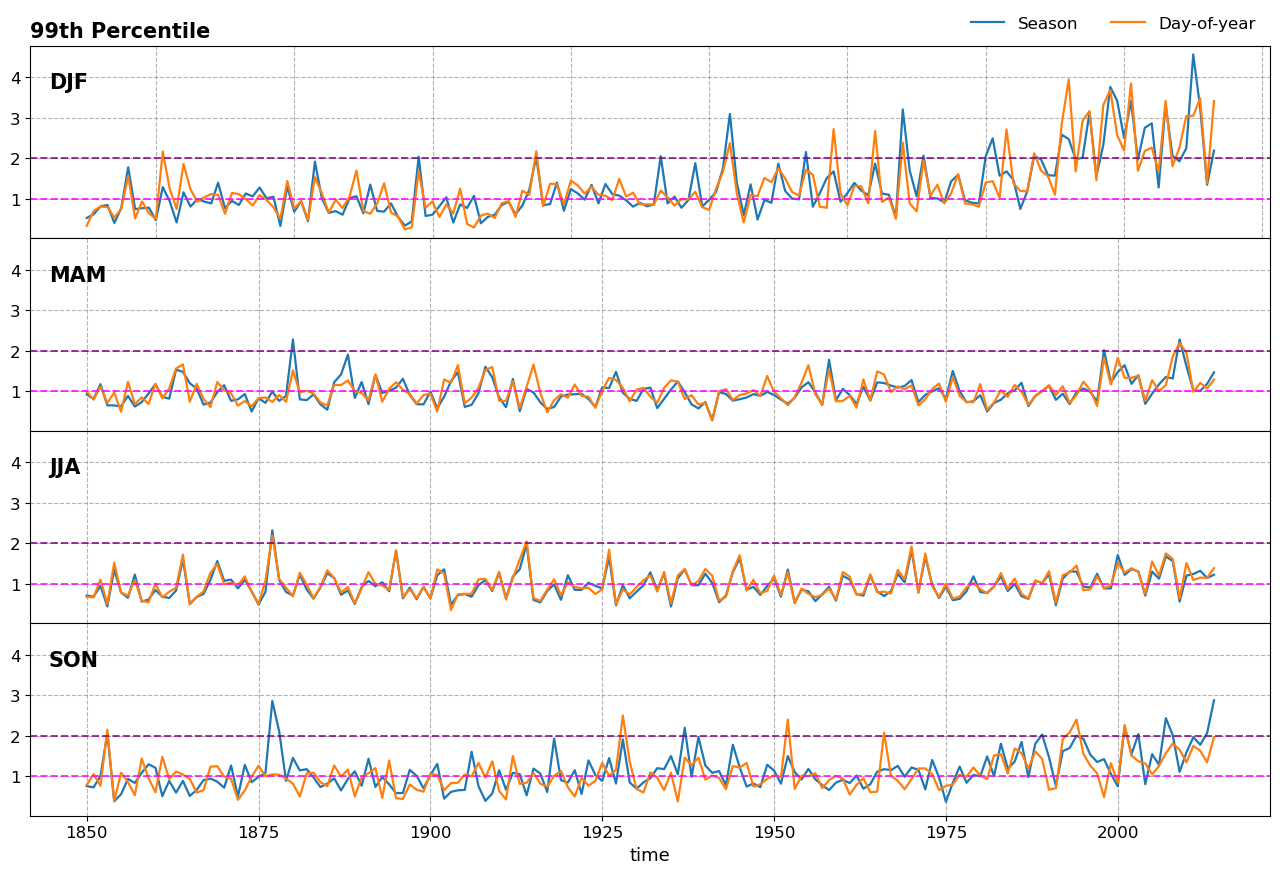

In [153]:
quant = 0.99
seasons = ['DJF', 'MAM', 'JJA', 'SON']

das = {
    'Season': pr_member_pool_1y.isel(lat=0, lon=0).sel(quantile=quant, season=seasons),
    'Day-of-year': pr_member_pool_1y_doy.isel(lat=0, lon=0).sel(quantile=quant, season=seasons),
}

fig = plt.figure(figsize=(16, 10))
gs = GridSpec(1, 1)
plot_season_stack(das, fig, gs[0], f'{quant*100:g}th Percentile',
                  [(1, 'magenta'), (2, 'purple')])

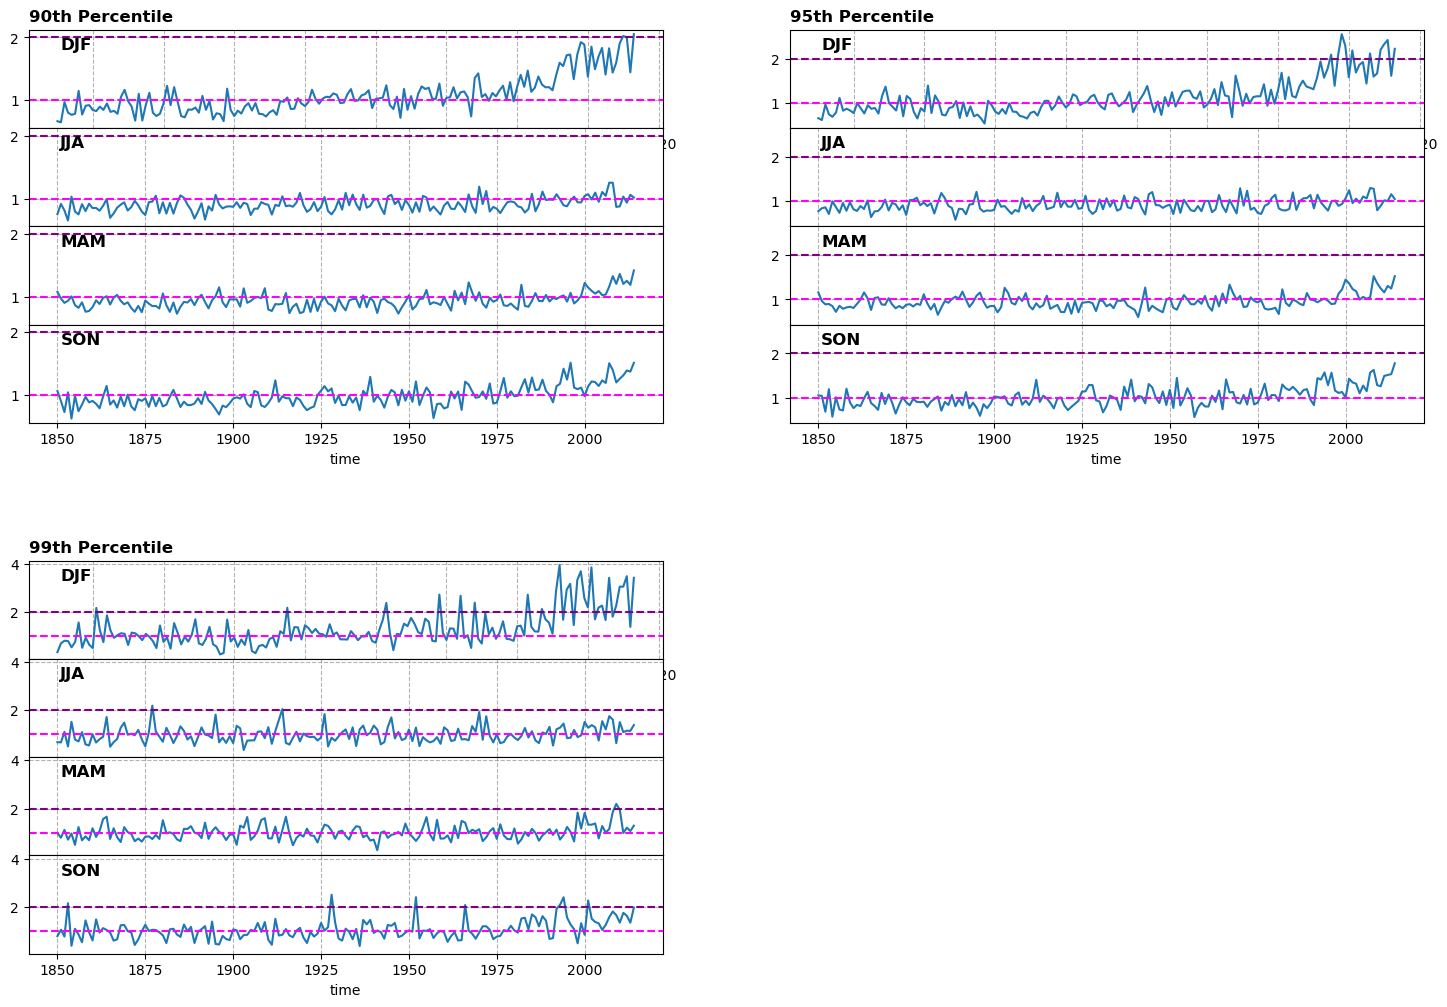

In [146]:
fig = plt.figure(figsize=(18, 12))
gs = GridSpec(2, 2, hspace=0.35)
plot_quantile_seasons(pr_member_pool_1y_doy.isel(lat=0, lon=0), fig, gs,
                      [(1, 'magenta'), (2, 'purple')]);

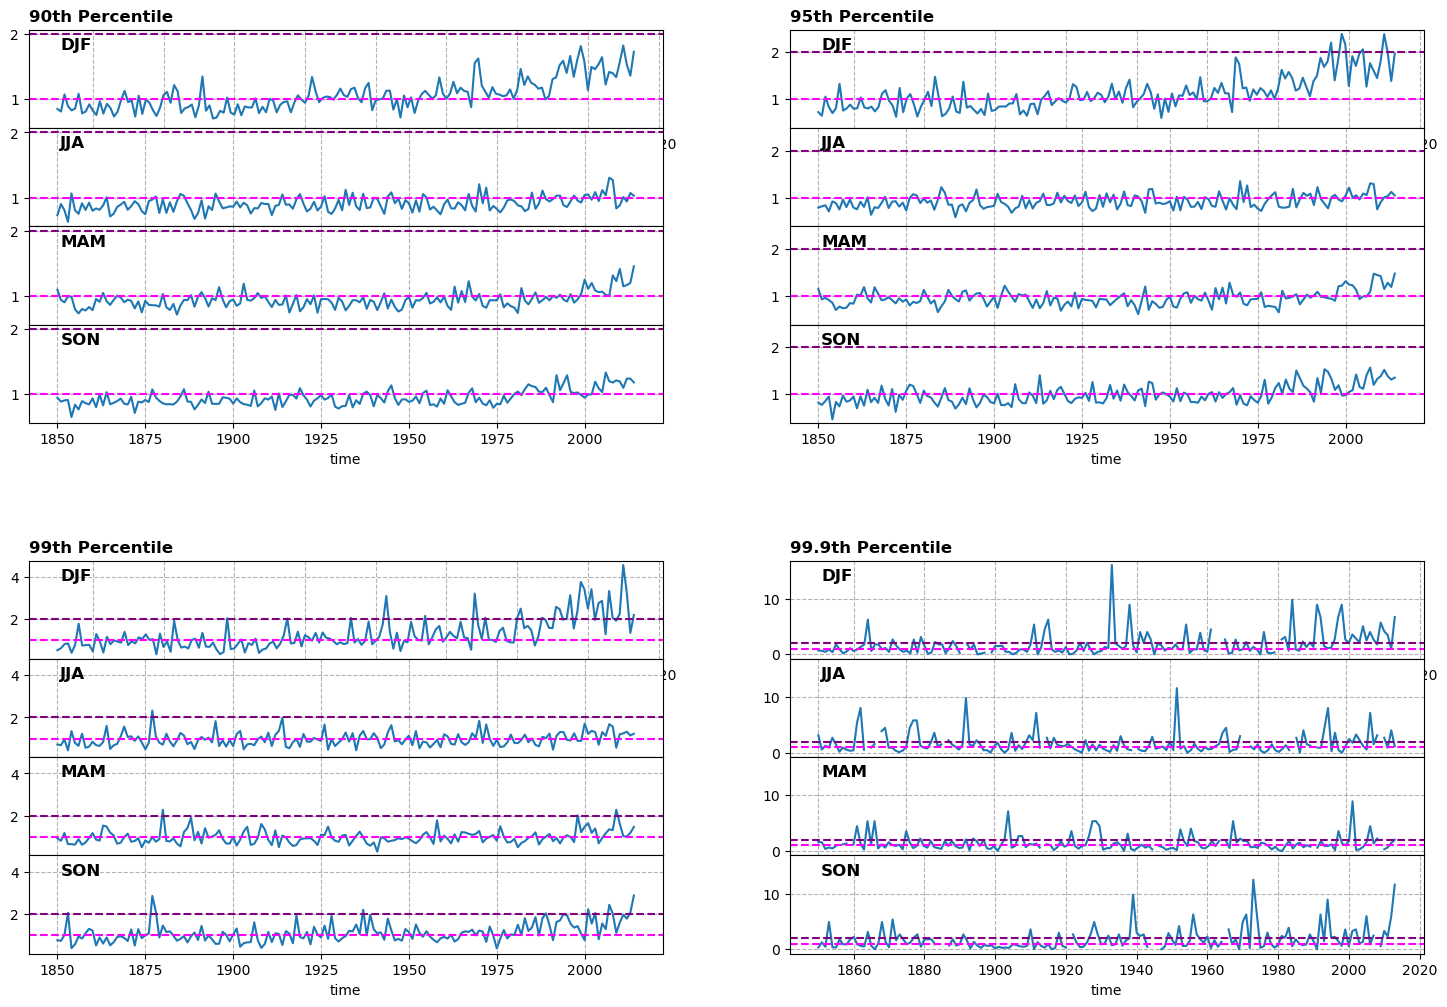

In [145]:
fig = plt.figure(figsize=(18, 12))
gs = GridSpec(2, 2, hspace=0.35)
plot_quantile_seasons(pr_member_pool_1y.isel(lat=0, lon=0), fig, gs,
                      [(1, 'magenta'), (2, 'purple')]);

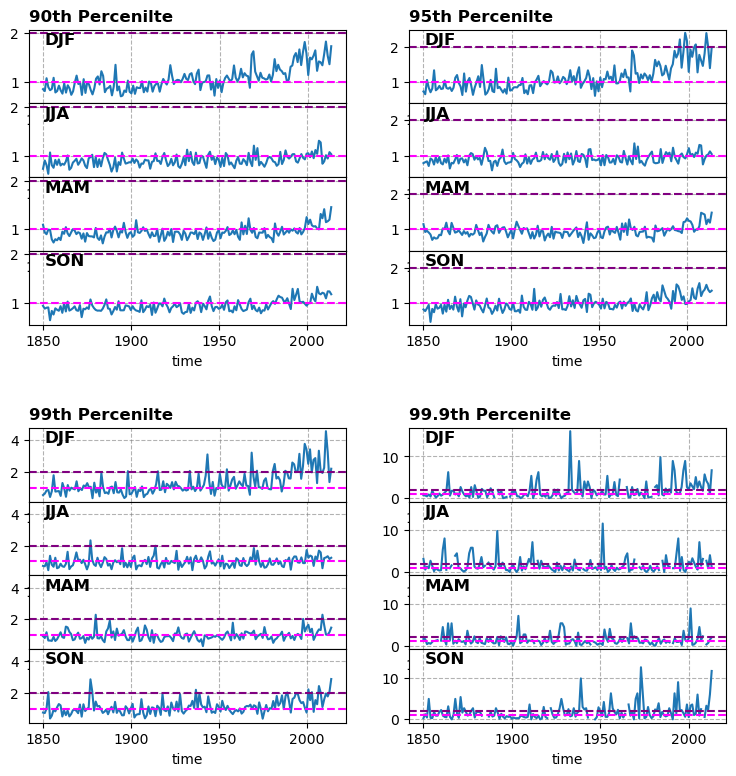

In [112]:
quantiles = pr_member_pool_1y['quantile'].values
seasons = pr_member_pool_1y.season.values

fig = plt.figure(figsize=(9, 9))
gs = GridSpec(2, 2, hspace=0.35)

# axes = [fig.add_subplot(gs[i]) for i in range(quantiles.shape[0])]

for i, quant in enumerate(quantiles):

    gs_sub = GridSpecFromSubplotSpec(len(seasons), 1, subplot_spec=gs[i], hspace=0)
    axes = [fig.add_subplot(gs_sub[i]) for i in range(quantiles.shape[0])]
    
    for j,season in enumerate(seasons):
        ax = axes[j]
    
        pr_member_pool_1y.isel(lat=0, lon=0).sel(quantile=quant, season=season).plot(ax=ax);
        ax.axhline(1, color='magenta', linestyle='--')
        ax.axhline(2, color='purple', linestyle='--')
        ax.set_title(None)
        
        ax.grid(True, linestyle='--', color='grey', alpha=0.6)
        ax.annotate(season, xy=(0.05, 0.8), xycoords='axes fraction', fontsize=12, fontweight='bold')

    ylims = [ax.get_ylim() for ax in axes]
    [ax.set_ylim(np.min(ylims), np.max(ylims)) for ax in axes]
    axes[0].set_title(f'{quant*100:g}th Percenilte', loc='left', fontweight='bold')

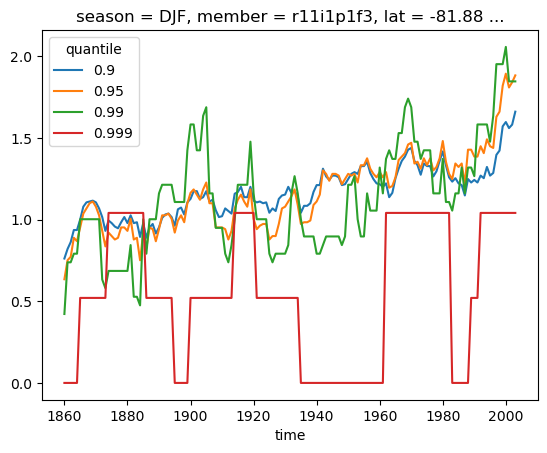

In [55]:
pr_hist.isel(season=0, member=0, lat=0, lon=0).plot(x='year', hue='quantile');

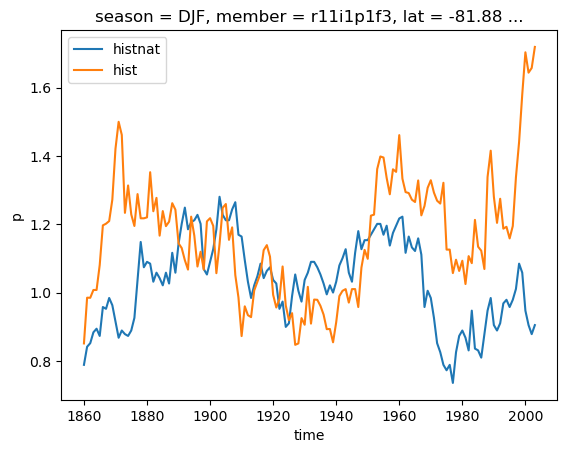

In [57]:
pr_histnat.isel(selection_kwargs).plot(label='histnat')
pr.isel(selection_kwargs).plot(label='hist')
plt.legend()

Text(0.5, 0.98, 'Thresholds for different percentiles (DJF)')

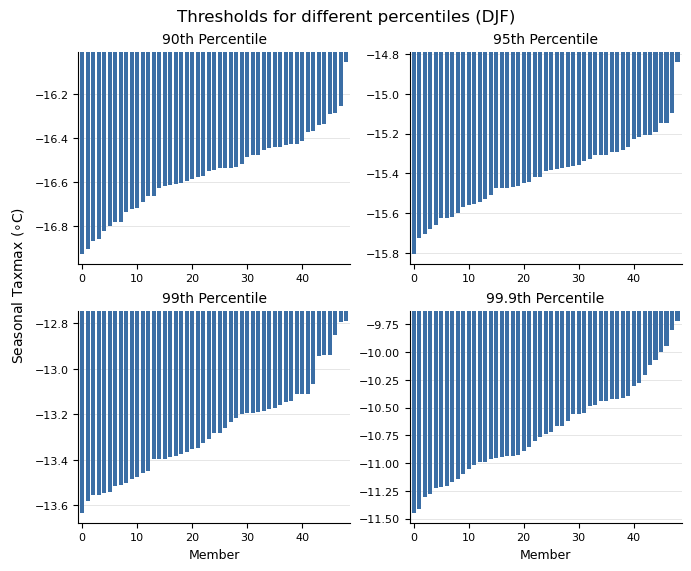

In [114]:
#! title: Threshold for different percentiles for tasmax

season = 'DJF'

point = q_histnat.isel(lat=0, lon=0).sel(season=season)
quantiles = point['quantile'].values

ncols = min(len(quantiles), 2)
nrows = int(np.ceil(len(quantiles) / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(3.4 * ncols, 2.8 * nrows),
    squeeze=False,
    layout='constrained',
)

for i in range(len(quantiles)):
    ax = axes.flat[i]
    draw_panel(ax, point.isel(quantile=i).values)
    ax.set_title(f'{quantiles[i]*100:g}th Percentile', fontsize=10)
    if i >= len(quantiles) - ncols:
        ax.set_xlabel('Member', fontsize=9)

for ax in axes.flat[len(quantiles):]:
    ax.remove()

fig.supylabel('Seasonal Taxmax ' + r'($\circ$C)', fontsize=10)

fig.suptitle(f"Thresholds for different percentiles ({season})")

In [115]:
pr_member_pool_1y

<xarray.DataArray (lat: 2, lon: 2, quantile: 4, year: 165, season: 4)> Size: 84kB
0.852 0.7307 1.095 0.9442 0.8127 0.9009 ... 0.8909 3.118 nan 1.002 2.227 inf
Coordinates:
  * year      (year) int64 1kB 1850 1851 1852 1853 1854 ... 2011 2012 2013 2014
  * season    (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
  * lat       (lat) float64 16B -81.88 -80.62
  * lon       (lon) float64 16B 120.9 122.8
  * quantile  (quantile) float64 32B 0.9 0.95 0.99 0.999
    height    float64 8B 1.5

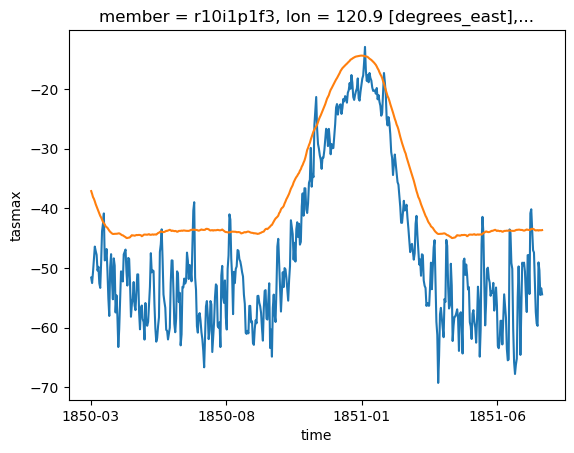

In [116]:
tda = histnat_ensemble_ds.isel(lat=0, lon=0, member=0).isel(time=slice(0, 500))
tqa = q_histnat_doy.isel(quantile=0, lat=0, lon=0, member=0)

tqa = tqa.sel(dayofyear=tda.time.dt.dayofyear)
tda.plot()
tqa.plot()

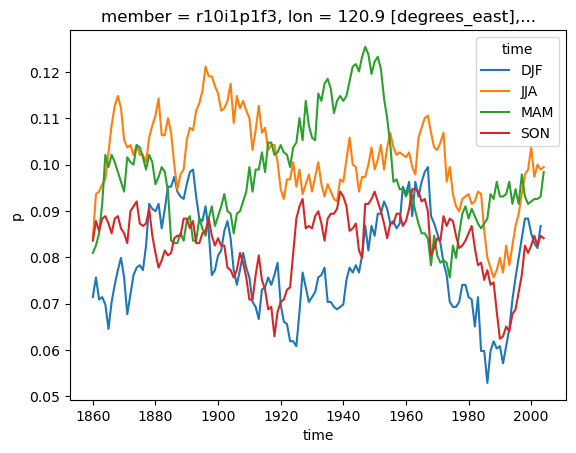

In [117]:
#(t): Histnat probabilities
#(c): This is not expected to match the theorical exactly, as is is done on a 21-day rolling window
p_histnat_doy.p.isel(quantile=0, member=0, lat=0, lon=0).plot(x='year', hue='season');

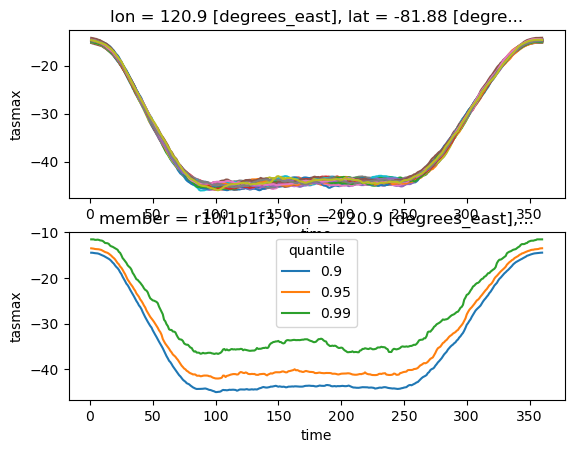

In [118]:
fig, (ax1, ax2) = plt.subplots(2, 1)
q_histnat_doy.isel(lat=0, lon=0, quantile=0).plot(ax=ax1, x='dayofyear', hue='member', add_legend=False);
q_histnat_doy.isel(lat=0, lon=0, member=0).plot(ax=ax2, x='dayofyear', hue='quantile');

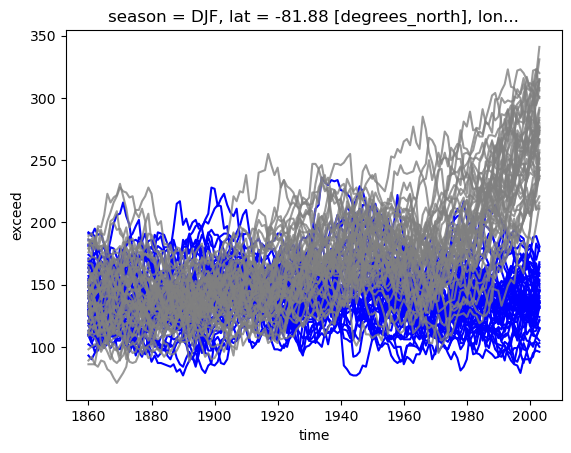

In [119]:
p_histnat_doy.exceed.isel(season=0, lat=0, lon=0, quantile=0).plot(hue='member', add_legend=False, color='blue');
p_hist_doy.exceed.isel(season=0, lat=0, lon=0, quantile=0).plot(hue='member', add_legend=False,
                                                                color='grey', alpha=0.8);

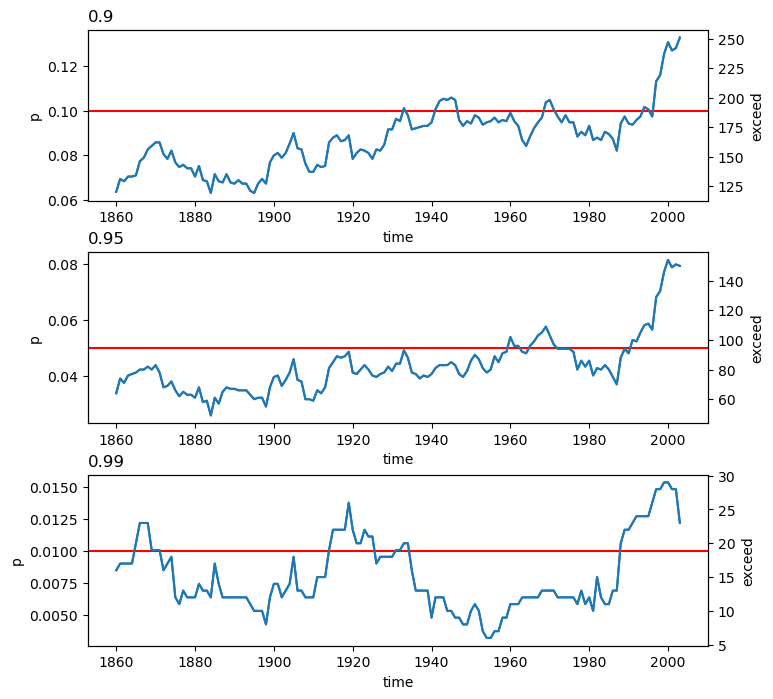

In [120]:
fig = plt.figure(figsize=(8, 8))
gs = GridSpec(p_hist_doy.sizes["quantile"], 1, hspace=0.3)
axes = [fig.add_subplot(gs[i]) for i in range(p_hist_doy.sizes["quantile"])]

for i, quan in enumerate(p_hist_doy["quantile"].values):
    ax = axes[i]; ax_twinx = ax.twinx()
    p_hist_doy.p.isel(lat=0, lon=0, member=0, season=0).sel(quantile=quan).plot(ax=ax);
    p_hist_doy.exceed.isel(lat=0, lon=0, member=0, season=0).sel(quantile=quan).plot(ax=ax_twinx)
    ax.set_title(quan, loc="left"); ax.set_title(None); ax_twinx.set_title(None)
    ax.axhline(1-quan, color='red', zorder=100)

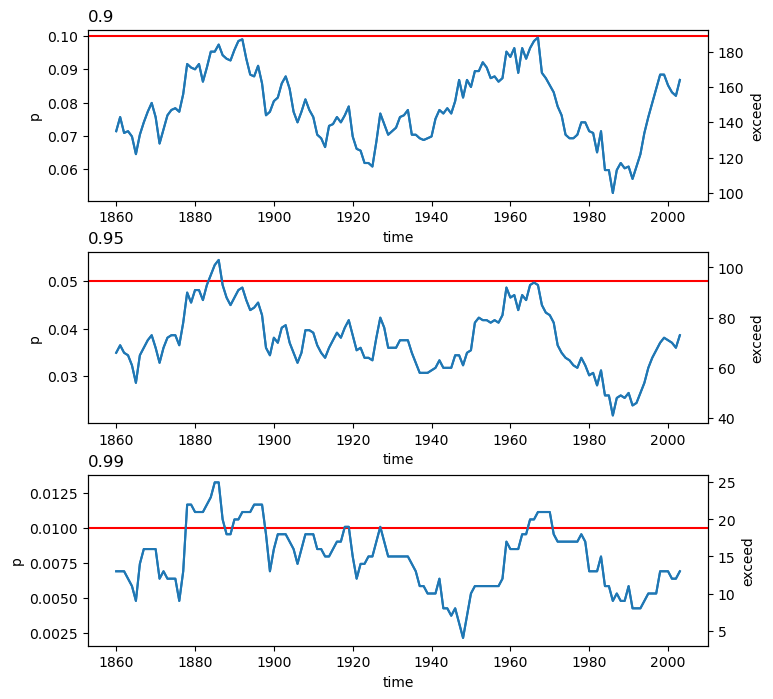

In [121]:
fig = plt.figure(figsize=(8, 8))
gs = GridSpec(p_histnat_doy.sizes["quantile"], 1, hspace=0.3)
axes = [fig.add_subplot(gs[i]) for i in range(p_histnat_doy.sizes["quantile"])]

for i, quan in enumerate(p_hist_doy["quantile"].values):
    ax = axes[i]; ax_twinx = ax.twinx()
    p_histnat_doy.p.isel(lat=0, lon=0, member=0, season=0).sel(quantile=quan).plot(ax=ax);
    p_histnat_doy.exceed.isel(lat=0, lon=0, member=0, season=0).sel(quantile=quan).plot(ax=ax_twinx)
    ax.set_title(quan, loc="left"); ax.set_title(None); ax_twinx.set_title(None)
    ax.axhline(1-quan, color='red', zorder=100)

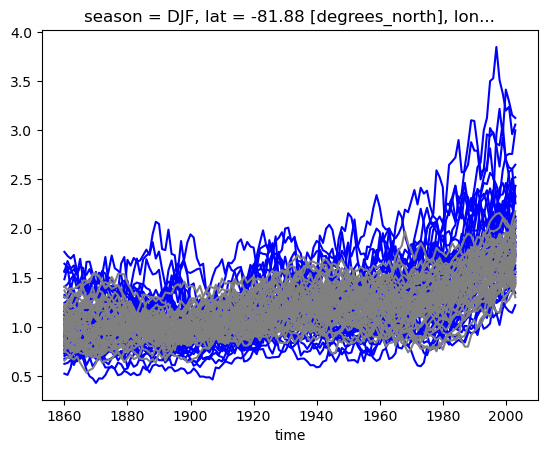

In [170]:
pr_doy.isel(season=0, lat=0, lon=0, quantile=0).plot(hue='member', add_legend=False, color='blue');
pr_hist.isel(season=0, lat=0, lon=0, quantile=0).plot(hue='member', add_legend=False, color='grey');

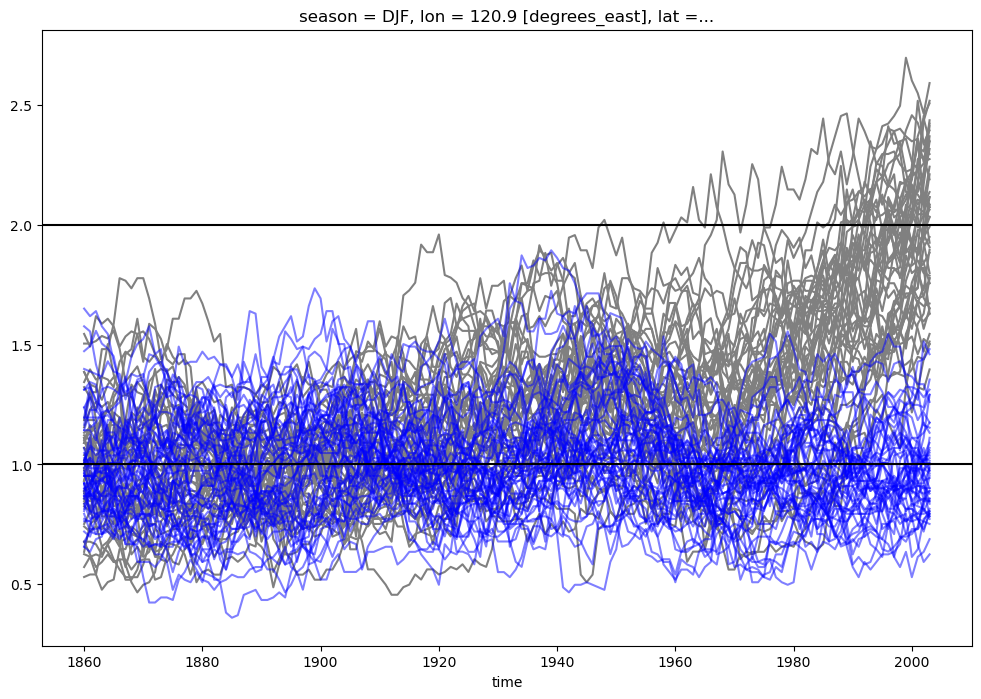

In [172]:
fig, ax = plt.subplots(figsize=(12, 8))
pr_hist.isel(lat=0, lon=0, quantile=1, season=0).plot(ax=ax,x='year', hue='member', add_legend=False, color='grey');
pr_histnat.isel(lat=0, lon=0, quantile=1, season=0).plot(ax=ax,x='year', hue='member', add_legend=False, color='blue', alpha=0.5);

ax.axhline(1, color='k')
ax.axhline(2, color='k')

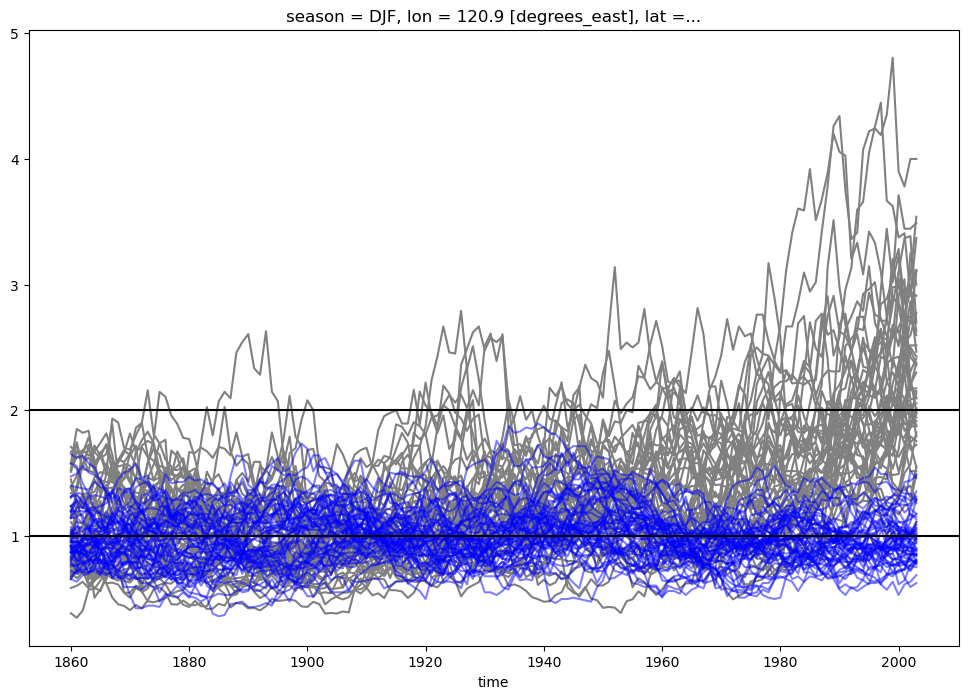

In [154]:
fig, ax = plt.subplots(figsize=(12, 8))
pr.isel(lat=0, lon=0, quantile=1, season=0).plot(ax=ax,x='year', hue='member', add_legend=False, color='grey');
pr_histnat.isel(lat=0, lon=0, quantile=1, season=0).plot(ax=ax,x='year', hue='member', add_legend=False, color='blue', alpha=0.5);

ax.axhline(1, color='k')
ax.axhline(2, color='k')

In [180]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def plot_quantile_panel(layers, ax, quantile, x, hlines):
    """Overlay every layer at one quantile on a single axes.

    Args:
        layers (list[dict]): Each has 'label', 'data', optional 'hue', and Line2D style
            kwargs. Drawn in order.
        ax (matplotlib.axes.Axes): Axes to draw into.
        quantile (float): Quantile to select from each layer.
        x (str): Coordinate name for the x axis.
        hlines (list[tuple[float, str]]): (y, colour) pairs drawn on the panel.
    """
    for layer in layers:
        style = {k: v for k, v in layer.items() if k not in ("data", "hue")}
        layer["data"].sel(quantile=quantile).plot(
            ax=ax, x=x, hue=layer.get("hue"), add_legend=False, **style
        )
    # for y, colour in hlines:
    #     ax.axhline(y, color=colour, lw=0.8)
    ax.set_xlabel("")
    ax.set_ylabel("")
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)


def plot_quantile_grid(layers, quantiles, x, hlines, xlims, ylabel, ncols=1):
    """Plot one panel per quantile in a grid, under a legend built from the layers.

    Args:
        layers (list[dict]): Series drawn on every panel, in order. See plot_quantile_panel.
        quantiles (np.ndarray): Quantile values, one panel each.
        x (str): Coordinate name for the x axis; also the figure x label.
        hlines (list[tuple[float, str]]): (y, colour) pairs drawn on every panel.
        xlims (tuple[float, float]): Shared x limits.
        ylabel (str): Figure-level y label.
        ncols (int): Number of grid columns.

    Returns:
        tuple[matplotlib.figure.Figure, np.ndarray]: Figure and the used axes.
    """
    n = quantiles.size
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(8 * ncols, 2.8 * nrows),
                             sharex=True, squeeze=False, layout="constrained")
    axes = axes.ravel()
    for ax in axes[n:]:
        fig.delaxes(ax)
    axes = axes[:n]

    for ax, q in zip(axes, quantiles):
        plot_quantile_panel(layers, ax, q, x, hlines)
        ax.set_title(f"{q*100:g}th Percentile")
        ax.set_xlim(xlims)
    for ax in axes[n - ncols:]:
        ax.tick_params(labelbottom=True)

    handles = [
        Line2D([], [], **{k: v for k, v in layer.items() if k not in ("data", "hue")})
        for layer in layers
    ]
    fig.supxlabel(x)
    fig.supylabel(ylabel)
    fig.legend(handles=handles, loc="outside upper center",
               ncols=len(handles), frameon=False)
    return fig, axes

In [181]:
p_histnat_doy

<xarray.Dataset> Size: 7MB
Dimensions:   (year: 165, season: 4, member: 49, lon: 2, lat: 2, quantile: 3)
Coordinates:
  * year      (year) int64 1kB 1850 1851 1852 1853 1854 ... 2011 2012 2013 2014
  * season    (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
  * member    (member) object 392B 'r10i1p1f3' 'r11i1p1f3' ... 'r54i1p1f3'
  * lon       (lon) float64 16B 120.9 122.8
  * lat       (lat) float64 16B -81.88 -80.62
  * quantile  (quantile) float64 24B 0.9 0.95 0.99
    height    float64 8B 1.5
Data variables:
    p         (member, lat, lon, quantile, year, season) float64 3MB nan ... nan
    total     (member, lat, lon, year, season) float64 1MB nan nan ... nan nan
    exceed    (member, lat, lon, quantile, year, season) float64 3MB nan ... nan
Attributes: (2)

In [199]:
p_hist_doy = p_hist_doy.rename({'quantile': 'quantile_clim'})

ValueError: cannot rename 'quantile' because it is not a variable or dimension in this dataset

In [218]:
p_histnat_doy = p_histnat_doy.rename({'quantile': 'quantile_clim'})

In [228]:
pairs = np.array([[0.0, 1.0], [0.05, 0.95], [0.25, 0.75]])
median = 0.5
quantiles = np.unique(np.concatenate([pairs.ravel(), [median]]))

p_hist_doy_exceed_bw = p_hist_doy.exceed.quantile(quantiles, dim="member").compute()
p_histnat_doy_exceed_bw = p_histnat_doy.exceed.quantile(quantiles, dim="member").compute()

/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


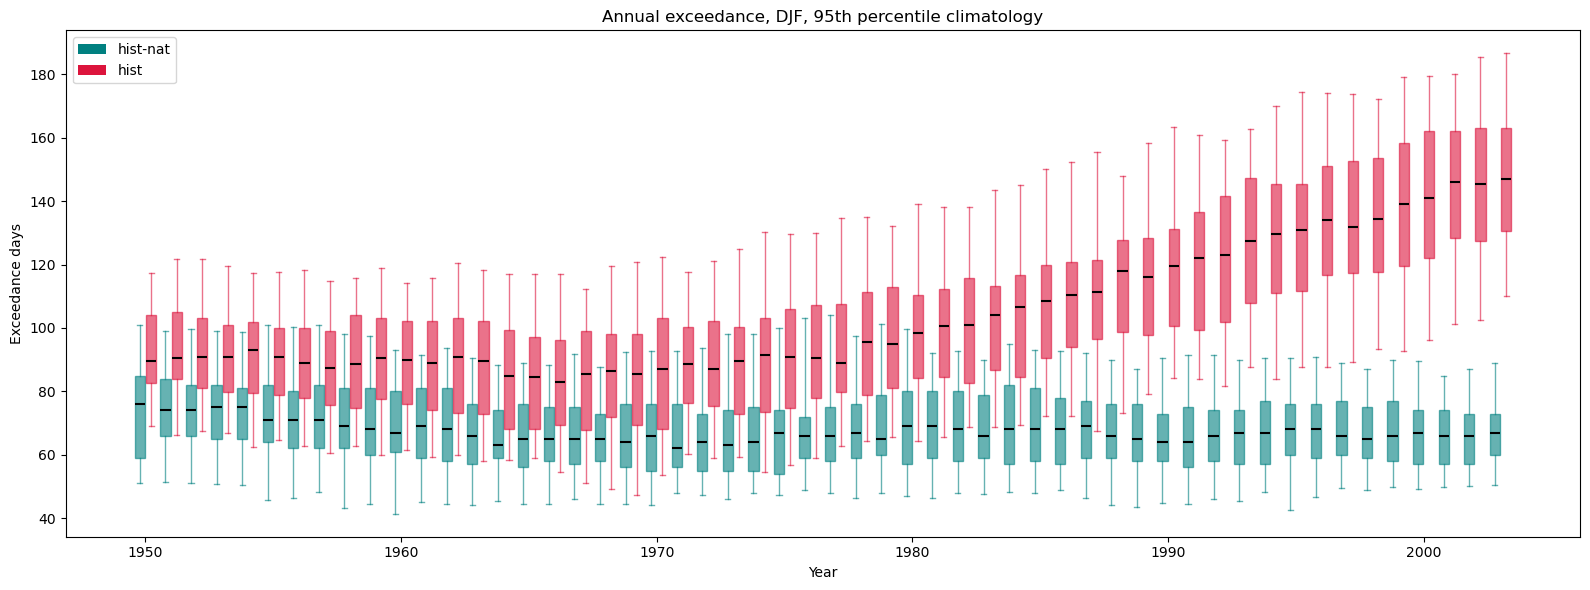

In [229]:
import matplotlib.pyplot as plt
import xarray as xr
from matplotlib.patches import Patch


def plot_boxes(da, ax, quantiles=(0.05, 0.25, 0.5, 0.75, 0.95), offset=0.0,
               width=0.8, color="teal", alpha=0.6):
    """Draw per-year boxes from pre-computed quantiles.

    Args:
        da (xr.DataArray): Dims ("year", "quantile").
        ax (plt.Axes): Axis to draw on.
        quantiles (tuple[float, ...]): Five ascending levels, taken in order as
            whislo, q1, med, q3, whishi.
        offset (float): Shift of box centres along the year axis.
        width (float): Box width in years.
        color (str): Box, whisker and cap colour.
        alpha (float): Box, whisker and cap opacity.

    Returns:
        dict: Artists returned by ax.bxp.
    """
    stats = da.sel(quantile=list(quantiles)).transpose("year", "quantile").values
    return ax.bxp(
        [dict(zip(("whislo", "q1", "med", "q3", "whishi"), row)) for row in stats],
        positions=da.year.values + offset,
        widths=width,
        manage_ticks=False,
        showfliers=False,
        patch_artist=True,
        boxprops=dict(facecolor=color, edgecolor=color, alpha=alpha),
        whiskerprops=dict(color=color, alpha=alpha),
        capprops=dict(color=color, alpha=alpha),
        medianprops=dict(color="black", linewidth=1.5),
    )


sel = dict(season="DJF", quantile_clim=0.95)
years = slice(1950, 2014)

hist    = p_hist_doy_exceed_bw.isel(lat=0, lon=0).sel(**sel).sel(year=years).dropna("year")
histnat = p_histnat_doy_exceed_bw.isel(lat=0, lon=0).sel(**sel).sel(year=years).dropna("year")

fig, ax = plt.subplots(figsize=(16, 6))
plot_boxes(histnat, ax, offset=-0.22, width=0.4, color="teal")
plot_boxes(hist,    ax, offset=+0.22, width=0.4, color="crimson")
ax.set_xlabel("Year")
ax.set_ylabel("Exceedance days")
ax.set_title("Annual exceedance, DJF, 95th percentile climatology")
ax.legend(handles=[Patch(facecolor="teal", label="hist-nat"),
                   Patch(facecolor="crimson", label="hist")])
plt.tight_layout()
plt.show()

In [243]:
def plot_plume(da, ax, pairs, median=0.5, color="teal", alphas=(0.15, 0.3),
               edge_widths=(0.0, 0.7), edge_styles=("-", "-"), edge_alpha=0.6,
               linestyle="-", linewidth=2.4, label=None):
    """Draw nested quantile bands and a median line against year.

    Args:
        da (xr.DataArray): Dims ("year", "quantile").
        ax (plt.Axes): Axis to draw on.
        pairs (tuple[tuple[float, float], ...]): (lower, upper) levels, outermost first.
        median (float): Quantile level drawn as a line.
        color (str): Band, edge and line colour.
        alphas (tuple[float, ...]): Band opacities, matched to pairs in order.
        edge_widths (tuple[float, ...]): Boundary line widths, matched to pairs in
            order; 0 draws no boundary.
        edge_styles (tuple[str, ...]): Boundary line styles, matched to pairs in order.
        edge_alpha (float): Boundary line opacity.
        linestyle (str): Median line style.
        linewidth (float): Median line width.
        label (str | None): Legend entry for the median line.

    Returns:
        list[plt.Line2D]: Artists returned by ax.plot for the median.
    """
    year = da.year.values
    for (lower, upper), alpha, lw, ls in zip(pairs, alphas, edge_widths, edge_styles):
        lo = da.sel(quantile=lower).values
        hi = da.sel(quantile=upper).values
        ax.fill_between(year, lo, hi, color=color, alpha=alpha, linewidth=0, zorder=1)
        if lw:
            ax.plot(year, lo, color=color, linewidth=lw, linestyle=ls,
                    alpha=edge_alpha, zorder=2)
            ax.plot(year, hi, color=color, linewidth=lw, linestyle=ls,
                    alpha=edge_alpha, zorder=2)
    return ax.plot(year, da.sel(quantile=median).values, color=color,
                   linewidth=linewidth, linestyle=linestyle, zorder=3, label=label)

def plot_difference(da, ax, colors=("crimson", "teal"), alpha=0.25):
    """Draw a signed difference series with sign-dependent shading.

    Args:
        da (xr.DataArray): Dim ("year",).
        ax (plt.Axes): Axis to draw on.
        colors (tuple[str, str]): Fill colours for positive and negative values.
        alpha (float): Fill opacity.

    Returns:
        list[plt.Line2D]: Artists returned by ax.plot.
    """
    year = da.year.values
    ax.axhline(0, color="0.6", linewidth=0.8)
    ax.fill_between(year, 0, da.values, where=da.values > 0,
                    color=colors[0], alpha=alpha, linewidth=0)
    ax.fill_between(year, 0, da.values, where=da.values < 0,
                    color=colors[1], alpha=alpha, linewidth=0)
    return ax.plot(year, da.values, color="0.3", linewidth=1.5)

In [241]:
def style_axis(ax):
    """Apply horizontal gridlines behind the data and drop top and right spines.

    Args:
        ax (plt.Axes): Axis to format.
    """
    ax.grid(axis="y", color="0.85", linewidth=0.6)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

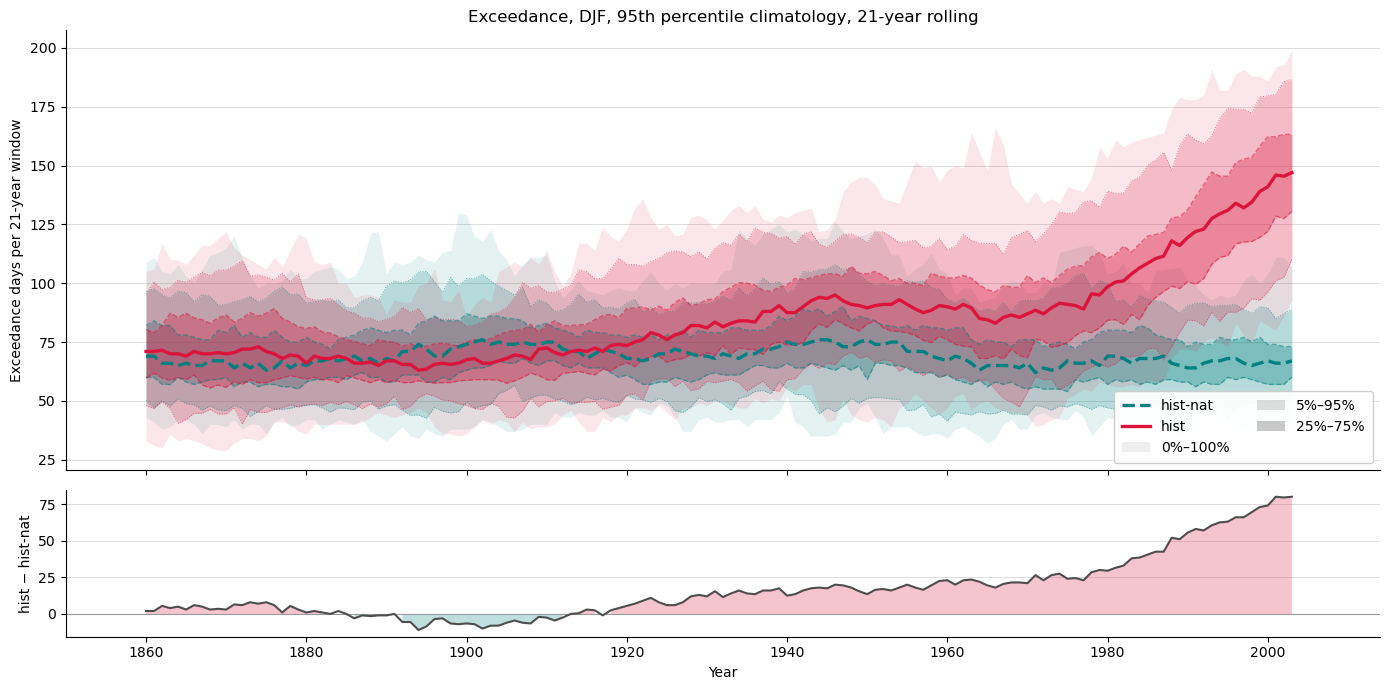

In [244]:
fig, (ax, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                              gridspec_kw=dict(height_ratios=[3, 1]))
band_alphas = (0.10, 0.20, 0.32)
edge_widths = (0.0, 0.7, 1.0)
edge_styles = (None, ":", "--")

lines  = plot_plume(histnat, ax, pairs, alphas=band_alphas, edge_widths=edge_widths,
                    edge_styles=edge_styles, edge_alpha=0.55,
                    color="teal", linestyle="--", label="hist-nat")
lines += plot_plume(hist,    ax, pairs, alphas=band_alphas, edge_widths=edge_widths,
                    edge_styles=edge_styles, edge_alpha=0.55,
                    color="crimson", label="hist")
bands = [Patch(facecolor="0.35", alpha=a, label=f"{lo:.0%}–{hi:.0%}")
         for (lo, hi), a in zip(pairs, band_alphas)]

style_axis(ax)
ax.set_xlim(hist.year.min(), hist.year.max())
ax.set_ylabel("Exceedance days per 21-year window")
ax.set_title("Exceedance, DJF, 95th percentile climatology, 21-year rolling")
ax.legend(handles=lines + bands, ncol=2, loc="lower right", framealpha=0.95, borderpad=0.6)

plot_difference(hist.sel(quantile=0.5) - histnat.sel(quantile=0.5), ax2)
style_axis(ax2)
ax2.set_ylabel("hist − hist-nat")
ax2.set_xlabel("Year")

plt.tight_layout()
plt.show()

In [ ]:
hist    = p_hist_doy_exceed_bw.isel(lat=0, lon=0).sel(**sel)
histnat = p_histnat_doy_exceed_bw.isel(lat=0, lon=0).sel(**sel)

fig, ax = plt.subplots(figsize=(14, 5))
plot_plume(histnat, ax, pairs[1:], color="teal", label="hist-nat")
plot_plume(hist,    ax, pairs[1:], color="crimson", label="hist")
ax.set_xlabel("Year")
ax.set_ylabel("Exceedance days")
ax.set_title("Annual exceedance, DJF, 95th percentile climatology")
ax.legend()
plt.tight_layout()
plt.show()

In [219]:
p_hist_doy_exceed_bw = p_hist_doy.exceed.quantile([0, 0.25, 0.5, 0.75, 1], dim='member').compute()
p_histnat_doy_exceed_bw = p_histnat_doy.exceed.quantile([0, 0.25, 0.5, 0.75, 1], dim='member').compute()

In [222]:
p_histnat_doy_exceed_bw

<xarray.DataArray 'exceed' (quantile: 5, lat: 2, lon: 2, quantile_clim: 3,
                            year: 165, season: 4)> Size: 317kB
nan nan nan nan nan nan nan nan nan nan ... nan nan nan nan nan nan nan nan nan
Coordinates:
  * year           (year) int64 1kB 1850 1851 1852 1853 ... 2011 2012 2013 2014
  * season         (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
  * lon            (lon) float64 16B 120.9 122.8
  * lat            (lat) float64 16B -81.88 -80.62
  * quantile_clim  (quantile_clim) float64 24B 0.9 0.95 0.99
  * quantile       (quantile) float64 40B 0.0 0.25 0.5 0.75 1.0

In [224]:
import matplotlib.pyplot as plt
import xarray as xr
from matplotlib.patches import Patch


def plot_boxes(da, ax, offset=0.0, width=0.8, color="teal", alpha=0.6):
    """Draw per-year boxes from pre-computed quantiles.

    Args:
        da (xr.DataArray): Dims ("year", "quantile") with five ascending quantile
            levels, taken in order as whislo, q1, med, q3, whishi.
        ax (plt.Axes): Axis to draw on.
        offset (float): Shift of box centres along the year axis.
        width (float): Box width in years.
        color (str): Box, whisker and cap colour.
        alpha (float): Box, whisker and cap opacity.

    Returns:
        dict: Artists returned by ax.bxp.
    """
    stats = da.transpose("year", "quantile").values
    return ax.bxp(
        [dict(zip(("whislo", "q1", "med", "q3", "whishi"), row)) for row in stats],
        positions=da.year.values + offset,
        widths=width,
        manage_ticks=False,
        showfliers=False,
        patch_artist=True,
        boxprops=dict(facecolor=color, edgecolor=color, alpha=alpha),
        whiskerprops=dict(color=color, alpha=alpha),
        capprops=dict(color=color, alpha=alpha),
        medianprops=dict(color="black", linewidth=1.5),
    )

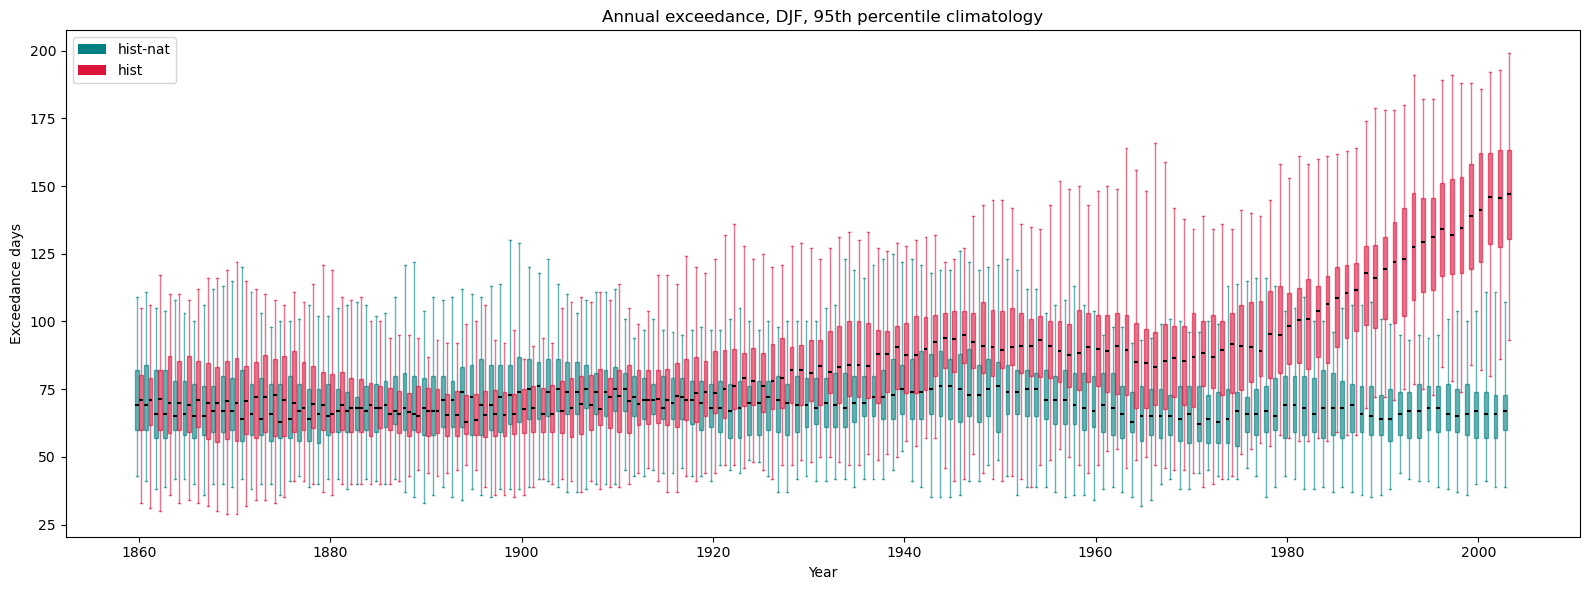

In [226]:
sel = dict(season="DJF", quantile_clim=0.95)
years = slice(None, 2014)

hist    = p_hist_doy_exceed_bw.isel(lat=0, lon=0).sel(**sel).sel(year=years).dropna("year")
histnat = p_histnat_doy_exceed_bw.isel(lat=0, lon=0).sel(**sel).sel(year=years).dropna("year")

fig, ax = plt.subplots(figsize=(16, 6))
plot_boxes(histnat, ax, offset=-0.22, width=0.4, color="teal")
plot_boxes(hist,    ax, offset=+0.22, width=0.4, color="crimson")
ax.set_xlabel("Year")
ax.set_ylabel("Exceedance days")
ax.set_title("Annual exceedance, DJF, 95th percentile climatology")
ax.legend(handles=[Patch(facecolor="teal", label="hist-nat"),
                   Patch(facecolor="crimson", label="hist")])
plt.tight_layout()
plt.show()

In [227]:
def plot_plume(da, ax, pairs, median=0.5, color="teal", alphas=(0.2, 0.4), label=None):
    """Draw nested quantile bands and a median line against year.

    Args:
        da (xr.DataArray): Dims ("year", "quantile").
        ax (plt.Axes): Axis to draw on.
        pairs (tuple[tuple[float, float], ...]): (lower, upper) quantile levels,
            outermost first.
        median (float): Quantile level drawn as a line.
        color (str): Band and line colour.
        alphas (tuple[float, ...]): Band opacities, matched to pairs in order.
        label (str | None): Legend entry for the median line.

    Returns:
        list[plt.Line2D]: Artists returned by ax.plot for the median.
    """
    year = da.year.values
    for (lower, upper), alpha in zip(pairs, alphas):
        ax.fill_between(year, da.sel(quantile=lower).values, da.sel(quantile=upper).values,
                        color=color, alpha=alpha, linewidth=0)
    return ax.plot(year, da.sel(quantile=median).values, color=color, linewidth=1.5, label=label)

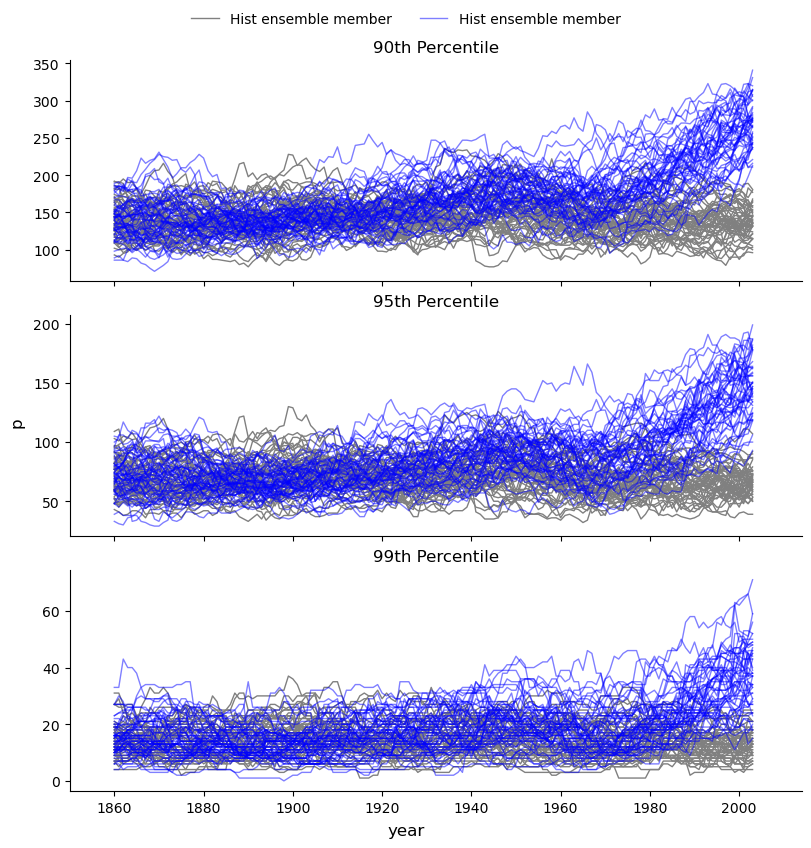

In [185]:
sel = dict(lat=0, lon=0, season=0)

layers = [
    dict(label="Hist ensemble member", data=p_histnat_doy.exceed.isel(**sel), hue="member", color="grey", lw=1),
    dict(label="Hist ensemble member", data=p_hist_doy.exceed.isel(**sel), hue="member", color="blue", lw=1, alpha=0.5),
    # dict(label="Yearly PR", data=pr_member_pool_1y.isel(**sel), color="k", lw=2, alpha=0.6),
]

fig, axes = plot_quantile_grid(
    layers, pr["quantile"].values, "year", [(1, "r"), (2, "r")],
    np.take(pr_member_pool_1y.year.values, [0, -1]), pr.name,
)

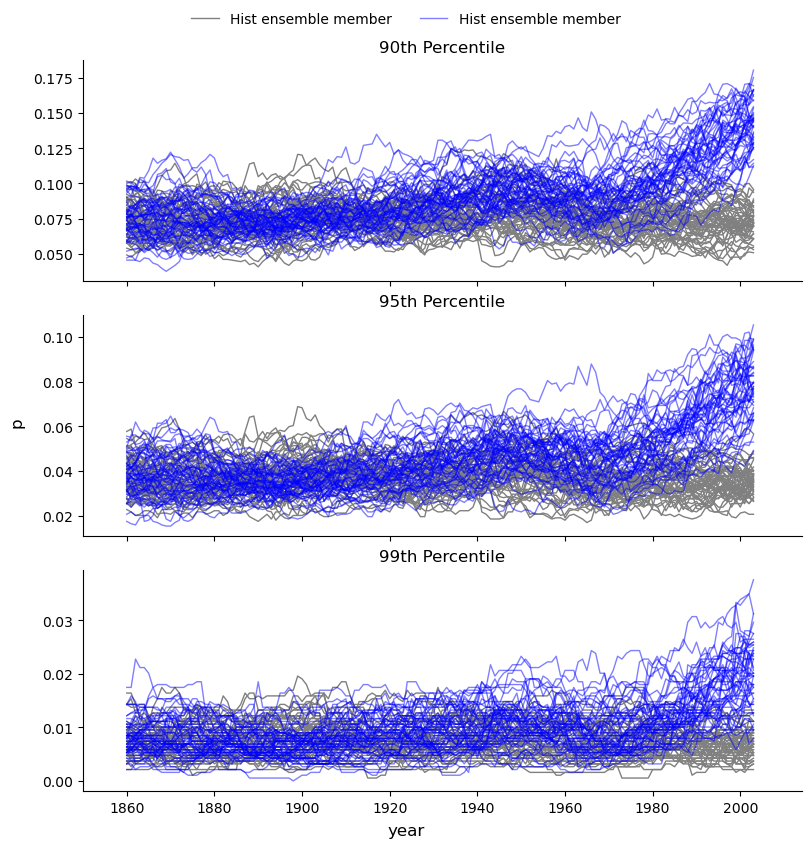

In [184]:
sel = dict(lat=0, lon=0, season=0)

layers = [
    dict(label="Hist ensemble member", data=p_histnat_doy.p.isel(**sel), hue="member", color="grey", lw=1),
    dict(label="Hist ensemble member", data=p_hist_doy.p.isel(**sel), hue="member", color="blue", lw=1, alpha=0.5),
    # dict(label="Yearly PR", data=pr_member_pool_1y.isel(**sel), color="k", lw=2, alpha=0.6),
]

fig, axes = plot_quantile_grid(
    layers, pr["quantile"].values, "year", [(1, "r"), (2, "r")],
    np.take(pr_member_pool_1y.year.values, [0, -1]), pr.name,
)sel = dict(lat=0, lon=0, season=0)

layers = [
    dict(label="Hist ensemble member", data=p_histnat_doy.p.isel(**sel), hue="member", color="grey", lw=1),
    dict(label="Hist ensemble member", data=p_hist_doy.p.isel(**sel), hue="member", color="blue", lw=1, alpha=0.5),
    # dict(label="Yearly PR", data=pr_member_pool_1y.isel(**sel), color="k", lw=2, alpha=0.6),
]

fig, axes = plot_quantile_grid(
    layers, pr["quantile"].values, "year", [(1, "r"), (2, "r")],
    np.take(pr_member_pool_1y.year.values, [0, -1]), pr.name,
)

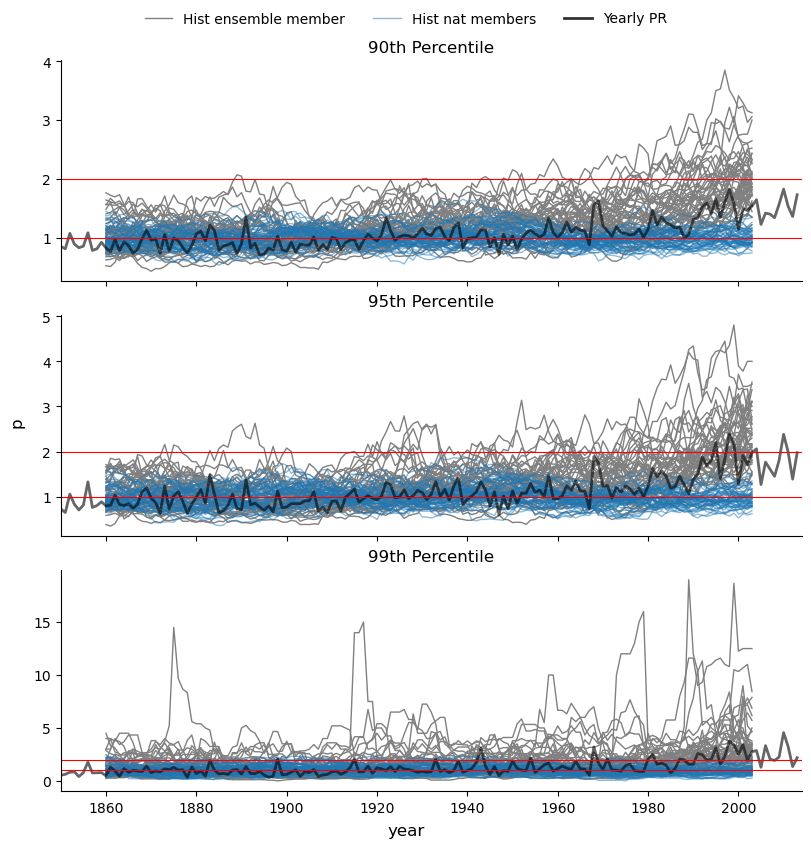

In [124]:
sel = dict(lat=0, lon=0, season=0)
quantiles = pr["quantile"].values
n = quantiles.size
ncols = 1#int(np.ceil(np.sqrt(n)))
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(8 * ncols, 2.8 * nrows),
    sharex=True,
    squeeze=False,
    layout="constrained",
)
axes = axes.ravel()


xlims = np.take(pr_member_pool_1y.year.values, [0, -1])

for ax in axes[n:]:
    fig.delaxes(ax)

for ax, q in zip(axes, quantiles):
    pr.isel(**sel).sel(quantile=q).plot(
        ax=ax, x="year", hue="member", add_legend=False, color="grey", lw=1
    )
    pr_histnat.isel(**sel).sel(quantile=q).plot(
        ax=ax, x="year", hue="member", add_legend=False, color="tab:blue", alpha=0.5, lw=1
    )

    pr_member_pool_1y.isel(**sel).sel(quantile=q).plot(ax=ax, color='k', linewidth=2, alpha=0.6);
    
    ax.axhline(1, color="r", lw=0.8)
    ax.axhline(2, color="r", lw=0.8)
    ax.set_title(f"{q*100:g}th Percentile")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xlim(xlims)
    [ax.spines[spine].set_visible(False) for spine in ["top", "right"]]

for ax in axes[n - ncols:n]:
    ax.tick_params(labelbottom=True)

fig.supxlabel("year")
fig.supylabel(pr.name)

handles = [
    Line2D([], [], color="grey", lw=1, label="Hist ensemble member"),
    Line2D([], [], color="tab:blue", lw=1, alpha=0.5, label="Hist nat members"),
    Line2D([], [], color="k", lw=2, alpha=0.8, label="Yearly PR"),
]
fig.legend(handles=handles, loc="outside upper center", ncols=3, frameon=False)

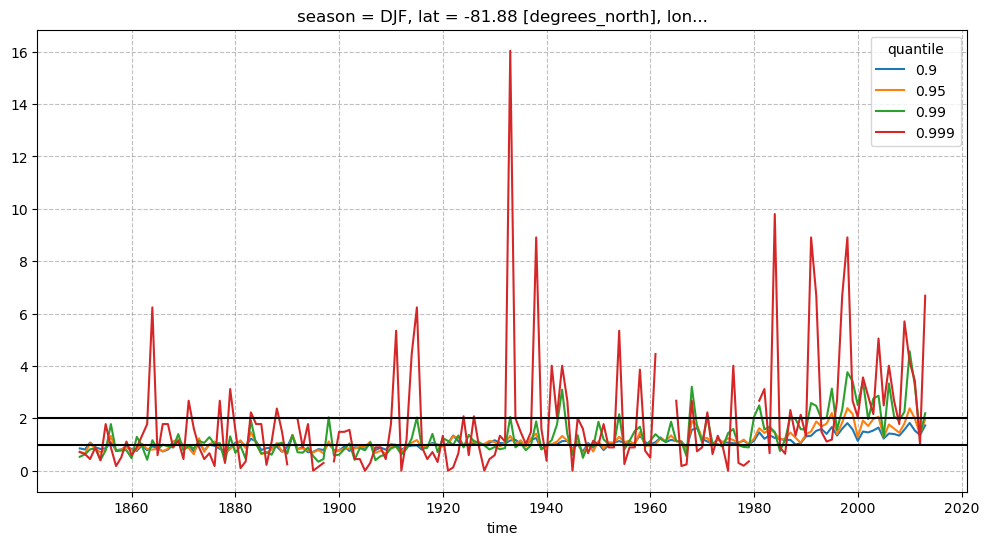

In [125]:
fig, ax = plt.subplots(figsize=(12, 6))
pr_member_pool_1y.isel(lat=0, lon=0, season=0).plot(ax=ax, x='year', hue='quantile');
ax.grid(True, linestyle="--", color='grey', alpha=0.5)
ax.axhline(1, color='k')
ax.axhline(2, color='k')

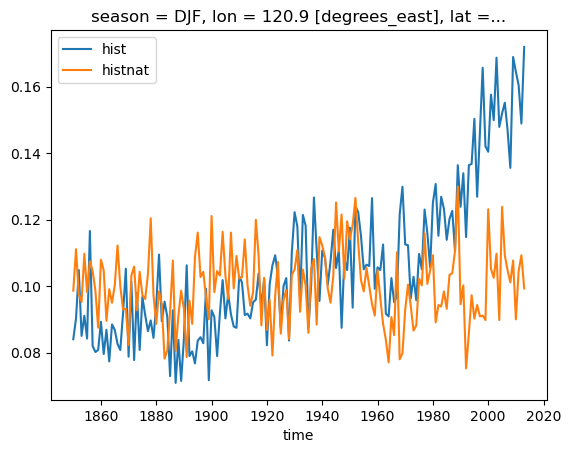

In [126]:
#| title: The probability of this hist nat and this hist simulations
#| caption: this is for a single ensemble member
p_member_pool_1y.isel(lat=0, lon=0, season=0, quantile=0).plot(label='hist')
p_histnat_member_pool_1y.isel(lat=0, lon=0, season=0, quantile=0).plot(label='histnat')
plt.legend()

<b> Interpration </b>
<br>
The probability diverge substantially between the histnat and the hist. As such, there are changes in daily tasman than can be attributed to anthropogenic climate change.~

In [127]:
seasonal = hist_ensemble_ds.isel(lat=0, lon=0).resample(time="QS-DEC").max()

seasonal = (
    seasonal
    .assign_coords(year=seasonal.time.dt.year, season=seasonal.time.dt.season)
    .set_index(time=("year", "season"))
    .unstack("time")
)

Text(0.5, 1.0, 'Hist-nat')

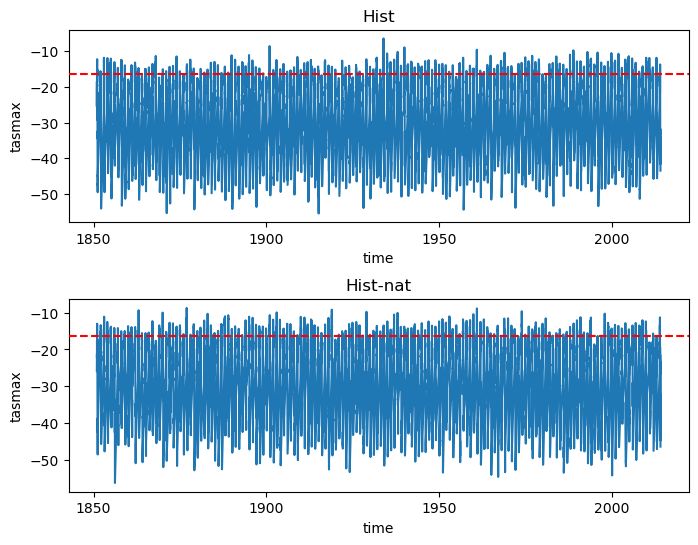

In [128]:
#| title: Timeseries of tasmax data with percentiles plotted
#| caption: Trends are not detectable in the singly daily profiles

fig = plt.figure(figsize=(8, 6))
gs = GridSpec(2, 1, hspace=0.4)
ax, ax2 = [fig.add_subplot(gs[i]) for i in range(2)]


ax.axhline(q_histnat.isel(selection_kwargs).values.item(), color='red', linestyle='--', zorder=10)
hist_ensemble_ds.sel(time=hist_ensemble_ds['time.month'].isin([12, 1, 2])).isel(member=0, lat=0, lon=0).plot(ax=ax)
ax.set_title("Hist")

ax2.axhline(q_histnat.isel(selection_kwargs).values.item(), color='red', linestyle='--', zorder=10)
histnat_ensemble_ds.sel(time=histnat_ensemble_ds['time.month'].isin([12, 1, 2])).isel(member=0, lat=0, lon=0).plot(ax=ax2)
ax2.set_title("Hist-nat")

Text(0.5, 1.0, 'Seasonal max vs daily')

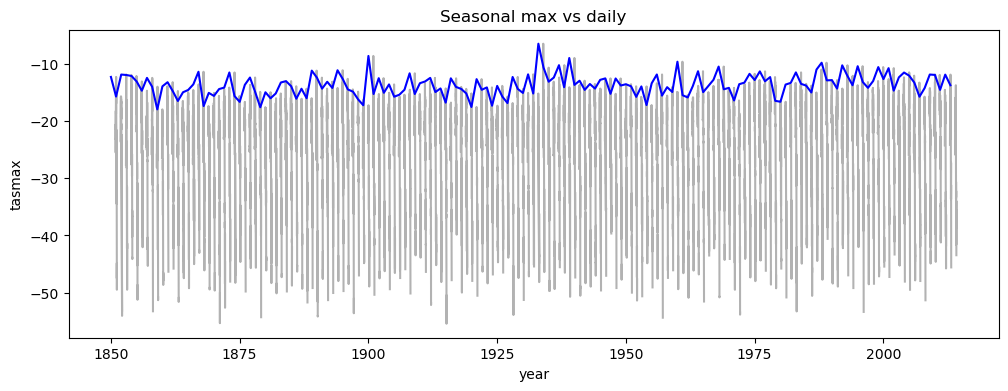

In [129]:
#| title: Seasonal vs daily data
#Z caption: Trends are much more detectable looking at the seasonal maximum
fig, ax = plt.subplots(figsize=(12, 4))

daily = hist_ensemble_ds.isel(member=0, lat=0, lon=0)
daily = daily.where(daily['time.month'].isin([12, 1, 2]))
daily = daily.assign_coords(
    year_frac=daily['time.year'] + (daily['time.dayofyear'] - 1) / 360
)

daily.plot(x='year_frac', ax=ax, color='grey', alpha=0.6)
seasonal.isel(season=0, member=0).plot(add_legend=False, color='blue', ax=ax)
ax.set_xlabel('year')

ax.set_title("Seasonal max vs daily")

## Defunct

In [26]:
# def rolling_quantile_exceedance(da, q_da, resample_freq='QS-DEC', year_window: int = 20) -> xr.Dataset:
#     """Rolling exceedance rate relative to a seasonal quantile threshold.

#     Counts timesteps in each resampled season that exceed the matching seasonal
#     threshold, then accumulates those counts (and the number of valid timesteps)
#     over a centred rolling window to give an exceedance probability.

#     Args:
#         da (xr.DataArray): Input data with a 'time' coordinate.
#         q_da (xr.DataArray): Thresholds with a 'season' dim, broadcast against the seasonal groups of `da`.
#         resample_freq (str): Frequency used to bin timesteps into seasons.
#         year_window (int): Width of the centred rolling window, in years.

#     Returns:
#         xr.Dataset: 'pr' (exceedance probability), 'exceed' and 'total' (rolling counts).
#             `resample_freq` and `year_window` are recorded in the attrs.
#     """
#     # per-season counts of exceedances and of valid timesteps
#     n_exceed_da = (da.groupby('time.season') > q_da).resample(time=resample_freq).sum()
#     n_total_da = da.resample(time=resample_freq).count()

#     # move onto a (year, season) index, then accumulate over the centred window
#     roll_exceed_da = year_season(n_exceed_da).rolling(year=year_window, center=True).sum()
#     roll_total_da = year_season(n_total_da).rolling(year=year_window, center=True).sum()

#     # fraction of timesteps in the window above the threshold
#     p_da = roll_exceed_da / roll_total_da

#     roll_exceed_da.name = 'exceed'
#     roll_total_da.name = 'total'
#     p_da.name = 'p'

#     ds = xr.merge([p_da, roll_total_da, roll_exceed_da])
#     ds.attrs['resample_freq'] = resample_freq
#     ds.attrs['year_window'] = year_window
#     return ds

In [50]:
#| title: histnat probability
#| caption: the probbability each season of being above the percentiles for the histnat.
# This should be equal to 1-q. E.g. the probability of being above the 90th percenile should be 10%
# This is called total, as there is a single value for this histnat instead of rolling values
# p_histnat_total = (
#     (histnat_ensemble_ds.groupby('time.season') > q_histnat).groupby('time.season').sum()
#     / histnat_ensemble_ds.groupby('time.season').count()
# )

In [ ]:
#| title: Probability Ratios of the historical but using a 1 year window
# p_hist_1y = rolling_quantile_exceedance(hist_ensemble_ds, q_histnat, year_window=1)
# pr_1y = p_hist_1y.p/p_histnat_total

In [37]:
# tda2 = histnat_ensemble_ds.isel(lat=0, lon=0, member=0)
# tda2 = tda2.sel(time=tda2.time.dt.dayofyear==5)
# qdoy = q_histnat_doy.isel(quantile=0, member=0, lat=0, lon=0).sel(dayofyear=5).values.item()
# print(above_count, len(tda2.values), above_count/len(tda2.values))
# np.nanpercentile(tda2.values, 90), qdoy
# fig, ax = plt.subplots()
# tda2.plot()
# ax.axhline(qdoy, color='orange')#
# above_count = np.sum(tda2.values >= qdoy).item()


In [45]:
#| title: Calculating the probability in the histnat. 
# p_histnat_rolling = rolling_quantile_exceedance(histnat_ensemble_ds, q_histnat)
# pr_histnat = p_histnat_rolling.p/p_histnat_total
# pr_histnat = pr_histnat.compute()

In [38]:
# count_above = (histnat_ensemble_ds.groupby('time.dayofyear') > q_histnat_doy).groupby('time.season').sum().persist()
# wait(count_above);

In [39]:
# count = histnat_ensemble_ds.groupby('time.season').count()
# wait(count);

In [40]:
#| title: histnat probability
#| caption: the probbability each season of being above the percentiles for the histnat.
# This should be equal to 1-q. E.g. the probability of being above the 90th percenile should be 10%
# This is called total, as there is a single value for this histnat instead of rolling values
# p_histnat_total = (
#     (histnat_ensemble_ds.groupby('time.season') > q_histnat).groupby('time.season').sum()
#     / histnat_ensemble_ds.groupby('time.season').count()
# )

In [41]:
# windowed = ds.rolling(time=window_size, center=True).construct("window")
# windowed = windowed.chunk({"time": -1})

# window_q = windowed.groupby("time.dayofyear").quantile(q, dim=["time", "window"])

In [42]:
# window_q = window_q.compute()

# Rank Histograms

Using the method from Suarez‑Gutierrez et al., 2021 that uses rank histograms to analyse if both the signal and the nosie are correct in the model. This can get you if the forced resonse is under or overestimated, and if the variable is under or overestimated

Method
1. Convert to seasonal mean.
2. Convert to anomalies: subtract the mean of all data
3. Rank the data per time step against the ensemble members
4. Do the same for each ensemble member against all the other members
5. Calculate the 5th and 95th percentiles for each bin from the ensemble member ranks
6. Compare the rank histogram for the observations against the 5th and 9th percentiles

<b> Dataset information </b>
<br>
The time ranges from 1979 to 2014. This is not many data points. As such I have used the monthly mean, using Dec, Jan and Feb to increase sample sizes.

In [ ]:
xr.set_options(display_expand_data=False, display_expand_attrs=False, display_expand_data_vars=False)

In [ ]:
# era5_loc_seasonal = era5_loc.resample(time='QS-DEC').mean()
era5_loc_seasonal = era5_loc.resample(time='ME').mean()
# era5_loc_seasonal = era5_loc_seasonal.sel(time=era5_loc_seasonal['time.month']==12).isel(time=slice(1, -1))
era5_loc_seasonal = era5_loc_seasonal.where(era5_loc_seasonal.time.dt.month.isin([12, 1, 2]), drop=True).isel(time=slice(1, -1))

In [ ]:
hist_ensemble_seasonal_ds = hist_ensemble_ds.resample(time='ME').mean().compute()
# hist_ensemble_seasonal_ds = hist_ensemble_seasonal_ds.sel(time=hist_ensemble_seasonal_ds['time.month']==12).isel(time=slice(1, -1))
hist_ensemble_seasonal_ds = hist_ensemble_seasonal_ds.where(hist_ensemble_seasonal_ds.time.dt.month.isin([12, 1, 2]), drop=True).isel(time=slice(1, -1))

In [ ]:
era5_loc_seasonal_anom = era5_loc_seasonal - era5_loc_seasonal.mean(dim='time')
hist_ensemble_seasonal_anom = hist_ensemble_seasonal_ds - hist_ensemble_seasonal_ds.mean(dim='time')

In [ ]:
# hist_ensemble_seasonal_anom.isel(lat=0, lon=0).min(dim='member').plot(color='blue', label='ensemble min')
# hist_ensemble_seasonal_anom.isel(lat=0, lon=0).max(dim='member').plot(color='red', label='ensemble max')
# era5_loc_seasonal_anom.plot(color='k', label='ERA5')
# plt.legend()

In [ ]:
era5_rank_ds = (hist_ensemble_seasonal_anom.isel(lat=0, lon=0) < era5_loc_seasonal_anom).sum(dim='member')

In [ ]:
# Ranks of ERA5
# era5_rank_ds.plot()

In [ ]:
ensemble_memebers = hist_ensemble_seasonal_anom.member.values
member_pseudo_ranks = []
for member in ensemble_memebers:
    other_members = [m for m in ensemble_memebers if m != member]
    other_members_ds = hist_ensemble_seasonal_anom.sel(member=other_members)
    one_member_ds = hist_ensemble_seasonal_anom.sel(member=member)
    member_rank = (other_members_ds<one_member_ds).sum(dim='member')
    member_rank  = member_rank.assign_coords(member=member)
    member_pseudo_ranks.append(member_rank)
    
member_pseudo_ranks_ds = xr.concat(member_pseudo_ranks, dim='member')

In [ ]:
member_pseudo_ranks_ds

In [ ]:
from xhistogram.xarray import histogram

In [ ]:
bins = np.arange(0, 55)

In [ ]:
era5_rank_hist = histogram(era5_rank_ds, bins=bins)

In [ ]:
pseudo_histogram = histogram(member_pseudo_ranks_ds, bins=bins, dim=['time'])
pseudo_histogram_lower_upper = pseudo_histogram.quantile([0.05, 0.95], dim='member')

In [ ]:
pseudo_histogram

In [ ]:
fig = plt.figure(figsize=(8, 6))
lower = pseudo_histogram_lower_upper.isel(lat=0, lon=0, quantile=0)
upper = pseudo_histogram_lower_upper.isel(lat=0, lon=0, quantile=1)

plt.bar(era5_rank_hist.tasmax_bin, era5_rank_hist, width=1.0, label='ERA5', color='blue')
plt.plot(lower.tasmax_bin, lower, alpha=0.9, color="k")
plt.plot(lower.tasmax_bin, upper, alpha=0.9, color="k")

plt.legend()

<b> Interpretation </b>
<br>
This looks like the model underestimates the forced resonse as the ranks are all low.

<img src="suarez.PNG" width=500 />

# Trends and S/N Ratio

## Functions

<b> Infomation </b>

- Trends are for Austral Spring 2000 to 2024
- Seasonal maximum of TAS

<b> Signal-to-noise ratio calculation </b>
- Signal here (S) is change in temperature estimated using a linear trend fit: gradeint x number of years
- Noise (N) is the standard deviation of the data after removing the linear trend
- S/N = S/N

In [ ]:
from matplotlib.gridspec import GridSpec

In [ ]:
def grid_slope(da, dim='time'):
    """Per-cell OLS slope of y = a + b*x.

    Closed-form normal-equation solution:

        b   = Sxy / Sxx
        Sxx = sum((x - xbar)^2)          spread of the time axis
        Sxy = sum((x - xbar)(y - ybar))  covariation of y with time

    Vectorised over all non-`dim` dimensions, so no per-cell loop.
    Time is converted to float years, since cftime objects don't support
    the arithmetic. Assumes one value per year — sub-annual data collapses
    Sxx, as every point within a year shares the same x.

    Parameters
    ----------
    da : xr.DataArray
        Input with cftime/datetime `dim`; other dims treated as cells.
    dim : str
        Dimension to regress along.

    Returns
    -------
    xr.DataArray
        Slope of the data.
    """
    x = xr.DataArray(np.arange(da.sizes[dim], dtype=float), dims=dim)

    dx = x - x.mean(dim)
    slope = (dx * (da - da.mean(dim))).sum(dim) / (dx ** 2).sum(dim)
    # slope.attrs['units'] = f"{da.attrs.get('units', '')} yr-1".strip()
    return slope

In [ ]:
import numpy as np
import xarray as xr
from scipy.stats import norm


def mk_S(y, i, j):
    """Mann-Kendall S statistic along the last axis.

    S = sum_{k<l} sign(y_l - y_k), as a broadcast pairwise difference
    over precomputed upper-triangle index pairs.

    Parameters
    ----------
    y : np.ndarray
        Shape (..., n); leading axes treated as independent cells.
    i, j : np.ndarray
        Upper-triangle index pairs from np.triu_indices(n, k=1).

    Returns
    -------
    np.ndarray
        S with shape y.shape[:-1].
    """
    return np.sign(y[..., j] - y[..., i]).sum(axis=-1)


def grid_mk(da, dim='time', alpha=0.05):
    """Per-cell Mann-Kendall test, lazy over dask.

        Var(S) = n(n-1)(2n+5) / 18          no-ties form
        Z      = (S -/+ 1) / sqrt(Var)      continuity-corrected, 0 if S = 0
        p      = 2 * P(N(0,1) > |Z|)

    apply_ufunc moves `dim` to the last axis, which is what mk_S expects.

    Parameters
    ----------
    da : xr.DataArray
        Input; `dim` is the time axis, other dims treated as cells.
    dim : str
        Dimension to test along.
    alpha : float
        Threshold for the significance mask.

    Returns
    -------
    xr.Dataset
        S, Z, p (two-sided), sig (bool, p < alpha).
    """
    n = da.sizes[dim]
    i, j = np.triu_indices(n, k=1)
    var = n * (n - 1) * (2 * n + 5) / 18.0

    S = xr.apply_ufunc(
        lambda y: mk_S(y, i, j),
        da,
        input_core_dims=[[dim]],
        dask='parallelized', output_dtypes=[float]
        )

    Z = xr.where(S > 0, (S - 1) / np.sqrt(var),
        xr.where(S < 0, (S + 1) / np.sqrt(var), 0.0))
    p = xr.apply_ufunc(lambda z: 2 * norm.sf(np.abs(z)), Z,
                       dask='parallelized', output_dtypes=[float])

    return xr.Dataset({'S': S, 'Z': Z, 'p': p, 'sig': p < alpha})

In [ ]:
def grid_intercept(da, slope, dim='time'):
    """Per-cell OLS intercept of y = a + b*x, given b.

        a = ybar - b * xbar

    Uses the same x as `grid_slope`: 0, 1, ..., n-1 along `dim`. The
    intercept is therefore the fitted value at the *first* time step,
    not at any calendar epoch.

    Parameters
    ----------
    da : xr.DataArray
        Input with cftime/datetime `dim`; other dims treated as cells.
    slope : xr.DataArray
        Slope from `grid_slope(da, dim)`, broadcastable against `da`
        over the non-`dim` dims.
    dim : str
        Dimension the regression was taken along.

    Returns
    -------
    xr.DataArray
        Intercept of the data.
    """
    x = xr.DataArray(np.arange(da.sizes[dim], dtype=float), dims=dim)
    return da.mean(dim) - slope * x.mean(dim)

## Calculations

In [ ]:
era5_da

In [ ]:
era5_seasonal_da = era5_da.resample(time='QS-DEC').max().persist()
wait(era5_seasonal_da);

In [ ]:
era5_seasonal_da

In [ ]:
era5_spring_da = era5_seasonal_da.sel(time=era5_seasonal_da['time.month']==9)
era5_spring_g2000_da = era5_spring_da.sel(time=era5_spring_da['time.year'] > 2000)

era5_spring_slope_g2000_da = grid_slope(era5_spring_g2000_da).compute()
era5_spring_yint_g2000_da = grid_intercept(era5_spring_g2000_da, era5_spring_slope_g2000_da).compute()

era5_spring_trend_g2000_da = era5_spring_slope_g2000_da * xr.DataArray(
    np.arange(era5_spring_g2000_da['time'].shape[0], dtype=float), dims='time') + era5_spring_yint_g2000_da
era5_spring_trend_g2000_da['time'] = era5_spring_g2000_da.time.values

era5_spring_g2000_da_detrend = era5_spring_g2000_da - era5_spring_trend_g2000_da

era5_spring_g2000_noise_da = era5_spring_g2000_da_detrend.std(dim='time').compute();

era5_spring_g2000_signal_da = era5_spring_slope_g2000_da * xr.DataArray((np.arange(era5_spring_g2000_da.sizes['time'], dtype=float)), dims='time',coords={'time': era5_spring_g2000_da.time})

era5_spring_g2000_sn_da = era5_spring_g2000_signal_da/era5_spring_g2000_noise_da
era5_spring_g2000_sn_da = era5_spring_g2000_sn_da.compute()

era5_spring_g2000_sn_da

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1)
era5_spring_trend_g2000_da.isel(lat=0, lon=0).plot(ax=ax1)
era5_spring_g2000_da.isel(lat=0, lon=0).plot(ax=ax1)
era5_spring_g2000_da_detrend.isel(lat=0, lon=0).plot(ax=ax2)
era5_spring_g2000_sn_da.isel(lat=0, lon=0).plot(ax=ax3)

## Plotting

In [ ]:
model

In [ ]:
import numpy as np
import matplotlib as mpl
import matplotlib.colors as mcolors
import matplotlib.path as mpath


def truncate_cmap(name, lo=0.0, hi=1.0, n=256):
    base = mpl.colormaps[name]
    return mcolors.LinearSegmentedColormap.from_list(
        f'{name}_{lo}_{hi}', base(np.linspace(lo, hi, n)))


SIG_CMAP = truncate_cmap('RdBu_r', 0.08, 0.92)
NOISE_CMAP = truncate_cmap('YlOrBr', 0.05, 0.95)

# 9 bins: 4 negative (blue), 1 central "below noise" (grey), 4 positive (yellow->red)
SN_LEVELS = [-5, -3, -2, -1.5, -1, 0, 1, 1.5, 2, 3, 5]
SN_TICKS = [-5, -3, -2, -1, 0, 1, 2, 3, 5]
SN_CMAP = mcolors.ListedColormap(
    ['#08519c', '#3182bd', '#6baed6', '#bdd7e7',
     '#e8eef2', '#f9efe2',
     '#fed976', '#fd8d3c', '#e31a1c', '#99000d'])
SN_CMAP.set_under('#08306b')
SN_CMAP.set_over('#54001a')
SN_NORM = mcolors.BoundaryNorm(SN_LEVELS, SN_CMAP.N)

UNIVERSAL_PLOT_KWARGS = dict(transform=ccrs.PlateCarree(), add_labels=False,
                             add_colorbar=False)

# --- figure and axes (explicit positions, figure coordinates) ---
fig = plt.figure(figsize=(8, 9.5))

MAP_W = 0.40
MAP_H = MAP_W * 8 / 9.5   # square in inches

ax_a = fig.add_axes([0.06, 0.585, MAP_W, MAP_H], projection=ccrs.SouthPolarStereo())
ax_b = fig.add_axes([0.54, 0.585, MAP_W, MAP_H], projection=ccrs.SouthPolarStereo())
ax_c = fig.add_axes([0.30, 0.115, MAP_W, MAP_H], projection=ccrs.SouthPolarStereo())

cax_a = fig.add_axes([0.10, 0.545, 0.32, 0.016])
cax_b = fig.add_axes([0.58, 0.545, 0.32, 0.016])
cax_c = fig.add_axes([0.28, 0.075, 0.44, 0.018])

# --- data ---
p_a = era5_spring_g2000_signal_da.isel(time=-1).plot(
    ax=ax_a, robust=True, cmap=SIG_CMAP, **UNIVERSAL_PLOT_KWARGS)
p_b = era5_spring_g2000_noise_da.plot(
    ax=ax_b, robust=True, levels=7, cmap=NOISE_CMAP, extend='max',
    **UNIVERSAL_PLOT_KWARGS)
p_c = era5_spring_g2000_sn_da.isel(time=-1).plot(
    ax=ax_c, cmap=SN_CMAP, norm=SN_NORM, **UNIVERSAL_PLOT_KWARGS)

era5_spring_g2000_sn_da.isel(time=-1).plot.contour(
    ax=ax_c, levels=[-2, 2], colors='k', linewidths=0.7, add_labels=False,
    transform=ccrs.PlateCarree())

# --- colorbars ---
cb_a = fig.colorbar(p_a, cax=cax_a, orientation='horizontal', label='Signal')
cb_b = fig.colorbar(p_b, cax=cax_b, orientation='horizontal', label='Noise')
cb_c = fig.colorbar(p_c, cax=cax_c, orientation='horizontal', label='S/N ratio',
                    extend='both', ticks=SN_TICKS, spacing='uniform')

for cb in (cb_a, cb_b, cb_c):
    cb.outline.set_linewidth(0.5)
    cb.ax.tick_params(labelsize=9, length=2, width=0.5, pad=2)
    cb.ax.xaxis.label.set_size(10)

cb_c.ax.tick_params(labelsize=8)
cb_c.dividers.set_color('white')
cb_c.dividers.set_linewidth(0.8)

# --- map furniture ---
theta = np.linspace(0, 2 * np.pi, 200)
circle = mpath.Path(np.column_stack([np.sin(theta), np.cos(theta)]) * 0.5 + 0.5)

for ax in (ax_a, ax_b, ax_c):
    ax.set_extent([-180, 180, -90, -55], crs=ccrs.PlateCarree())
    ax.set_boundary(circle, transform=ax.transAxes)
    ax.coastlines(linewidth=0.6, color='0.25')
    ax.gridlines(linewidth=0.4, color='0.6', alpha=0.5, linestyle=':')

ax_a.set_title('(a) Signal', loc='left', fontsize=11)
ax_b.set_title('(b) Noise', loc='left', fontsize=11)
ax_c.set_title('(c) Signal-to-noise ratio', loc='left', fontsize=11)

fig.suptitle('ERA5 spring (SON) maximum SAT, 2000 onwards', fontsize=14, fontweight='bold', y=0.975)

In [ ]:
# era5_spring_slope_da = grid_slope(era5_seasonal_da).compute()

In [ ]:
def max_locations(ds, number:int=10, ascending=True) -> list:
    ds = ds.stack(latlon=['lat', 'lon'])
    ds = ds.sortby(ds, ascending=ascending)
    latlon_largest = ds.isel(latlon=slice(0, number)).latlon.values
    latlon_largest_formatted = [{'lat': latlon[0], 'lon': latlon[1]} for latlon in latlon_largest]
    return  latlon_largest_formatted

In [ ]:
latlon_largest_era5_seasonal = max_locations(era5_spring_slope_g2000_da, ascending=False)
latlon_largest_era5_seasonal

In [ ]:
latlon_largest_era5_seasonal_sn = max_locations(era5_spring_g2000_sn_da.isel(time=-1), ascending=False)
latlon_largest_era5_seasonal_sn

In [ ]:
import matplotlib.pyplot as plt


def make_axes(fig, npanels, layout="col", height_ratios=(5, 1)):
    axes, tab_axes = [], []
    if layout == "col":
        gs = fig.add_gridspec(2, npanels, height_ratios=height_ratios)
        slots = [(gs[0, i], gs[1, i]) for i in range(npanels)]
    elif layout == "row":
        gs = fig.add_gridspec(2 * npanels, 1,
                              height_ratios=list(height_ratios) * npanels)
        slots = [(gs[2 * i, 0], gs[2 * i + 1, 0]) for i in range(npanels)]
    else:
        raise ValueError("layout must be 'col' or 'row'")

    for plot_slot, tab_slot in slots:
        axes.append(fig.add_subplot(plot_slot, sharex=axes[0] if axes else None))
        tab_axes.append(fig.add_subplot(tab_slot))
    return axes, tab_axes


def plot_signal_sn(points, left_key, right_key, table_keys,
                   layout="col", figsize=None, height_ratios=(5, 1),
                   left_color="tab:blue", right_color="tab:red",
                   left_label="Temperature (K)"):
    n = len(points)
    if figsize is None:
        figsize = (6 * n, 5) if layout == "col" else (7, 3.5 * n)

    fig = plt.figure(figsize=figsize, constrained_layout=True)
    axes, tab_axes = make_axes(fig, n, layout, height_ratios)

    for ax, ax_tab, p in zip(axes, tab_axes, points):
        draw_panel(ax, p["label"], p["pt"], p["data"], left_key, right_key,
                   left_color=left_color, right_color=right_color,
                   left_label=left_label)
        draw_table(ax_tab, p["data"], table_keys)

    return fig, axes

In [ ]:
def draw_panel(ax, label, pt, data, left_key, right_key,
               left_color="tab:blue", right_color="tab:red",
               left_label="Temperature (K)"):
    left, right = data[left_key], data[right_key]

    l1, = ax.plot(left.time, left, color=left_color, lw=1.2,
                  label=f"{left_key}")
    ax.set_ylabel(left_label, color=left_color)
    ax.tick_params(axis="y", labelcolor=left_color, length=3)
    ax.tick_params(axis="x", length=3)
    ax.set_title(f"{label}: {pt['lat']}°, {pt['lon']}°", fontsize=11, pad=8)
    ax.grid(alpha=0.25, lw=0.6)
    ax.set_axisbelow(True)

    ax2 = ax.twinx()
    l2, = ax2.plot(right.time, right, color=right_color, lw=1.8,
                   label=f"{right_key} ({endpoint(right):.2f})")
    ax2.set_ylabel(right_key, color=right_color)
    ax2.tick_params(axis="y", labelcolor=right_color, length=3)
    ax2.axhline(0, color="0.5", lw=0.8, ls=":")

    ax.spines["top"].set_visible(False)
    ax2.spines["top"].set_visible(False)
    ax.legend(handles=[l1, l2], loc="upper left", frameon=False, fontsize=12)
    return ax2

In [ ]:
def draw_table(ax, data, table_keys):
    ax.axis("off")
    tab = ax.table(cellText=[[f"{endpoint(data[k]):.2f}" for k in table_keys]],
                   colLabels=list(table_keys),
                   cellLoc="center", loc="center")
    tab.auto_set_font_size(False)
    tab.set_fontsize(9)
    tab.scale(1, 1.3)
    for (r, c), cell in tab.get_celld().items():
        cell.set_edgecolor("0.8")
        if r == 0:
            cell.set_text_props(weight="bold")
    return tab

In [ ]:
def extract_point(label, pt, arrays):
    sel = dict(lat=pt["lat"], lon=pt["lon"], method="nearest")
    return {"label": label,
            "pt": pt,
            "data": {name: da.sel(**sel) for name, da in arrays.items()}}

def endpoint(da):
    return da.isel(time=-1).values if "time" in da.dims else da.values

In [ ]:
arrays = {
    "Timeseries": era5_spring_g2000_da,
    "Signal": era5_spring_g2000_signal_da,
    "Noise": era5_spring_g2000_noise_da,
    "S/N": era5_spring_g2000_sn_da,
}

fig, axes = plot_signal_sn(
    points=[extract_point("largest trend", latlon_largest_era5_seasonal[0], arrays),
            extract_point("largest S/N", latlon_largest_era5_seasonal_sn[0], arrays)],
    left_key="Timeseries",
    right_key="S/N",
    table_keys=["Signal", "Noise", "S/N"],
    layout="row",
)

## Hist Nat

This section compares the ERA5 against HadGEM3-GC31-LL. The trends here are from 1979 to 2014. Trends are again for spring daily maximum temperature.

- Signal (S): This is calculated using LOWESS
- Noise (N): Standard deviation of residuals

Currently this is just for a single ensemble member.

In [ ]:
hist_seasonal_ds = hist_ds.resample(time='QS-DEC').max()
hist_seasonal_ds

In [ ]:
hist_seasonal_match_ds = hist_seasonal_ds.sel(time=hist_seasonal_ds['time.month']==9)
era5_seasonal_match_da = era5_seasonal_da.sel(time=era5_seasonal_da['time.month']==9)

hist_seasonal_match_ds = hist_seasonal_match_ds.where(hist_seasonal_match_ds.time.dt.year.isin(era5_seasonal_match_da.time.dt.year.values), drop=True)
era5_seasonal_match_da = era5_seasonal_match_da.where(era5_seasonal_match_da.time.dt.year.isin(hist_seasonal_match_ds.time.dt.year.values), drop=True)

# hist_seasonal_match_ds = hist_seasonal_ds.where(hist_seasonal_ds.time.dt.year.isin(era5_seasonal_da.time.dt.year.values), drop=True)



In [ ]:
np.unique(hist_seasonal_match_ds.time.dt.year.values, return_counts=True)

In [ ]:
np.unique(era5_seasonal_match_da.time.dt.year.values, return_counts=True)

In [ ]:
len(hist_seasonal_match_ds.time.values), len(era5_seasonal_match_da.time.values)

In [ ]:
hist_seasonal_match_ds['time'] = era5_seasonal_match_da.time.values

In [ ]:
from statsmodels.nonparametric.smoothers_lowess import lowess

In [ ]:
def lowess_func(arr):
    return lowess(arr, np.arange(arr.shape[0]), return_sorted=False)

In [ ]:
era5_lowss = xr.apply_ufunc(
    lowess_func,
    era5_seasonal_match_da,
    input_core_dims=[['time']],
    output_core_dims=[['time']],
    dask='parallelized',
    vectorize=True,
    dask_gufunc_kwargs={'allow_rechunk':True},
    output_dtypes=[float]
    
).compute()
wait(era5_lowss);

In [ ]:
hist_lowss = xr.apply_ufunc(
    lowess_func,
    hist_seasonal_match_ds,
    input_core_dims=[['time']],
    output_core_dims=[['time']],
    dask='parallelized',
    vectorize=True,
    dask_gufunc_kwargs={'allow_rechunk':True}
    # ouput_dtypes=[float]
    
).compute()
wait(hist_seasonal_match_ds);

In [ ]:
hist_lowss_anom = hist_lowss - hist_lowss.isel(time=0)
era5_lowss_anom = era5_lowss - era5_lowss.isel(time=0)

In [ ]:
era5_lowss_anom

In [ ]:
hist_noise = (hist_seasonal_match_ds - hist_lowss).std(dim='time').compute()
era5_noise = (era5_seasonal_match_da - era5_lowss_anom).std(dim='time').compute()

In [ ]:
hist_sn = hist_lowss_anom/hist_noise
era5_sn = era5_lowss_anom/era5_noise

In [ ]:
import numpy as np
import matplotlib as mpl
import matplotlib.colors as mcolors
import matplotlib.path as mpath


def truncate_cmap(name, lo=0.0, hi=1.0, n=256):
    base = mpl.colormaps[name]
    return mcolors.LinearSegmentedColormap.from_list(
        f'{name}_{lo}_{hi}', base(np.linspace(lo, hi, n)))


SIG_CMAP = truncate_cmap('RdBu_r', 0.08, 0.92)
NOISE_CMAP = truncate_cmap('YlOrBr', 0.05, 0.95)

SN_LEVELS = [-5, -3, -2, -1.5, -1, 0, 1, 1.5, 2, 3, 5]
SN_TICKS = [-5, -3, -2, -1, 0, 1, 2, 3, 5]
SN_CMAP = mcolors.ListedColormap(
    ['#08519c', '#3182bd', '#6baed6', '#bdd7e7',
     '#e8eef2', '#f9efe2',
     '#fed976', '#fd8d3c', '#e31a1c', '#99000d'])
SN_CMAP.set_under('#08306b')
SN_CMAP.set_over('#54001a')
SN_NORM = mcolors.BoundaryNorm(SN_LEVELS, SN_CMAP.N)

UNIVERSAL_PLOT_KWARGS = dict(transform=ccrs.PlateCarree(), add_labels=False,
                             add_colorbar=False)

# --- fields ---
sig = {'ERA5': era5_lowss_anom.isel(time=-1), 'Model': hist_lowss_anom.isel(time=-1)}
noise = {'ERA5': era5_noise, 'Model': hist_noise}
sn = {'ERA5': era5_sn.isel(time=-1), 'Model': hist_sn.isel(time=-1)}

# shared limits so the two columns are on the same scale
sig_vmax = float(np.nanpercentile(
    np.abs(np.concatenate([d.values.ravel() for d in sig.values()])), 98))
noise_vmax = float(np.nanpercentile(
    np.concatenate([d.values.ravel() for d in noise.values()]), 98))

SIG_LEVELS = np.linspace(-sig_vmax, sig_vmax, 11)
NOISE_LEVELS = np.linspace(0, noise_vmax, 8)

# --- figure and axes (explicit positions, figure coordinates) ---
fig = plt.figure(figsize=(8, 11))

MAP_W = 0.33
MAP_H = MAP_W * 8 / 11   # square in inches

COL_X = {'ERA5': 0.04, 'Model': 0.40}
ROW_Y = {'sig': 0.680, 'noise': 0.390, 'sn': 0.100}
CBAR_X, CBAR_W = 0.795, 0.018

axes = {(row, col): fig.add_axes([COL_X[col], ROW_Y[row], MAP_W, MAP_H],
                                 projection=ccrs.SouthPolarStereo())
        for row in ROW_Y for col in COL_X}

caxes = {row: fig.add_axes([CBAR_X, ROW_Y[row] + 0.03, CBAR_W, MAP_H - 0.06])
         for row in ROW_Y}

# --- data ---
for col in COL_X:
    p_sig = sig[col].plot(ax=axes[('sig', col)], levels=SIG_LEVELS, cmap=SIG_CMAP,
                          extend='both', **UNIVERSAL_PLOT_KWARGS)
    p_noise = noise[col].plot(ax=axes[('noise', col)], levels=NOISE_LEVELS,
                              cmap=NOISE_CMAP, extend='max', **UNIVERSAL_PLOT_KWARGS)
    p_sn = sn[col].plot(ax=axes[('sn', col)], cmap=SN_CMAP, norm=SN_NORM,
                        **UNIVERSAL_PLOT_KWARGS)
    sn[col].plot.contour(ax=axes[('sn', col)], levels=[-2, 2], colors='k',
                         linewidths=0.7, add_labels=False,
                         transform=ccrs.PlateCarree())

# --- colorbars (one per row, shared across columns) ---
cb_sig = fig.colorbar(p_sig, cax=caxes['sig'], label='Signal')
cb_noise = fig.colorbar(p_noise, cax=caxes['noise'], label='Noise')
cb_sn = fig.colorbar(p_sn, cax=caxes['sn'], label='S/N ratio',
                     extend='both', ticks=SN_TICKS, spacing='uniform')

for cb in (cb_sig, cb_noise, cb_sn):
    cb.outline.set_linewidth(0.5)
    cb.ax.tick_params(labelsize=9, length=2, width=0.5, pad=2)
    cb.ax.yaxis.label.set_size(10)

cb_sn.dividers.set_color('white')
cb_sn.dividers.set_linewidth(0.8)

# --- map furniture ---
theta = np.linspace(0, 2 * np.pi, 200)
circle = mpath.Path(np.column_stack([np.sin(theta), np.cos(theta)]) * 0.5 + 0.5)

for ax in axes.values():
    ax.set_extent([-180, 180, -90, -55], crs=ccrs.PlateCarree())
    ax.set_boundary(circle, transform=ax.transAxes)
    ax.coastlines(linewidth=0.6, color='0.25')
    ax.gridlines(linewidth=0.4, color='0.6', alpha=0.5, linestyle=':')

PANEL_LABELS = {('sig', 'ERA5'): '(a) ERA5 signal',
                ('sig', 'Model'): '(b) Model signal',
                ('noise', 'ERA5'): '(c) ERA5 noise',
                ('noise', 'Model'): '(d) Model noise',
                ('sn', 'ERA5'): '(e) ERA5 S/N',
                ('sn', 'Model'): '(f) Model S/N'}

for key, label in PANEL_LABELS.items():
    axes[key].set_title(label, loc='left', fontsize=11)

fig.suptitle('ERA5 spring (SON), 2000 onwards', fontsize=14, fontweight='bold', y=0.955)

In [ ]:
# --- figure and axes (explicit positions, figure coordinates) ---
fig = plt.figure(figsize=(8, 9.5))

MAP_W = 0.40
MAP_H = MAP_W * 8 / 9.5   # square in inches

ax_a = fig.add_axes([0.06, 0.585, MAP_W, MAP_H], projection=ccrs.SouthPolarStereo())
ax_b = fig.add_axes([0.54, 0.585, MAP_W, MAP_H], projection=ccrs.SouthPolarStereo())

hist_lowss_anom.isel(time=-1).plot(ax=ax_a, transform=ccrs.PlateCarree())
era5_lowss_anom.isel(time=-1).plot(ax=ax_b, transform=ccrs.PlateCarree())

axes = [ax_a, ax_b]

for ax in axes:
    ax.coastlines()


ax_a.set_title(model)
ax_b.set_title('ERA5')

# ax_c = fig.add_axes([0.30, 0.115, MAP_W, MAP_H], projection=ccrs.SouthPolarStereo())

# cax_a = fig.add_axes([0.10, 0.545, 0.32, 0.016])
# cax_b = fig.add_axes([0.58, 0.545, 0.32, 0.016])
# cax_c = fig.add_axes([0.28, 0.075, 0.44, 0.018])

In [ ]:
import nc_time_axis  # noqa: F401

In [ ]:
def to_year(da):
    return da.assign_coords(time=da.time.dt.year) if "time" in da.dims else da


def build_points(stations, arrays):
    return [{"label": label,
             "pt": pt,
             "data": {name: to_year(da).sel(lat=pt["lat"], lon=pt["lon"],
                                            method="nearest").compute()
                      for name, da in arrays.items()}}
            for label, pt in stations.items()]

In [ ]:
def make_axes(fig, npanels, n_series_rows=2, layout="col",
              height_ratios=(3, 3, 2, 1)):
    nrows = n_series_rows + 2
    series_axes, sn_axes, tab_axes = [], [], []
    if layout == "col":
        gs = fig.add_gridspec(nrows, npanels, height_ratios=height_ratios)
        slots = [[gs[r, i] for r in range(nrows)] for i in range(npanels)]
    elif layout == "row":
        gs = fig.add_gridspec(nrows * npanels, 1,
                              height_ratios=list(height_ratios) * npanels)
        slots = [[gs[nrows * i + r, 0] for r in range(nrows)]
                 for i in range(npanels)]
    else:
        raise ValueError("layout must be 'col' or 'row'")

    for col_slots in slots:
        shared_x = series_axes[0][0] if series_axes else None
        col = []
        for r in range(n_series_rows):
            ax = fig.add_subplot(col_slots[r], sharex=shared_x,
                                 sharey=col[0] if col else None)
            shared_x = shared_x or ax
            col.append(ax)
        series_axes.append(col)
        sn_axes.append(fig.add_subplot(col_slots[-2], sharex=col[0]))
        tab_axes.append(fig.add_subplot(col_slots[-1]))
    return series_axes, sn_axes, tab_axes

def draw_compare_panel(ax_list, ax_sn, label, pt, data, series_rows, sn_keys,
                       series_label="Anomaly (K)", sn_label="S/N ratio",
                       row_labels=None, show_row_labels=True):
    for i, (ax, row) in enumerate(zip(ax_list, series_rows)):
        for key, style in row.items():
            data[key].plot(ax=ax, **style)
        ax.axhline(0, color="0.75", lw=0.6, zorder=0)
        ax.set_ylabel(series_label)
        ax.set_xlabel("")
        ax.set_title("")
        ax.tick_params(labelbottom=False)
        ax.legend(fontsize=8, loc="upper left", framealpha=0.9, ncol=2)
        if row_labels and show_row_labels:
            ax.text(-0.22, 0.5, row_labels[i], transform=ax.transAxes,
                    rotation=90, va="center", ha="center",
                    fontsize=11, fontweight="bold")

    for key, style in sn_keys.items():
        data[key].plot(ax=ax_sn, **style)
    for y in (-2, -1, 1, 2):
        ax_sn.axhline(y, color="0.75", lw=0.6, ls=":", zorder=0)
    ax_sn.axhline(0, color="0.75", lw=0.6, zorder=0)
    ax_sn.set_ylabel(sn_label)
    ax_sn.set_xlabel("Year")
    ax_sn.set_title("")
    ax_sn.legend(fontsize=8, loc="upper left", framealpha=0.9, ncol=2)
    if row_labels and show_row_labels and len(row_labels) > len(series_rows):
        ax_sn.text(-0.22, 0.5, row_labels[-1], transform=ax_sn.transAxes,
                   rotation=90, va="center", ha="center",
                   fontsize=11, fontweight="bold")

    ax_list[0].set_title(f"{label}   {pt['lat']:.1f}°, {pt['lon']:.1f}°",
                         loc="left", fontsize=11, fontweight="bold")


def plot_compare(points, series_rows, sn_keys, table_keys,
                 layout="col", figsize=None, height_ratios=(3, 3, 2, 1),
                 row_labels=None, **kwargs):
    n = len(points)
    if figsize is None:
        figsize = (5.5 * n, 8.5) if layout == "col" else (7, 6 * n)
    fig = plt.figure(figsize=figsize, constrained_layout=True)
    series_axes, sn_axes, tab_axes = make_axes(fig, n, len(series_rows),
                                               layout, height_ratios)
    for i, (ax_list, ax_sn, ax_tab, p) in enumerate(
            zip(series_axes, sn_axes, tab_axes, points)):
        draw_compare_panel(ax_list, ax_sn, p["label"], p["pt"], p["data"],
                           series_rows, sn_keys, row_labels=row_labels,
                           show_row_labels=(i == 0 or layout == "row"), **kwargs)
        draw_table(ax_tab, p["data"], table_keys)
    return fig, series_axes, sn_axes

In [ ]:
points = build_points(STATIONS, COMPARE_ARRAYS)

In [ ]:
ERA5_C, MODEL_C = "blue", "green"   # Okabe–Ito blue / vermillion

SERIES_ROWS = [
    {"ERA5":         dict(color=ERA5_C, lw=0.9, alpha=0.45, label="ERA5"),
     "ERA5 signal":  dict(color=ERA5_C, lw=2.4, ls="--", label="ERA5 signal")},
    {"Model":        dict(color=MODEL_C, lw=0.9, alpha=0.45, label="Model"),
     "Model signal": dict(color=MODEL_C, lw=2.4, ls="--", label="Model signal")},
]
SN = {
    "ERA5 S/N":  dict(color=ERA5_C, lw=1.8, label="ERA5 S/N"),
    "Model S/N": dict(color=MODEL_C, lw=1.8, label="Model S/N"),
}

fig, series_axes, sn_axes = plot_compare(
    points=points,
    series_rows=SERIES_ROWS, sn_keys=SN,
    table_keys=["ERA5 signal", "Model signal", "ERA5 S/N", "Model S/N"],
    row_labels=["ERA5", "Model", "S/N"],
)

### Trends

In [ ]:
hist_summer_ds = hist_seasonal_ds#.sel(time=hist_seasonal_ds['time.month']==6)

In [ ]:
hist_summer_2000_ds = hist_summer_ds.sel(time=hist_summer_ds['time.year']>2000)

In [ ]:
hist_summer_2000_trends_ds = grid_slope(hist_summer_2000_ds).compute()

In [ ]:
hist_summer_2000_sig_ds = grid_mk(hist_summer_2000_ds).compute()

In [ ]:
sig

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

trend = (hist_summer_2000_trends_ds.squeeze(drop=True) * 10).compute()
sig = hist_summer_2000_sig_ds.squeeze(drop=True).compute().sig
m = sig.values.astype(bool)

fig = plt.figure(figsize=(7.5, 7))
ax = fig.add_subplot(111, projection=ccrs.SouthPolarStereo())
ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor='0.3')
ax.gridlines(linestyle=':', alpha=0.5, color='grey')

vmax = float(abs(trend).quantile(0.98))
im = trend.plot(
    ax=ax, transform=ccrs.PlateCarree(),
    cmap='RdBu_r', vmin=-vmax, vmax=vmax,
    add_colorbar=False,
)

lon2d, lat2d = np.meshgrid(trend.lon.values, trend.lat.values)
ax.scatter(lon2d[m], lat2d[m], s=0.6, c='k', alpha=0.5,
           transform=ccrs.PlateCarree(), rasterized=True)

cb = fig.colorbar(im, ax=ax, orientation='vertical', shrink=0.78, pad=0.06)
cb.ax.tick_params(labelsize=8, length=2)
cb.set_label('TXx trend (K decade$^{-1}$)', fontsize=10)
ax.set_title('DJF TXx trend, 2001–2014 (stipple: p < 0.05)', fontsize=11)

# PR

In [ ]:
import numpy as np


def sorted_percentile(sorted_vals, percentile, n_valid=None):
    """Extract a percentile from a pre-sorted 1D array. O(1).

    Linear interpolation between order statistics, matching np.percentile's
    default (method='linear').

    sorted_vals: sorted ascending, NaNs at the end.
    percentile: in [0, 100].
    n_valid: number of non-NaN values. If None, uses the whole array.
    """
    if np.all(np.isnan(sorted_vals)): return np.nan
        
    if n_valid is None:
        n_valid = len(sorted_vals)
    if n_valid == 0:
        return np.nan

    # Fractional index into the valid block: 0 -> index 0, 100 -> n_valid-1.
    pos = (n_valid - 1) * percentile / 100.0
    below = int(np.floor(pos))
    above = min(below + 1, n_valid - 1)  # clip so 100 doesn't run past the end

    return sorted_vals[below] + (pos - below) * (
        sorted_vals[above] - sorted_vals[below]
    )

In [ ]:
q = 99

In [ ]:
nat_sorted = xr.apply_ufunc(
    np.sort, hist_nat_ds,
    input_core_dims=[['time']],
    output_core_dims=[['time']],
    dask='parallelized',
    output_dtypes=[np.float32],
)

In [ ]:
nat_q = xr.apply_ufunc(
    sorted_percentile, nat_sorted, q,
    input_core_dims=[['time'], []],
    dask='parallelized',
    vectorize=True,
    output_dtypes=[np.float32],
).persist()

In [ ]:
window = 30# * 365

In [ ]:
from dask.distributed import wait

In [ ]:
exceed = (hist_ds > nat_q).persist()
counts_annual = exceed.resample(time='YE').sum().persist()
counts = counts_annual.rolling(time=window).sum().persist()
wait(counts);


p_hist = counts / (window *365)
p_nat = (100 - q) / 100
pr = (p_hist / p_nat)

In [ ]:
pr = pr.where(landsea_mask_ds)

In [ ]:
# p_hist = counts / window
# p_nat = (100 - q) / 100
# pr = (p_hist / p_nat)

In [ ]:
pr = pr.compute()

In [ ]:
pr.isel(lat=0, lon=0).plot()

In [ ]:
qs = pr.quantile([0.0, 0.01, 0.25, 0.5, 0.75, 0.99, 1.0], dim=['lat', 'lon'])

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

qs = pr.quantile([0.0, 0.01, 0.25, 0.5, 0.75, 0.99, 1.0], dim=['lat', 'lon'])

fig, ax = plt.subplots(figsize=(11, 6))
ax.axhline(1.0, color='0.4', lw=1.0, ls='--', zorder=1)

ax.fill_between(pr.time.values, qs.sel(quantile=0.0), qs.sel(quantile=1.0),
                color='#4C72B0', alpha=0.12, lw=0, label='min–max', zorder=2)
ax.fill_between(pr.time.values, qs.sel(quantile=0.01), qs.sel(quantile=0.99),
                color='#4C72B0', alpha=0.22, lw=0, label='1–99%', zorder=3)
ax.fill_between(pr.time.values, qs.sel(quantile=0.25), qs.sel(quantile=0.75),
                color='#4C72B0', alpha=0.38, lw=0, label='25–75%', zorder=4)
ax.plot(pr.time, qs.sel(quantile=0.5), lw=1.6, color='#1F3A5F',
        label='median', zorder=5)

ax.set_yscale('log')
ax.set_ylabel('Probability ratio', fontsize=11)
ax.set_xlabel('Year', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5, color='grey')
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False, fontsize=9, loc='upper left')
ax.set_title(f'Spatial spread of PR across Antarctic gridpoints, {q}th percentile TXx',
             fontsize=12)

In [ ]:
fig = plt.figure(figsize=(7.5, 7))
ax = fig.add_subplot(111, projection=ccrs.SouthPolarStereo())
ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())

landsea_mask_ds.sel(lat=slice(-90, -60)).plot(
    ax=ax, transform=ccrs.PlateCarree(),
    cmap='Greys'
)
ax.coastlines(linewidth=0.5, color='0.3')

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap, from_levels_and_colors

ratios = np.array([1.2, 1.4, 1.6, 1.8, 2, 2.5, 3, 4, 5])
levels = np.concatenate([1 / ratios[::-1], [1.0], ratios])

n_neg = int((levels < 1).sum())
n_pos = int((levels > 1).sum())

warm_cmap = plt.get_cmap('inferno_r')          # pale yellow -> orange -> red -> purple
cool_cmap = LinearSegmentedColormap.from_list('pr_cool', [
    '#eafaff', '#a9e0f2', '#5cbcdb', '#2b8cbe', '#225ea8', '#253494', '#101a4d',
])

warm = warm_cmap(np.linspace(0.00, 0.80, n_pos))
cool = cool_cmap(np.linspace(0.03, 0.86, n_neg))[::-1]

colors = np.vstack([cool_cmap(0.97), cool, warm, warm_cmap(0.90)])
cmap, norm = from_levels_and_colors(levels, colors, extend='both')

In [ ]:
def ratio_label(v):
    if np.isclose(v, 1.0):
        return '1'
    return f'{v:g}' if v > 1 else f'1/{1 / v:g}'

pr_final = pr.isel(time=-1)

fig = plt.figure(figsize=(7.5, 7))
ax = fig.add_subplot(111, projection=ccrs.SouthPolarStereo())
ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor='0.3')
ax.gridlines(linestyle=':', alpha=0.5, color='grey')

im = pr_final.plot(
    ax=ax, transform=ccrs.PlateCarree(),
    cmap=cmap, norm=norm,
    add_colorbar=False,
)

cb = fig.colorbar(im, ax=ax, orientation='vertical', shrink=0.78, pad=0.06)
cb.set_ticks(levels, labels=[ratio_label(v) for v in levels])
cb.ax.tick_params(labelsize=8, length=2)
cb.set_label('Probability ratio', fontsize=10)

ax.set_title(f'PR, {q}th percentile TXx — final {window}-yr window', fontsize=11)

# Old

In [ ]:
# epochs = {}
# for end in range(window, hist_ds.sizes['time'], 365):
#     sub = exceed.isel(time=slice(end-window, end))
#     epochs[hist_ds.time.values[end-1]] = sub.sum('time')

# pr_epochs = xr.concat(list(epochs.values()), dim='time') / window / ((100 - q) / 100)

In [ ]:
pr_epochs = pr_epochs.compute()

In [ ]:
pr_epochs.isel(time=-1).plot()

# Percentiles - draft array

In [ ]:
# hist_nat_da = xr.open_mfdataset(hist_nat_path)
# hist_nat_da.tasmax

In [ ]:
# hist_da.tasmax.encoding['chunksizes']

In [ ]:
#hist_da = xr.open_dataset(hist_path)

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
loc = dict(lat=-62, lon=57, method='nearest')

In [ ]:
arr = hist_da.tasmax.sel(**loc).values

In [ ]:
arr_nat = hist_nat_da.tasmax.sel(**loc).values

In [ ]:
hist_nat_time = hist_nat_da.time.values
hist_time = hist_da.time.values

In [ ]:
hist_nat_da

In [ ]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111)
ax.plot(hist_time, arr, linestyle='--', color='green', label='hist')
ax.plot(hist_nat_time, arr_nat, linestyle='--', color='red', label='nat')

ax.set_ylabel('Temp')
ax.set_xlabel('Time')
ax.grid()
ax.set_title('Temperature')
ax.legend()


In [ ]:
def exceedances(sorted_vals, threshold, n_valid=None):
    """Values strictly above a threshold, from pre-sorted data.

    sorted_vals: sorted ascending, NaNs at the end.
    threshold: exceedances are strictly greater than this.
    n_valid: number of non-NaN values. If None, uses the whole array.
    """
    if n_valid is None:
        n_valid = len(sorted_vals)

    # Binary search for first index above threshold. Slicing to n_valid
    # excludes NaNs, which sort as greater than everything.
    start = np.searchsorted(sorted_vals[:n_valid], threshold, side='right')
    return sorted_vals[start:n_valid]

In [ ]:
def threshold_exceedances_sorted(sorted_vals, threshold, n_valid=None):
    """Values strictly above a threshold, from pre-sorted data.

    sorted_vals: sorted ascending, NaNs at the end.
    threshold: exceedances are strictly greater than this.
    n_valid: number of non-NaN values. If None, uses the whole array.
    """
    if n_valid is None:
        n_valid = len(sorted_vals)

    # Binary search for first index above threshold. Slicing to n_valid
    # excludes NaNs, which sort as greater than everything.
    start = np.searchsorted(sorted_vals[:n_valid], threshold, side='right')
    return sorted_vals[start:n_valid]

# Probability Ratio

$PR = \dfrac{P_{hist}}{P_{hist nat}}$

In [ ]:
q = 99

In [ ]:
arr_sorted = np.sort(arr)
arr_nat_sorted = np.sort(arr_nat)

In [ ]:
arr_counts = len(arr_sorted)

In [ ]:
nat_q_float = sorted_percentile(arr_nat_sorted, q)
nat_q_float

In [ ]:
hist_q_exceedances = threshold_exceedances_sorted(arr_sorted, nat_q_float)

In [ ]:
len(hist_q_exceedances)/len(arr_sorted)

In [ ]:
window = 30 * 365
window_counts = []
for i in range(len(arr_sorted)-window):
    sub_arr = arr[i:i+window]
    counts = np.count_nonzero(sub_arr > nat_q_float)
    window_counts.append(counts)

window_counts = np.array(window_counts)

In [ ]:
p_hist = window_counts/window
p_hist

In [ ]:
p_nat = (100 - q)/100

In [ ]:
pr_arr = p_hist/p_nat

In [ ]:
plt.plot(pr_arr)

In [ ]:
len(pr_arr)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from matplotlib.gridspec import GridSpec
import matplotlib.ticker as mticker

In [ ]:


C_NAT, C_HIST, C_PR = "#4C72B0", "#C44E52", "#2F2F2F"

t = np.asarray(hist_time)
xlim = (t.min(), t.max())

fig = plt.figure(figsize=(9, 6.5))
gs = GridSpec(3, 1, figure=fig, height_ratios=[0.7, 0.7, 2.2],
              hspace=0.38, left=0.09, right=0.97, top=0.88, bottom=0.09)

ax_nat  = fig.add_subplot(gs[0])
ax_hist = fig.add_subplot(gs[1])
ax_pr   = fig.add_subplot(gs[2])

ax_nat.plot(hist_nat_time, arr_nat, lw=0.9, color=C_NAT)
ax_nat.set_title("hist-nat", fontsize=10, loc="left", color=C_NAT)
ax_nat.set_ylabel("TXx (°C)", fontsize=9)

ax_hist.plot(hist_time, arr, lw=0.9, color=C_HIST)
ax_hist.set_title("hist", fontsize=10, loc="left", color=C_HIST)

ax_pr.axhline(1.0, color="0.55", lw=0.9, ls="--", zorder=1)
pr_time = hist_time[:len(pr_arr)]
ax_pr.plot(pr_time, pr_arr, lw=1.4, color=C_PR, zorder=3)
ax_pr.fill_between(pr_time, 1.0, pr_arr, where=np.asarray(pr_arr) >= 1.0,
                   color=C_HIST, alpha=0.22, interpolate=True, zorder=2)
ax_pr.fill_between(pr_time, 1.0, pr_arr, where=np.asarray(pr_arr) < 1.0,
                   color=C_NAT, alpha=0.22, interpolate=True, zorder=2)
ax_pr.set_yscale("log")
ax_pr.set_ylabel("Probability ratio\n(hist / hist-nat)", fontsize=10)
ax_pr.set_xlabel("Year", fontsize=10)
ax_pr.set_title(f"Probability ratio ({q}th Percentile) – TXx", fontsize=11, loc="left")

for ax in (ax_nat, ax_hist):
    ax.set_ylim(240, 280)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(10))
for ax in (ax_nat, ax_hist, ax_pr):
    ax.set_xlim(xlim)
    ax.grid(True, linestyle='--', alpha=0.7, color='grey')
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=8)
    # if np.issubdtype(t.dtype, np.datetime64):
    ax.xaxis.set_major_locator(mdates.YearLocator(20))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        

fig.suptitle(f"Probability ratio at {loc}", fontsize=13, y=0.96)